# Green-VRPTW (*Last-Mile Delivery*) dengan *Hybrid Genetic Search* (HGS) + 2‑Tier Lexicographic

## Fase 1: Persiapan Data & Peta

### Cell 0: Import Library & Konfigurasi Dasar (OSM Support) (Memuat library osmnx, networkx, folium, dan konfigurasi path direktori)

In [1]:
%pip install osmnx networkx folium matplotlib seaborn numpy pandas tqdm polyline

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import osmnx
import folium
print("OK")
print(osmnx.__version__)
print(folium.__version__)

OK
2.1.0
0.20.0


In [3]:
# ============================================
# 0. Import Library & Konfigurasi Dasar 
# ============================================

import math, json, random, itertools, time, sys, io, os
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Set, Tuple, Optional, Any, Callable
from collections import defaultdict
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import folium
import matplotlib.pyplot as plt
import seaborn as sns

# --- FIX ERROR TQDM ---
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs): return x

# --- Reproducibility ---
RNGSEED = 42
random.seed(RNGSEED)
np.random.seed(RNGSEED)

# --- Pandas/Matplotlib config ---
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# ==============================================================================
# 🔧 PATH CONFIGURATION (LOCAL / VSCODE)
# ==============================================================================
# Struktur direktori yang diharapkan:
#   ALOV/
#   ├── config/
#   │   ├── fleet_rc101.json
#   │   ├── fleet_rc102.json
#   │   └── fleet_three_types.json
#   ├── datasets/
#   │   ├── RC101.csv
#   │   ├── RC201.csv
#   │   └── ...
#   ├── processed/          ← folder output (dibuat otomatis)
#   └── surakarta_drive.graphml

# Deteksi ROOT otomatis: folder yang berisi surakarta_drive.graphml
_THIS_FILE = Path(os.getcwd())  # folder tempat notebook dijalankan (ALOV/)

# ==============================================================================
# 🔧 PATH CONFIGURATION (LOCAL / VSCODE)
# ==============================================================================

# ← SESUAIKAN PATH INI dengan lokasi folder ALOV di komputer kamu
ROOT_DIR = Path(r"C:\Users\FATISDA UNS\Documents\alov")  # ganti sesuai lokasi aktual

# Validasi ROOT_DIR
if not ROOT_DIR.exists():
    print(f"❌ ROOT_DIR tidak ditemukan: {ROOT_DIR}")
    print("   Sesuaikan path ROOT_DIR di atas dengan lokasi folder ALOV kamu.")
elif not (ROOT_DIR / "surakarta_drive.graphml.xml").exists():
    print(f"⚠️  surakarta_drive.graphml tidak ada di: {ROOT_DIR}")
    print("   Pastikan file graphml ada di dalam folder ALOV/")
else:
    print(f"✅ ROOT DIR: {ROOT_DIR}")

DATASET_DIR      = ROOT_DIR / "datasets"
CONFIG_DIR       = ROOT_DIR / "config"
OUTPUT_DIR       = ROOT_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- FILE INPUT ---
RAWRC101CSV      = DATASET_DIR / "RC101.csv"
RAWRC201CSV      = DATASET_DIR / "RC201.csv"
FLEETCONFIGJSON  = CONFIG_DIR  / "fleet_three_types_cl.json"
GRAPH_FILE_INPUT = ROOT_DIR    / "surakarta_drive.graphml.xml"

# --- FILE OUTPUT (processed) ---
NODESRC101AUG    = OUTPUT_DIR  / "nodes_aug_RC101.csv"
NODESRC201AUG    = OUTPUT_DIR  / "nodes_aug_RC201.csv"
CORERC101NPZ     = OUTPUT_DIR  / "solomon_core_RC101.npz"
CORERC201NPZ     = OUTPUT_DIR  / "solomon_core_RC201.npz"

# --- CEK FILE WAJIB ---
missing = []
for label, f in [
    ("RC101.csv",               RAWRC101CSV),
    ("RC201.csv",               RAWRC201CSV),
    ("fleet_three_types_cl.json",  FLEETCONFIGJSON),
    ("surakarta_drive.graphml.xml", GRAPH_FILE_INPUT),
]:
    if f.exists():
        print(f"  ✅ {label}")
    else:
        print(f"  ❌ TIDAK ADA: {f}")
        missing.append(label)

if missing:
    print(f"\n⚠️  File berikut tidak ditemukan: {missing}")
else:
    print("\n✅ Semua file input tersedia.")

# --- KONFIGURASI GLOBAL ---
PLACE_NAME     = "Surakarta, Indonesia"
NETWORK_TYPE   = "drive"
REAL_SPEED_KMH = 40.0

print("=" * 40)
print("✅ KONFIGURASI SELESAI")
print(f"   DATASET : {DATASET_DIR}")
print(f"   CONFIG  : {CONFIG_DIR}")
print(f"   OUTPUT  : {OUTPUT_DIR}")


✅ ROOT DIR: C:\Users\FATISDA UNS\Documents\alov
  ✅ RC101.csv
  ✅ RC201.csv
  ✅ fleet_three_types_cl.json
  ✅ surakarta_drive.graphml.xml

✅ Semua file input tersedia.
✅ KONFIGURASI SELESAI
   DATASET : C:\Users\FATISDA UNS\Documents\alov\datasets
   CONFIG  : C:\Users\FATISDA UNS\Documents\alov\config
   OUTPUT  : C:\Users\FATISDA UNS\Documents\alov\processed


### Cell 1: Definisi Struktur Data & Parameter (Dataclass untuk VehicleType, FleetConfig, dan ProblemData)

In [4]:
# ============================================
# 1. STRUKTUR DATA & PARAMETER (FIXED)
# ============================================

from dataclasses import dataclass, field
from typing import List, Dict, Set, Tuple, Optional, Any, Callable
import numpy as np

# ------------------------------------------------
# Struktur Tipe Kendaraan & Armada
# ------------------------------------------------

@dataclass
class VehicleTypeConfig:
    """
    Representasi satu tipe kendaraan (mis: motor, van, truk).
    """
    name: str                           
    fleet_size: int                     
    capacity_units: float               
    speed_factor: float = 1.0           
    ef_km: float = 1.0                  
    ef_idle: float = 1.0                
    max_route_duration: Optional[float] = None 
    max_stops: Optional[int] = None     
    fixed_cost: float = 0.0             
    variable_cost_per_km: float = 0.0   

    def __post_init__(self):
        if self.capacity_units <= 0:
            raise ValueError(f"capacity_units untuk {self.name} harus > 0")
        if self.fleet_size < 0:
            raise ValueError(f"fleet_size untuk {self.name} tidak boleh negatif")


@dataclass
class FleetConfig:
    """
    Kumpulan tipe kendaraan dalam satu skenario.
    """
    vehicle_types: List[VehicleTypeConfig]

    def total_max_vehicles(self) -> int:
        return sum(v.fleet_size for v in self.vehicle_types)

    @property
    def type_names(self) -> List[str]:
        return [v.name for v in self.vehicle_types]


# ------------------------------------------------
# Struktur Objektif Green-lite & Lexicographic
# ------------------------------------------------

@dataclass
class ObjectiveConfig:
    """
    Konfigurasi bobot fungsi objektif Green-lite.
    """
    w_distance: float = 1.0
    w_move_emission: float = 1.0
    w_idle_emission: float = 1.0
    include_service_in_idle: bool = True

    def as_tuple(self) -> Tuple[float, float, float]:
        return (self.w_distance, self.w_move_emission, self.w_idle_emission)


@dataclass
class PenaltyConfig:
    """
    Parameter penalti adaptif (Load, TW, Duration).
    """
    lambda_load: float = 200.0
    lambda_tw: float = 5.0
    lambda_duration: float = 3.0
    lambda_waiting: float = 0.0 
    target_feasible_ratio: float = 0.25
    adaptation_step: float = 0.3
    adaptation_interval: int = 10

    def as_dict(self) -> Dict[str, float]:
        return {
            "lambda_load": self.lambda_load,
            "lambda_tw": self.lambda_tw,
            "lambda_duration": self.lambda_duration,
            "lambda_waiting": self.lambda_waiting,
        }


@dataclass
class HGSConfig:
    """
    Konfigurasi Algoritma HGS (Hyperparameters).
    """
    population_size: int = 80
    nb_elite: int = 10
    nb_offspring: int = 40
    max_generations: int = 600
    max_no_improve: int = 150
    crossover_rate: float = 0.8
    use_route_based_crossover: bool = True
    route_crossover_prob: float = 0.3
    mutation_rate: float = 0.2
    repair_probability: float = 0.2
    intensify_ls_every: int = 1
    use_two_pool: bool = True
    max_feasible: int = 60
    max_infeasible: int = 20
    feasible_parent_prob: float = 0.7
    use_idle_aware_ls: bool = True
    idle_ls_focus_prob: float = 0.8
    idle_ls_route_frac: float = 0.5
    use_split_refinement: bool = True
    split_max_shift: int = 1
    split_max_passes: int = 1
    verbose: bool = True
    log_interval: int = 20


# ------------------------------------------------
# Struktur Data Inti Masalah (ProblemData)
# ------------------------------------------------

@dataclass
class ProblemData:
    """
    Kontainer utama data masalah (Nodes + Matrices + Config).
    """
    instance_name: str
    coords: np.ndarray              # (N, 2)
    demand_units: np.ndarray        # (N,)
    tw_start: np.ndarray            # (N,)
    tw_end: np.ndarray              # (N,)
    service_time: np.ndarray        # (N,)
    is_depot: np.ndarray            # (N,) boolean
    dist_matrix: np.ndarray         # (N, N)
    travel_time_matrix: np.ndarray  # (N, N)
    fleet_config: FleetConfig
    objective_config: ObjectiveConfig
    penalty_config: PenaltyConfig
    hgs_config: HGSConfig

    # Optional physical info
    mass_per_unit_kg: Optional[float] = None
    volume_per_unit_l: Optional[float] = None

    def __post_init__(self):
        n = self.coords.shape[0]
        # Validasi dimensi matriks
        assert self.dist_matrix.shape == (n, n), f"dist_matrix salah dimensi: {self.dist_matrix.shape}"
        assert self.travel_time_matrix.shape == (n, n), f"travel_time_matrix salah dimensi"
        assert len(self.demand_units) == n

    @property
    def n_nodes(self) -> int:
        return self.coords.shape[0]

    @property
    def customer_indices(self) -> np.ndarray:
        return np.where(~self.is_depot)[0]

    @property
    def depot_index(self) -> int:
        return int(np.where(self.is_depot)[0][0])

### Cell 2: Definisi Struktur Data & Parameter (Dataclass untuk VehicleType, FleetConfig, dan ProblemData)

In [5]:
# ============================================
# 2. FUNGSI HELPER & LOGIKA (BAGIAN 1 FIX)
# ============================================

def read_solomon_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def build_nodes_aug_from_raw_solomon(df_raw: pd.DataFrame) -> pd.DataFrame:
    cols = df_raw.columns
    def find_col(name_candidates):
        for c in cols:
            c_norm = c.strip().lower()
            for cand in name_candidates:
                if cand in c_norm:
                    return c
        raise KeyError(f"Missing expected column among {name_candidates}. Got: {list(cols)}")

    col_id = find_col(["cust", "no"])
    col_x  = find_col(["xcoord", "x coord", "x"])
    col_y  = find_col(["ycoord", "y coord", "y"])
    col_d  = find_col(["demand"])
    col_rt = find_col(["ready"])
    col_dd = find_col(["due"])
    col_st = find_col(["service"])

    out = pd.DataFrame()
    out["NODE_ID"] = df_raw[col_id].astype(int).values
    out["X"] = df_raw[col_x].astype(float).values
    out["Y"] = df_raw[col_y].astype(float).values
    out["DEMANDUNITS"] = df_raw[col_d].astype(float).values
    out["TWSTART"] = df_raw[col_rt].astype(float).values
    out["TWEND"] = df_raw[col_dd].astype(float).values
    out["SERVICE"] = df_raw[col_st].astype(float).values

    out["ISDEPOT"] = False
    out.loc[out.index[0], "ISDEPOT"] = True
    return out

def compute_distance_matrix_euclid(coords_xy: np.ndarray) -> np.ndarray:
    diff = coords_xy[:, None, :] - coords_xy[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def xy_to_latlon_affine(
    x: float, y: float,
    xmin: float, xmax: float, ymin: float, ymax: float,
    west: float, south: float, east: float, north: float
) -> Tuple[float, float]:
    # Interpolasi Linear: X -> Longitude, Y -> Latitude
    lon = west + (x - xmin) / (xmax - xmin) * (east - west)
    lat = south + (y - ymin) / (ymax - ymin) * (north - south)
    return lat, lon

def build_osm_nodes_for_instance(
    nodes_aug: pd.DataFrame,
    G_snap,
    depot_lat: float,
    depot_lon: float,
    place_name: str
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    # Ambil batas peta (Bounding Box) untuk referensi interpolasi
    gdf_place = ox.geocode_to_gdf(place_name)
    bounds = gdf_place.total_bounds # [west, south, east, north]
    west, south, east, north = bounds[0], bounds[1], bounds[2], bounds[3]

    xmin, xmax = nodes_aug["X"].min(), nodes_aug["X"].max()
    ymin, ymax = nodes_aug["Y"].min(), nodes_aug["Y"].max()

    n = len(nodes_aug)
    latlon = np.zeros((n, 2), dtype=float)
    osm_nodes = np.empty(n, dtype=np.int64)

    # 1. Set Depot (Override hasil interpolasi untuk depot agar akurat)
    latlon[0, 0] = depot_lat
    latlon[0, 1] = depot_lon
    osm_nodes[0] = int(ox.nearest_nodes(G_snap, depot_lon, depot_lat))

    # 2. Map Customer (Interpolasi + Snapping)
    #    Kita skip depot (index 0) di loop, atau override saja.
    #    Agar aman, loop dari 0 tapi depot ditimpa di atas.
    #    Tapi logic Anda loop range(1, n), itu sudah benar.
    for i in range(1, n):
        x = float(nodes_aug.loc[i, "X"])
        y = float(nodes_aug.loc[i, "Y"])
        lat, lon = xy_to_latlon_affine(x, y, xmin, xmax, ymin, ymax, west, south, east, north)
        latlon[i, 0] = lat
        latlon[i, 1] = lon
        # Cari node jalan terdekat
        osm_nodes[i] = int(ox.nearest_nodes(G_snap, lon, lat))

    return latlon, osm_nodes, np.array([west, south, east, north], dtype=float)

def all_pairs_shortest_path_length_meters(
    G_path: nx.MultiGraph,
    node_ids: np.ndarray,
    weight: str = "length"
) -> np.ndarray:
    node_ids = np.array(node_ids, dtype=np.int64)
    n = len(node_ids)
    dist = np.full((n, n), np.inf, dtype=float)

    node_set = set(G_path.nodes())
    missing = [int(x) for x in node_ids if int(x) not in node_set]
    if len(missing) > 0:
         # Fallback mechanism or warning could go here
         pass

    for i, source in enumerate(tqdm(node_ids, desc="Shortest paths (meters)", total=n)):
        source = int(source)
        try:
            lengths = nx.single_source_dijkstra_path_length(G_path, source, weight=weight)
            dist[i, i] = 0.0
            for j, target in enumerate(node_ids):
                val = lengths.get(int(target), np.inf)
                dist[i, j] = float(val)
        except Exception:
            pass # Isolated node case

    return dist

def calibrate_osm_meters_to_solomon_units(
    dist_osm_meters: np.ndarray,
    dist_euclid_units: np.ndarray
) -> Tuple[np.ndarray, float]:
    n = dist_osm_meters.shape[0]
    iu = np.triu_indices(n, k=1)
    osm_vals = dist_osm_meters[iu]
    euc_vals = dist_euclid_units[iu]
    mask = np.isfinite(osm_vals) & np.isfinite(euc_vals) & (osm_vals > 0) & (euc_vals > 0)
    osm_vals = osm_vals[mask]
    euc_vals = euc_vals[mask]

    if len(osm_vals) < 10:
        # Fallback jika data terlalu sedikit/rusak
        return dist_osm_meters, 1.0

    s = np.median(osm_vals) / np.median(euc_vals)
    dist_units = dist_osm_meters / s
    return dist_units, float(s)

def all_pairs_shortest_path_matrix(G, node_ids, weight="length"):
    node_ids = np.array(node_ids, dtype=np.int64)
    n = len(node_ids)
    dist = np.full((n, n), np.inf, dtype=float)

    for i, source in enumerate(tqdm(node_ids, desc=f"Shortest paths ({weight})", total=n)):
        source = int(source)
        try:
            lengths = nx.single_source_dijkstra_path_length(G, source, weight=weight)
            dist[i, i] = 0.0
            for j, target in enumerate(node_ids):
                dist[i, j] = float(lengths.get(int(target), np.inf))
        except:
            pass
    return dist

def build_core_mats_from_nodes_aug_osm(
    nodes_aug: pd.DataFrame,
    G_snap,
    G_path: nx.MultiGraph,
    depot_lat: float,
    depot_lon: float,
    place_name: str,
) -> Dict[str, np.ndarray]:

    coords_xy = nodes_aug[["X", "Y"]].to_numpy(dtype=float)
    dist_euclid = compute_distance_matrix_euclid(coords_xy)

    # Snapping
    latlon, osm_nodes, bounds = build_osm_nodes_for_instance(
        nodes_aug=nodes_aug,
        G_snap=G_snap,
        depot_lat=depot_lat,
        depot_lon=depot_lon,
        place_name=place_name,
    )

    # VERSI A: Undirected (Baseline)
    dist_osm_m = all_pairs_shortest_path_length_meters(G_path, osm_nodes, weight="length")
    # Simple fix for infinity: replace with max valid value * 2
    if np.any(~np.isfinite(dist_osm_m)):
        max_val = np.nanmax(dist_osm_m[np.isfinite(dist_osm_m)])
        dist_osm_m[~np.isfinite(dist_osm_m)] = max_val * 2

    dist_units, scale_m_per_unit = calibrate_osm_meters_to_solomon_units(dist_osm_m, dist_euclid)
    traveltime_base = dist_units.copy()

    demand = nodes_aug["DEMANDUNITS"].to_numpy(dtype=float)
    tw_start = nodes_aug["TWSTART"].to_numpy(dtype=float)
    tw_end = nodes_aug["TWEND"].to_numpy(dtype=float)
    service = nodes_aug["SERVICE"].to_numpy(dtype=float)
    is_depot = nodes_aug["ISDEPOT"].to_numpy(dtype=bool)

    # VERSI B: Directed (Real)
    print("\n[MAP-REAL] Computing directed shortest paths...")
    dist_m_directed = all_pairs_shortest_path_matrix(G_snap, osm_nodes, weight="length")

    # Handle unconnected nodes in directed graph
    if np.any(~np.isfinite(dist_m_directed)):
        max_val = np.nanmax(dist_m_directed[np.isfinite(dist_m_directed)])
        dist_m_directed[~np.isfinite(dist_m_directed)] = max_val * 2

    dist_km = dist_m_directed / 1000.0

    time_s_directed = all_pairs_shortest_path_matrix(G_snap, osm_nodes, weight="travel_time")
    if np.any(~np.isfinite(time_s_directed)):
        max_val = np.nanmax(time_s_directed[np.isfinite(time_s_directed)])
        time_s_directed[~np.isfinite(time_s_directed)] = max_val * 2

    time_min = time_s_directed / 60.0

    # Kalkulasi Faktor Konversi Waktu
    n = dist_units.shape[0]
    iu = np.triu_indices(n, k=1)
    a = time_min[iu]
    b = dist_units[iu]
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)

    minutes_per_unit = 1.0
    if mask.sum() > 10:
        minutes_per_unit = float(np.median(a[mask]) / np.median(b[mask]))

    tw_start_min = tw_start * minutes_per_unit
    tw_end_min = tw_end * minutes_per_unit
    service_min = service * minutes_per_unit

    print(f"[MAP-REAL] Conversion factor: {minutes_per_unit:.4f} min/unit")

    core = dict(
        coordsxy=coords_xy,
        latlon=latlon,
        osmnodes=osm_nodes.astype(np.int64),
        demandunits=demand.astype(float),
        isdepot=is_depot.astype(bool),
        distmatrix=dist_units.astype(float),
        traveltimematrix=traveltime_base.astype(float),
        twstart=tw_start.astype(float),
        twend=tw_end.astype(float),
        servicetime=service.astype(float),
        distmatrix_km=dist_km.astype(float),
        traveltimematrix_min=time_min.astype(float),
        twstart_min=tw_start_min.astype(float),
        twend_min=tw_end_min.astype(float),
        servicetime_min=service_min.astype(float),
        minutes_per_unit=np.array([minutes_per_unit], dtype=float),
        distosmmeters=dist_osm_m.astype(float),
        scalemperunit=np.array([scale_m_per_unit], dtype=float),
        placebounds=bounds.astype(float),
    )
    return core

def save_nodes_aug(nodes_aug: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    nodes_aug.to_csv(path, index=False)
    print("Saved nodesaug:", path)

def save_core_npz(core: Dict[str, np.ndarray], path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **core)
    print("Saved core mats:", path)


def build_core_mats_from_nodes_aug_euclidean(
    nodes_aug: pd.DataFrame,
) -> Dict[str, np.ndarray]:
    """
    Build Euclidean (straight-line) distance/time matrices directly from the
    Solomon coordinate space. This version is used for the Euclidean ablation.
    """
    coords_xy = nodes_aug[["X", "Y"]].to_numpy(dtype=float)
    dist_euclid = compute_distance_matrix_euclid(coords_xy)

    # In the Euclidean ablation, travel time is proportional to Euclidean distance.
    # We keep the same matrix as a base time proxy so the solver remains consistent.
    traveltime_base = dist_euclid.copy()

    demand = nodes_aug["DEMANDUNITS"].to_numpy(dtype=float)
    tw_start = nodes_aug["TWSTART"].to_numpy(dtype=float)
    tw_end = nodes_aug["TWEND"].to_numpy(dtype=float)
    service = nodes_aug["SERVICE"].to_numpy(dtype=float)
    is_depot = nodes_aug["ISDEPOT"].to_numpy(dtype=bool)

    # For dashboard visualization only: affine-mapped lat/lon coordinates.
    # This keeps the interactive map centered on Surakarta while the optimization
    # itself uses Euclidean distances.
    # We use the same bounding box mapping as before, but without road snapping.
    # NOTE: if PLACE_NAME is unavailable, the notebook will fall back to Solomons.
    try:
        gdf_place = ox.geocode_to_gdf(PLACE_NAME)
        bounds = gdf_place.total_bounds  # [west, south, east, north]
        west, south, east, north = bounds[0], bounds[1], bounds[2], bounds[3]
    except Exception:
        # Fallback to a generic box if geocoding is unavailable
        west, south, east, north = 110.75, -7.65, 110.90, -7.50
        bounds = np.array([west, south, east, north], dtype=float)

    xmin, xmax = nodes_aug["X"].min(), nodes_aug["X"].max()
    ymin, ymax = nodes_aug["Y"].min(), nodes_aug["Y"].max()

    latlon = np.zeros((len(nodes_aug), 2), dtype=float)
    for i in range(len(nodes_aug)):
        if i == 0:
            latlon[i, 0] = DEPOT_LAT
            latlon[i, 1] = DEPOT_LON
        else:
            x = float(nodes_aug.loc[i, "X"])
            y = float(nodes_aug.loc[i, "Y"])
            lat, lon = xy_to_latlon_affine(x, y, xmin, xmax, ymin, ymax, west, south, east, north)
            latlon[i, 0] = lat
            latlon[i, 1] = lon

    core = dict(
        coordsxy=coords_xy,
        latlon=latlon,
        osmnodes=np.arange(len(nodes_aug), dtype=np.int64),
        demandunits=demand.astype(float),
        isdepot=is_depot.astype(bool),
        distmatrix=dist_euclid.astype(float),
        traveltimematrix=traveltime_base.astype(float),
        twstart=tw_start.astype(float),
        twend=tw_end.astype(float),
        servicetime=service.astype(float),
        distmatrix_km=dist_euclid.astype(float),
        traveltimematrix_min=traveltime_base.astype(float),
        twstart_min=tw_start.astype(float),
        twend_min=tw_end.astype(float),
        servicetime_min=service.astype(float),
        minutes_per_unit=np.array([1.0], dtype=float),
        distosmmeters=dist_euclid.astype(float),
        scalemperunit=np.array([1.0], dtype=float),
        placebounds=np.array([west, south, east, north], dtype=float),
    )
    return core


### Cell 3: Fungsi Helper Pemetaan & Utilitas (Fungsi read_solomon_csv, xy_to_latlon, dan build_core_mats yang tadi kita definisikan)

In [6]:
# ============================================
# 3. PERSIAPAN PETA SURAKARTA (INTEGRATED PATH)
# ============================================
import osmnx as ox
import networkx as nx
from pathlib import Path

# Gunakan GRAPH_FILE_INPUT yang sudah didefinisikan di Cell 0
TARGET_INPUT  = GRAPH_FILE_INPUT
TARGET_OUTPUT = OUTPUT_DIR / "surakarta_drive.graphml"  # fallback simpan di processed/

print(f"🔍 Target Input Graph: {TARGET_INPUT}")

# --- LOGIKA PRIORITAS ---
if TARGET_INPUT.exists():
    print("✅ FILE GRAPHML DITEMUKAN! Memuat...")
    G_SNAP = ox.load_graphml(TARGET_INPUT)
    print("🚀 Peta berhasil dimuat.")

elif TARGET_OUTPUT.exists():
    print("📂 File ditemukan di processed/. Memuat...")
    G_SNAP = ox.load_graphml(TARGET_OUTPUT)
    print("✅ Peta berhasil dimuat dari processed/.")

else:
    print("❌ FILE TIDAK DITEMUKAN. Mendownload dari OpenStreetMap...")
    G_SNAP = ox.graph_from_place(PLACE_NAME, network_type=NETWORK_TYPE, simplify=True)
    G_SNAP = ox.add_edge_speeds(G_SNAP)
    G_SNAP = ox.add_edge_travel_times(G_SNAP)
    ox.save_graphml(G_SNAP, TARGET_OUTPUT)
    print(f"💾 Peta disimpan ke: {TARGET_OUTPUT}")

# Buat versi undirected untuk jarak dasar
G_PATH = nx.MultiGraph(G_SNAP)

# Definisi Depot
DEPOT_LAT = -7.571
DEPOT_LON = 110.829
print(f"📍 Depot: ({DEPOT_LAT}, {DEPOT_LON})")
print("✅ Graf peta siap.")


🔍 Target Input Graph: C:\Users\FATISDA UNS\Documents\alov\surakarta_drive.graphml.xml
✅ FILE GRAPHML DITEMUKAN! Memuat...
🚀 Peta berhasil dimuat.
📍 Depot: (-7.571, 110.829)
✅ Graf peta siap.


### Cell 4: Eksekusi Preprocessing Instance (Solomon → OSM) (Menjalankan fungsi mapping untuk RC101 & RC201, menghasilkan output .npz)

In [7]:
# =========================
# 4 - EKSEKUSI Preprocessing Instance (Solomon → OSM)
# =========================

def preprocess_instance_osm(raw_csv: Path, nodes_aug_csv: Path, core_npz: Path):
    # Membaca raw CSV menggunakan fungsi yang sudah didefinisikan di PART 1
    df_raw = read_solomon_csv(raw_csv)

    # Membangun nodes augmented (X, Y, Demand, TW, dll)
    nodes_aug = build_nodes_aug_from_raw_solomon(df_raw)

    # Simpan nodes_aug ke CSV
    save_nodes_aug(nodes_aug, nodes_aug_csv)

    # Core Process: Build Euclidean matrices for the ablation study
    # Memanggil fungsi 'build_core_mats_from_nodes_aug_euclidean' dari PART 1
    core = build_core_mats_from_nodes_aug_euclidean(
        nodes_aug=nodes_aug,
    )

    # Simpan Core Matrix ke .npz
    save_core_npz(core, core_npz)

    # Reporting Singkat
    print("Calibration factor (Euclidean baseline):", float(core["scalemperunit"][0]))
    print("distmatrix (Euclidean) min/median/max:",
          float(np.min(core["distmatrix"])),
          float(np.median(core["distmatrix"])),
          float(np.max(core["distmatrix"])))

    return nodes_aug, core

# --- EKSEKUSI PREPROCESSING RC101 & RC201 ---

print("\n--- Processing RC101 ---")
nodes_101, core_101 = preprocess_instance_osm(RAWRC101CSV, NODESRC101AUG, CORERC101NPZ)

print("\n--- Processing RC201 ---")
nodes_201, core_201 = preprocess_instance_osm(RAWRC201CSV, NODESRC201AUG, CORERC201NPZ)

print("\n✅ Done preprocessing RC101 & RC201 (OSM-only).")


--- Processing RC101 ---
Saved nodesaug: C:\Users\FATISDA UNS\Documents\alov\processed\nodes_aug_RC101.csv
Saved core mats: C:\Users\FATISDA UNS\Documents\alov\processed\solomon_core_RC101.npz
Calibration factor (Euclidean baseline): 1.0
distmatrix (Euclidean) min/median/max: 0.0 43.68065933568311 101.21264743103995

--- Processing RC201 ---
Saved nodesaug: C:\Users\FATISDA UNS\Documents\alov\processed\nodes_aug_RC201.csv
Saved core mats: C:\Users\FATISDA UNS\Documents\alov\processed\solomon_core_RC201.npz
Calibration factor (Euclidean baseline): 1.0
distmatrix (Euclidean) min/median/max: 0.0 43.68065933568311 101.21264743103995

✅ Done preprocessing RC101 & RC201 (OSM-only).


### Cell 6: Fungsi Helper Loading & Konfigurasi (Bridge to Algorithm)

In [8]:
# ==============================================================================
# CELL 6: FUNGSI HELPER LOADING & KONFIGURASI (BRIDGE TO ALGORITHM)
# ==============================================================================

import json
from pathlib import Path
from typing import Tuple, Optional

# --- Fungsi Helper Dasar (Redefinisi untuk memastikan konsistensi) ---

def read_solomon_csv(csv_path: Path) -> pd.DataFrame:
    """Baca CSV Solomon dan normalisasi kolom."""
    if not csv_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {csv_path}")
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    return df

def build_nodes_aug_from_raw_solomon(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Konversi raw CSV -> nodes_aug DataFrame dengan kolom standar."""
    cols = df_raw.columns

    def find_col(name_candidates):
        for c in cols:
            c_norm = c.strip().lower()
            for cand in name_candidates:
                if cand in c_norm:
                    return c
        raise KeyError(f"Missing expected column among {name_candidates}. Got: {list(cols)}")

    col_id = find_col(["cust", "no"])
    col_x  = find_col(["xcoord", "x coord", "x"])
    col_y  = find_col(["ycoord", "y coord", "y"])
    col_d  = find_col(["demand"])
    col_rt = find_col(["ready"])
    col_dd = find_col(["due"])
    col_st = find_col(["service"])

    out = pd.DataFrame()
    out["NODE_ID"] = df_raw[col_id].astype(int).values
    out["X"] = df_raw[col_x].astype(float).values
    out["Y"] = df_raw[col_y].astype(float).values
    out["DEMANDUNITS"] = df_raw[col_d].astype(float).values
    out["TWSTART"] = df_raw[col_rt].astype(float).values
    out["TWEND"] = df_raw[col_dd].astype(float).values
    out["SERVICE"] = df_raw[col_st].astype(float).values

    out["ISDEPOT"] = False
    out.loc[out.index[0], "ISDEPOT"] = True
    return out

# --- Load Fleet Config from JSON ---

def load_fleet_config_from_json(json_path: Path) -> Tuple[FleetConfig, ObjectiveConfig, PenaltyConfig]:
    """
    Load fleet config, objective weights, dan penalty parameters dari file JSON.
    """
    if not json_path.exists():
        raise FileNotFoundError(f"Fleet config JSON tidak ditemukan: {json_path}")

    with open(json_path, 'r') as f:
        data = json.load(f)

    # 1. Parse Vehicle Types
    # Mencoba beberapa variasi key agar robust
    vt_list = data.get("fleet_types", data.get("vehicletypes", data.get("vehicle_types", [])))

    if not vt_list:
        raise ValueError(f"JSON Fleet Config harus memiliki key 'fleet_types'. Keys ditemukan: {list(data.keys())}")

    vehicle_types = []
    for vt_data in vt_list:
        vt = VehicleTypeConfig(
            name=vt_data["name"],
            fleet_size=vt_data.get("fleet_size", 1),
            capacity_units=vt_data.get("capacity_units", 100.0),
            speed_factor=vt_data.get("speed_factor", 1.0),
            ef_km=vt_data.get("ef_km", 1.0),
            ef_idle=vt_data.get("ef_idle", 1.0),
            max_route_duration=vt_data.get("max_route_duration"),
            max_stops=vt_data.get("max_stops"),
            fixed_cost=vt_data.get("fixed_cost", 0.0),
            variable_cost_per_km=vt_data.get("variable_cost_per_km", 0.0),
        )
        vehicle_types.append(vt)

    fleet_config = FleetConfig(vehicle_types=vehicle_types)

    # 2. Parse Objective Config
    obj_data = data.get("weights", data.get("objective", {}))
    objective_config = ObjectiveConfig(
        w_distance=obj_data.get("w_distance", 1.0),
        w_move_emission=obj_data.get("w_move_emission", 1.0),
        w_idle_emission=obj_data.get("w_idle_emission", 1.0),
        include_service_in_idle=obj_data.get("include_service_in_idle", True),
    )

    # 3. Parse Penalty Config
    pen_data = data.get("penalties", data.get("penalty", {}))
    penalty_config = PenaltyConfig(
        lambda_load=pen_data.get("lambda_load", 200.0),
        lambda_tw=pen_data.get("lambda_tw", 5.0),
        lambda_duration=pen_data.get("lambda_duration", 3.0),
        lambda_waiting=pen_data.get("lambda_waiting", 0.0), 
        target_feasible_ratio=pen_data.get("target_feasible_ratio", 0.25),
        adaptation_step=pen_data.get("adaptation_step", 0.3),
        adaptation_interval=pen_data.get("adaptation_interval", 10),
    )

    return fleet_config, objective_config, penalty_config

# --- Helper Build ProblemData from Files ---

def build_problem_data_from_files(
    instancename: str,
    nodes_aug_path: Path,
    core_npz_path: Path,
    fleet_json_path: Path,
    hgs_config: Optional[HGSConfig] = None,
    use_map_real: bool = False,
) -> ProblemData:
    """
    Load nodes aug, core matrices (NPZ), dan fleet config menjadi objek ProblemData.

    Parameters
    ----------
    use_map_real : bool
        Jika True, menggunakan matriks jarak KM dan waktu Menit (hasil OSM).
        Jika False, menggunakan matriks jarak Unit Solomon (hasil Euclidean).
    """

    # 1. Validasi File
    if not nodes_aug_path.exists():
        raise FileNotFoundError(f"nodes_aug file tidak ditemukan: {nodes_aug_path}")
    if not core_npz_path.exists():
        raise FileNotFoundError(f"core NPZ file tidak ditemukan: {core_npz_path}")
    if not fleet_json_path.exists():
        raise FileNotFoundError(f"fleet config file tidak ditemukan: {fleet_json_path}")

    print(f"--- Loading ProblemData: {instancename} ---")

    # 2. Load Core Matrices (dari .npz)
    with np.load(core_npz_path) as core:
        coords = core["coordsxy"]
        demand_units = core["demandunits"]
        is_depot = core["isdepot"].astype(bool)

        if use_map_real:
            print(f"[MODE] Real Map (Surakarta): Jarak=KM, Waktu=Menit")
            dist_matrix = core["distmatrix_km"]
            travel_time_matrix = core["traveltimematrix_min"]
            tw_start = core["twstart_min"]
            tw_end = core["twend_min"]
            service_time = core["servicetime_min"]
        else:
            print(f"[MODE] Euclidean baseline: Jarak=Unit, Waktu=Unit")
            dist_matrix = core["distmatrix"]
            travel_time_matrix = core["traveltimematrix"]
            tw_start = core["twstart"]
            tw_end = core["twend"]
            service_time = core["servicetime"]

    # 3. Load Configs
    fleet_config, objective_config, penalty_config = load_fleet_config_from_json(fleet_json_path)

    # 4. Default HGS Config
    if hgs_config is None:
        hgs_config = HGSConfig()

    # 5. Construct ProblemData
    problem = ProblemData(
        instance_name=instancename,
        coords=coords,
        demand_units=demand_units,
        tw_start=tw_start,
        tw_end=tw_end,
        service_time=service_time,
        is_depot=is_depot,
        dist_matrix=dist_matrix,
        travel_time_matrix=travel_time_matrix,
        fleet_config=fleet_config,
        objective_config=objective_config,
        penalty_config=penalty_config,
        hgs_config=hgs_config,
    )

    print(f"✅ ProblemData '{instancename}' siap!")
    print(f"   Nodes: {problem.n_nodes}, Depot Index: {problem.depot_index}")
    print(f"   Armada: {len(fleet_config.vehicle_types)} tipe, Total {fleet_config.total_max_vehicles()} kendaraan.")

    return problem

### Cell 7: Build Problem Data & Tuning Konfigurasi (RC101 & RC201)

In [9]:
# ==============================================================================
# CELL 7: BUILD PROBLEM DATA & TUNING KONFIGURASI (RC101 & RC201)
# ==============================================================================
from copy import deepcopy

# Satu fleet config untuk semua instance (kembali ke versi semula)
print("--- Membangun ProblemData RC101 ---")
problemrc101 = build_problem_data_from_files(
    instancename="RC101",
    nodes_aug_path=NODESRC101AUG,
    core_npz_path=CORERC101NPZ,
    fleet_json_path=FLEETCONFIGJSON,   # ← kembali pakai fleet_three_types.json
    use_map_real=True,
)

print("\n--- Membangun ProblemData RC201 ---")
problemrc201 = build_problem_data_from_files(
    instancename="RC201",
    nodes_aug_path=NODESRC201AUG,
    core_npz_path=CORERC201NPZ,
    fleet_json_path=FLEETCONFIGJSON,   # ← kembali pakai fleet_three_types.json
    use_map_real=True,
)

problems = {
    "RC101": problemrc101,
    "RC201": problemrc201,
}

# Tuning tambahan untuk RC201: durasi rute diperlonggar
for vt in problemrc201.fleet_config.vehicle_types:
    if vt.max_route_duration is not None:
        vt.max_route_duration *= 3.0

print("=" * 70)
print("✅ ProblemData RC101 & RC201 siap!")
print(f"   Fleet config : {FLEETCONFIGJSON.name}")
print("=" * 70)

# Tuning HGS awal (ringan, untuk testing)
for name, prob in problems.items():
    hgs_cfg = prob.hgs_config
    hgs_cfg.population_size    = 30
    hgs_cfg.nb_offspring       = 15
    hgs_cfg.max_generations    = 50
    hgs_cfg.max_no_improve     = 20
    hgs_cfg.intensify_ls_every = 3

print("✓ Konfigurasi awal HGS di-set.")

--- Membangun ProblemData RC101 ---
--- Loading ProblemData: RC101 ---
[MODE] Real Map (Surakarta): Jarak=KM, Waktu=Menit
✅ ProblemData 'RC101' siap!
   Nodes: 101, Depot Index: 0
   Armada: 3 tipe, Total 42 kendaraan.

--- Membangun ProblemData RC201 ---
--- Loading ProblemData: RC201 ---
[MODE] Real Map (Surakarta): Jarak=KM, Waktu=Menit
✅ ProblemData 'RC201' siap!
   Nodes: 101, Depot Index: 0
   Armada: 3 tipe, Total 42 kendaraan.
✅ ProblemData RC101 & RC201 siap!
   Fleet config : fleet_three_types_cl.json
✓ Konfigurasi awal HGS di-set.


## Fase 2: Analisis & Model

### Cell 6: Exploratory Data Analysis (EDA) & Visualisasi Peta Asli

In [10]:
# ================================================================
# Setup EDA (mapping instance → ProblemData + nodes_aug path)
# ================================================================

# Pastikan cell 2.6 sudah dijalankan sehingga:
# - problems = {"RC101": problem_rc101, "RC201": problem_rc201} sudah terdefinisi
# - RC101_nodes_aug.csv dan RC201_nodes_aug.csv sudah ada

EDA_INSTANCE_SPECS = {
    "RC101": {
        "problem": problemrc101,
        "nodes_aug_path": NODESRC101AUG,
    },
    "RC201": {
        "problem": problemrc201,
        "nodes_aug_path": NODESRC201AUG,
    },
}

# Untuk memastikan, tampilkan ringkas instance yang tersedia
print("Instance yang siap untuk EDA:")
for name, spec in EDA_INSTANCE_SPECS.items():
    p = spec["problem"]
    print(f"  - {name}: n_nodes={p.n_nodes}, customers={len(p.customer_indices)}")


Instance yang siap untuk EDA:
  - RC101: n_nodes=101, customers=100
  - RC201: n_nodes=101, customers=100


In [11]:
# ================================================================
# Ringkasan Global Instance & Armada
# ================================================================

summary_rows = []

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    nodes_df = pd.read_csv(spec["nodes_aug_path"])

    cust_idx = p.customer_indices
    depot_idx = p.depot_index

    demand_cust = p.demand_units[cust_idx]
    tw_start_cust = p.tw_start[cust_idx]
    tw_end_cust = p.tw_end[cust_idx]
    service_cust = p.service_time[cust_idx]

    tw_start_depot = p.tw_start[depot_idx]
    tw_end_depot = p.tw_end[depot_idx]

    fleet = p.fleet_config
    total_cap_units = sum(v.capacity_units * v.fleet_size for v in fleet.vehicle_types)

    summary_rows.append({
        "instance": inst_name,
        "customers": len(cust_idx),
        "total_demand_units": float(demand_cust.sum()),
        "avg_demand_units": float(demand_cust.mean()),
        "min_TW_start_cust": float(tw_start_cust.min()),
        "max_TW_end_cust": float(tw_end_cust.max()),
        "TW_horizon_cust": float(tw_end_cust.max() - tw_start_cust.min()),
        "avg_service_cust": float(service_cust.mean()),
        "depot_TW_start": float(tw_start_depot),
        "depot_TW_end": float(tw_end_depot),
        "vehicle_types": len(fleet.vehicle_types),
        "total_fleet_size": fleet.total_max_vehicles(),
        "total_capacity_units": total_cap_units,
    })

summary_df = pd.DataFrame(summary_rows).set_index("instance")
print("\n" + "="*70)
print("Ringkasan Global Instance & Armada")
print("="*70)
display(summary_df)


Ringkasan Global Instance & Armada


,customers,total_demand_units,avg_demand_units,min_TW_start_cust,max_TW_end_cust,TW_horizon_cust,avg_service_cust,depot_TW_start,depot_TW_end,vehicle_types,total_fleet_size,total_capacity_units
instance,,,,,,,,,,,,
RC101,100,1724.0,17.24,11.0,222.0,211.0,10.0,0.0,240.0,3,42,5500.0
RC201,100,1724.0,17.24,11.0,942.0,931.0,10.0,0.0,960.0,3,42,5500.0


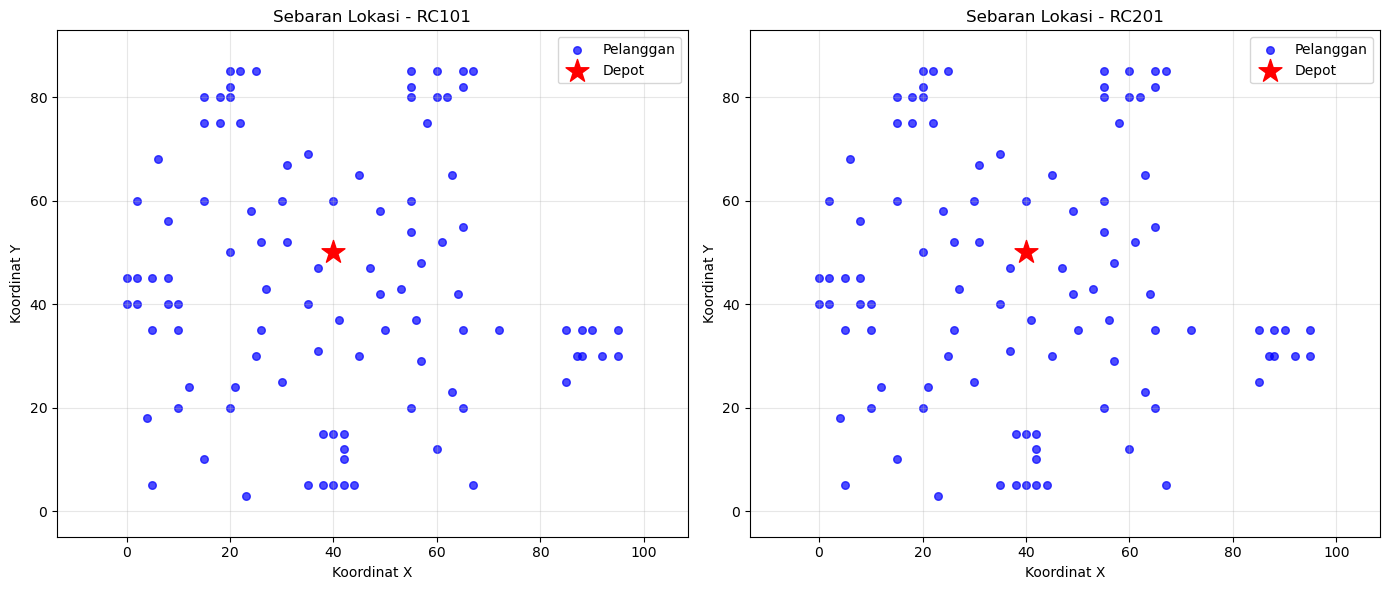

In [12]:
# ================================================================
# 3.2. Scatter Plot Lokasi Depot & Pelanggan (OVERLAY)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (inst_name, spec) in enumerate(EDA_INSTANCE_SPECS.items()):
    p: ProblemData = spec["problem"]
    coords = p.coords
    depot_idx = p.depot_index
    cust_idx = p.customer_indices

    ax = axes[idx]
    ax.scatter(
        coords[cust_idx, 0],
        coords[cust_idx, 1],
        s=30,
        alpha=0.7,
        label="Pelanggan",
        color="blue"
    )
    ax.scatter(
        coords[depot_idx, 0],
        coords[depot_idx, 1],
        marker="*",
        s=300,
        color="red",
        label="Depot",
        zorder=5
    )
    ax.set_title(f"Sebaran Lokasi - {inst_name}")
    ax.set_xlabel("Koordinat X")
    ax.set_ylabel("Koordinat Y")
    ax.axis("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


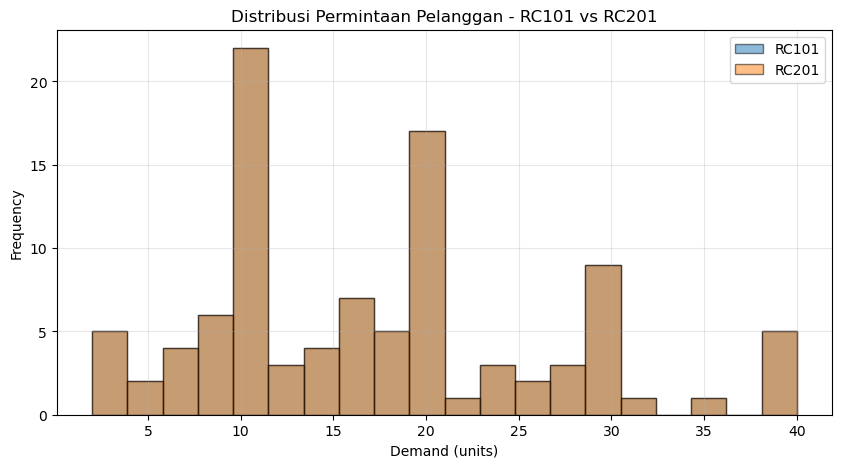

In [13]:
# ================================================================
# Distribusi Permintaan Pelanggan (OVERLAY)
# ================================================================

plt.figure(figsize=(10, 5))
for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    demand_cust = p.demand_units[p.customer_indices]

    plt.hist(demand_cust, bins=20, edgecolor="black", alpha=0.5, label=inst_name)

plt.title("Distribusi Permintaan Pelanggan - RC101 vs RC201")
plt.xlabel("Demand (units)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

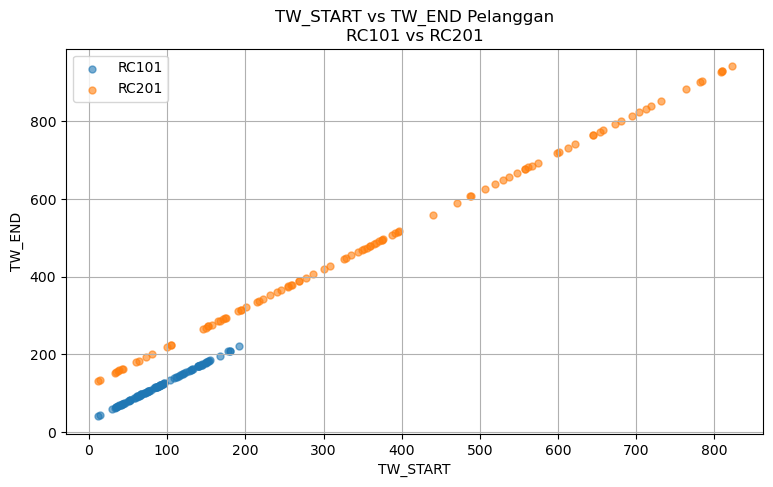

In [14]:
# ============================================
# Scatter TW_START vs TW_END (Pelanggan) - RC101 vs RC201
# ============================================

plt.figure()

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    cust_idx = p.customer_indices

    tw_start_cust = p.tw_start[cust_idx]
    tw_end_cust   = p.tw_end[cust_idx]

    plt.scatter(
        tw_start_cust,
        tw_end_cust,
        s=25,
        alpha=0.6,
        label=inst_name
    )

plt.title("TW_START vs TW_END Pelanggan\nRC101 vs RC201")
plt.xlabel("TW_START")
plt.ylabel("TW_END")
plt.grid(True)
plt.legend()
plt.show()


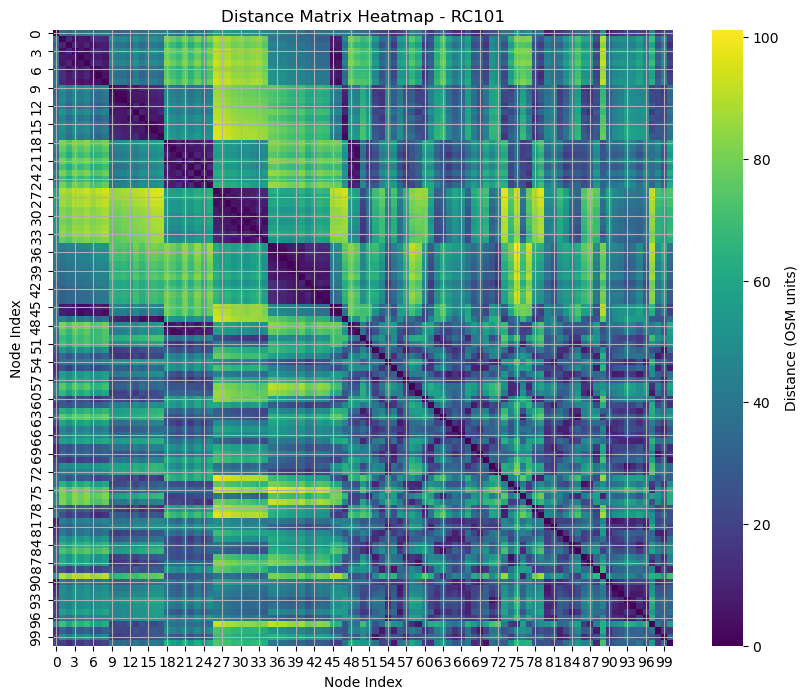

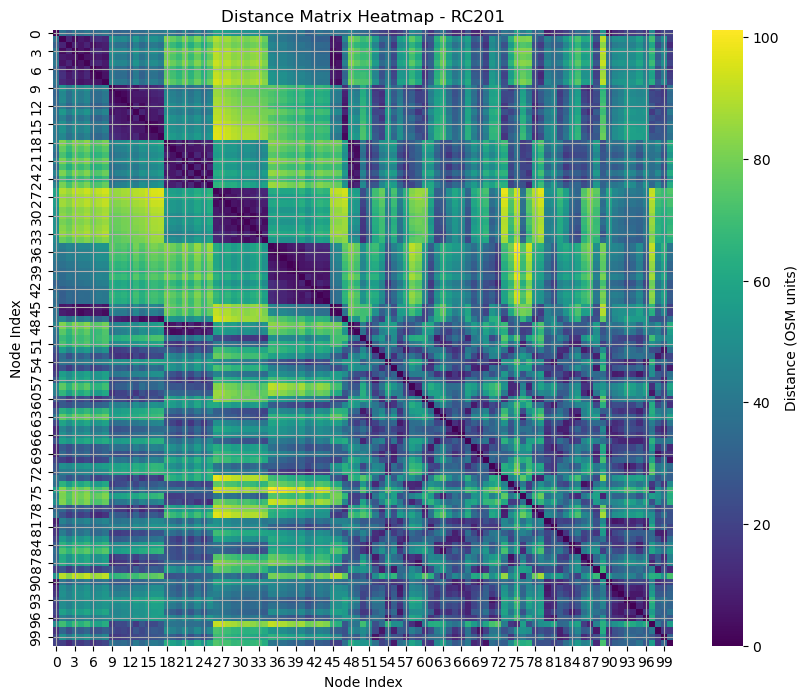

In [15]:
# ================================================================
# Heatmap Matriks Jarak (Struktur Spasial)
# ================================================================

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]

    plt.figure(figsize=(10, 8))
    sns.heatmap(p.dist_matrix, cmap="viridis", cbar_kws={"label": "Distance (OSM units)"})
    plt.title(f"Distance Matrix Heatmap - {inst_name}")
    plt.xlabel("Node Index")
    plt.ylabel("Node Index")
    plt.show()


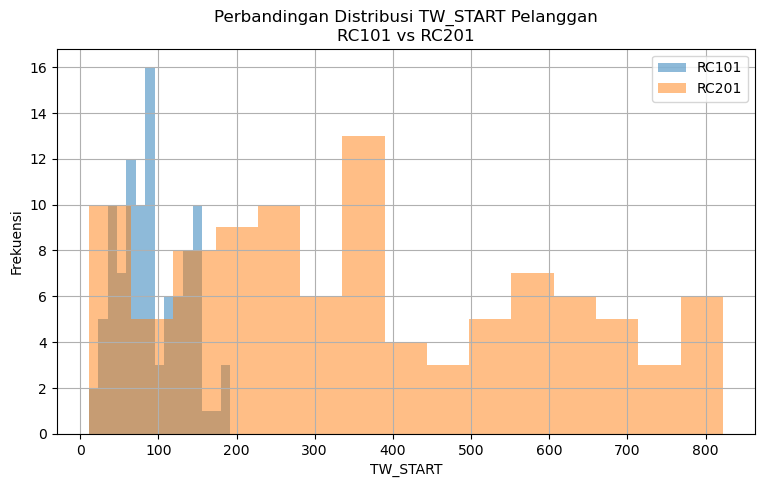

In [16]:
# ============================================
# Perbandingan Distribusi TW_START (RC101 vs RC201)
# ============================================

plt.figure()

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p = spec["problem"]
    cust_idx = p.customer_indices
    tw_start = p.tw_start[cust_idx]

    plt.hist(
        tw_start,
        bins=15,
        alpha=0.5,
        label=inst_name
    )

plt.title("Perbandingan Distribusi TW_START Pelanggan\nRC101 vs RC201")
plt.xlabel("TW_START")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()


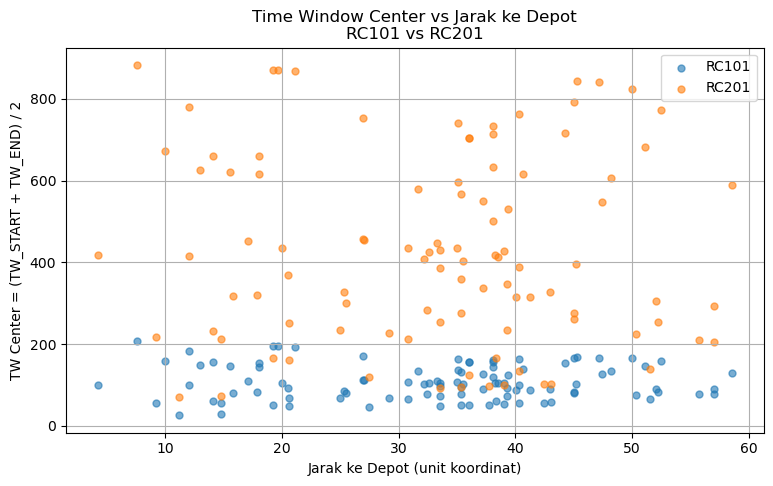

In [17]:
# ============================================
# Time Window Center vs Jarak ke Depot (RC101 vs RC201)
# ============================================

plt.figure()

for inst_name, spec in EDA_INSTANCE_SPECS.items():
    p: ProblemData = spec["problem"]
    depot_idx = p.depot_index
    cust_idx = p.customer_indices

    tw_start_cust = p.tw_start[cust_idx]
    tw_end_cust   = p.tw_end[cust_idx]
    tw_center     = 0.5 * (tw_start_cust + tw_end_cust)

    dist_from_depot = p.dist_matrix[depot_idx, cust_idx]

    # Satu scatter per instance, dengan label untuk legenda
    plt.scatter(
        dist_from_depot,
        tw_center,
        s=25,
        alpha=0.6,
        label=inst_name
    )

plt.title("Time Window Center vs Jarak ke Depot\nRC101 vs RC201")
plt.xlabel("Jarak ke Depot (unit koordinat)")
plt.ylabel("TW Center = (TW_START + TW_END) / 2")
plt.grid(True)
plt.legend()
plt.show()


--- Diagnosa Data RC101 ---


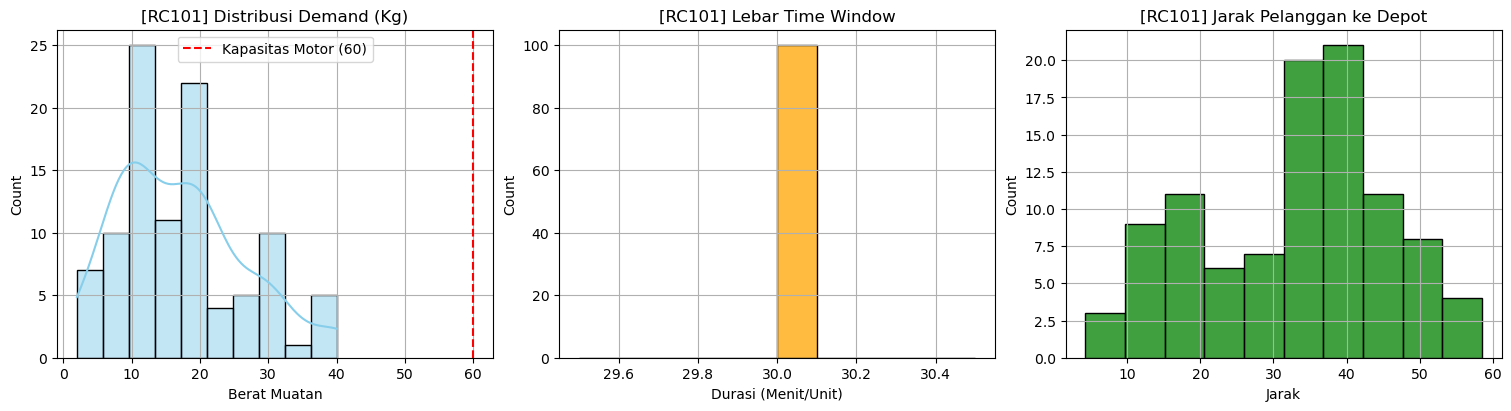


--- Diagnosa Data RC201 ---


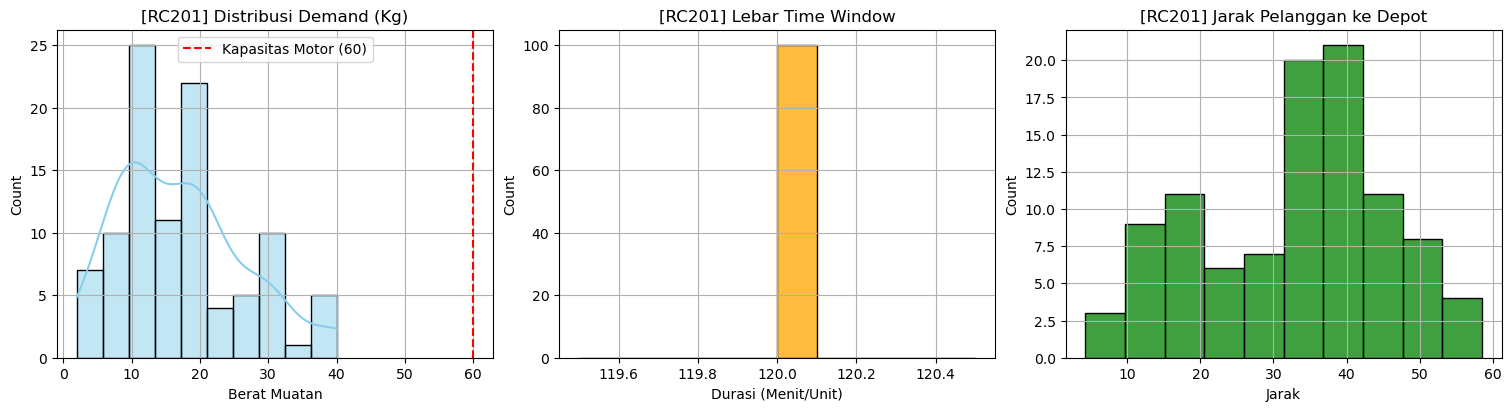


--- Peta Interaktif RC101 (Surakarta) ---


In [18]:
# ==============================================================================
# CELL 8 (FIXED): EXPLORATORY DATA ANALYSIS (EDA) & VISUALISASI PETA
# ==============================================================================

import folium
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec  # <--- INI YANG TADI KURANG

# -----------------------------------------------------------
# 1. FUNGSI VISUALISASI PETA REAL (FOLIUM)
# -----------------------------------------------------------
def visualize_instance_on_real_map(instance_name, core_npz_path):
    """
    Membuat peta interaktif Folium dari data Lat/Lon di file NPZ.
    (Tanpa lingkaran merah di sekitar depot)
    """
    # Load Lat/Lon dari NPZ
    if not core_npz_path.exists():
        print(f"❌ File NPZ tidak ditemukan: {core_npz_path}")
        return None

    with np.load(core_npz_path) as data:
        latlon = data['latlon']       # [N, 2] (Lat, Lon)
        demand = data['demandunits']  # [N,]
        is_depot = data['isdepot']    # [N,]

    # Ambil koordinat depot untuk sentral peta
    depot_idx = np.where(is_depot)[0][0]
    depot_loc = latlon[depot_idx]

    # Buat Peta Dasar
    m = folium.Map(location=depot_loc, zoom_start=13, tiles='CartoDB positron')

    # Judul
    title_html = f'<h3 align="center" style="font-size:16px"><b>{instance_name} in Surakarta</b></h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    # Plot Pelanggan & Depot
    for i in range(len(latlon)):
        loc = latlon[i]
        d = demand[i]

        if is_depot[i]:
            # --- MODIFIKASI: HANYA MARKER, LINGKARAN DIHAPUS ---
            # Marker Depot (Bintang Merah)
            folium.Marker(
                location=loc,
                popup=folium.Popup(f"<b>DEPOT</b>", max_width=200),
                icon=folium.Icon(color='red', icon='star')
            ).add_to(m)
            
            # (Bagian folium.Circle sudah dihapus di sini)

        else:
            # Marker Pelanggan (Lingkaran Biru)
            # Radius dinamis berdasarkan demand
            radius = 3 + (d / 5.0)

            folium.CircleMarker(
                location=loc,
                radius=radius,
                tooltip=f"Cust {i} ({d} kg)", # Tooltip biar muncul saat hover
                popup=f"Cust {i}<br>Demand: {d} kg",
                color='blue',
                fill=True,
                fill_color='#3186cc',
                fill_opacity=0.7
            ).add_to(m)

    return m

# -----------------------------------------------------------
# 2. FUNGSI ANALISIS DATA (MATPLOTLIB/SEABORN)
# -----------------------------------------------------------
def plot_instance_diagnostics(problem_data):
    """
    Menampilkan 3 grafik diagnostik: Demand, Time Window, dan Jarak.
    """
    name = problem_data.instance_name
    demands = problem_data.demand_units[problem_data.customer_indices]
    matrix = problem_data.dist_matrix
    depot = problem_data.depot_index

    # Hitung jarak tiap customer ke depot
    dist_to_depot = matrix[depot, problem_data.customer_indices]

    fig = plt.figure(figsize=(15, 4), constrained_layout=True)
    
    # GridSpec sekarang sudah dikenali
    gs = GridSpec(1, 3, figure=fig)

    # A. Distribusi Demand
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(demands, bins=10, kde=True, color='skyblue', ax=ax1)
    ax1.set_title(f"[{name}] Distribusi Demand (Kg)")
    ax1.set_xlabel("Berat Muatan")
    ax1.axvline(60, color='red', linestyle='--', label='Kapasitas Motor (60)')
    ax1.legend()

    # B. Time Window Width
    ax2 = fig.add_subplot(gs[0, 1])
    tw_width = problem_data.tw_end - problem_data.tw_start
    tw_cust = tw_width[problem_data.customer_indices]
    sns.histplot(tw_cust, bins=10, color='orange', ax=ax2)
    ax2.set_title(f"[{name}] Lebar Time Window")
    ax2.set_xlabel("Durasi (Menit/Unit)")

    # C. Jarak dari Depot
    ax3 = fig.add_subplot(gs[0, 2])
    sns.histplot(dist_to_depot, bins=10, color='green', ax=ax3)
    ax3.set_title(f"[{name}] Jarak Pelanggan ke Depot")
    ax3.set_xlabel("Jarak")

    plt.show()

# ===========================================================
# EKSEKUSI VISUALISASI
# ===========================================================

# Pastikan variable problems sudah terisi (dari Cell Load Data)
if 'problems' in globals():
    # 1. Tampilkan Grafik Diagnostik
    print("--- Diagnosa Data RC101 ---")
    plot_instance_diagnostics(problems["RC101"])

    print("\n--- Diagnosa Data RC201 ---")
    plot_instance_diagnostics(problems["RC201"])

    # 2. Tampilkan Peta Interaktif
    print("\n--- Peta Interaktif RC101 (Surakarta) ---")
    map_rc101 = visualize_instance_on_real_map("Data RC pada overlay peta Surakarta", CORERC101NPZ)
    
    # Tampilkan peta di output cell
    display(map_rc101)
else:
    print("⚠️ Warning: Variabel 'problems' belum ada. Harap jalankan Cell Load Data dulu.")

### Cell 9: Model Evaluasi Rute & Solusi (CORE LOGIC)

In [19]:
# ==============================================================================
# CELL 9: MODEL EVALUASI RUTE & SOLUSI (CORE LOGIC)
# ==============================================================================

from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

# ================================================================
# Struktur Hasil Evaluasi Rute & Solusi
# ================================================================

@dataclass
class RouteCostBreakdown:
    """
    Ringkasan biaya & emisi untuk satu rute (satu kendaraan).
    """
    vehicle_type_name: str
    vehicle_type_index: int

    # ukuran dasar rute
    n_customers: int
    total_demand: float

    # waktu & jarak
    departure_time: float   # waktu berangkat dari depot (absolute time)
    return_time: float      # waktu kembali ke depot (absolute time)
    distance: float
    moving_time: float
    idle_time: float
    route_duration: float

    # pelanggaran kendala
    capacity_violation: float
    tw_violation: float
    duration_violation: float

    # komponen emisi
    moving_emission: float
    idle_emission: float

    # metrik temporal tambahan untuk waiting-aware scoring
    pure_waiting: float = 0.0
    tw_span: float = 0.0
    wait_span_gap: float = 0.0

    # biaya Green-lite (terpenalti)
    green_cost: float = 0.0
    penalized_cost: float = 0.0

    # metrik tambahan
    n_late_customers: int = 0


@dataclass
class SolutionCostBreakdown:
    """
    Ringkasan biaya & emisi untuk satu solusi lengkap (kumpulan rute).
    """
    n_routes: int
    routes_per_type: Dict[str, int]

    total_distance: float
    total_moving_time: float
    total_idle_time: float
    total_route_duration: float

    total_demand: float
    total_capacity_violation: float
    total_tw_violation: float
    total_duration_violation: float

    total_moving_emission: float
    total_idle_emission: float

    green_cost: float        # Biaya lingkungan murni
    penalized_cost: float    # Biaya dengan penalti (untuk optimasi)

    # Kunci leksikografis: (Jumlah Rute, Biaya Terpenalti)
    lexicographic_key: Tuple[int, float]

    # Detil per rute
    route_costs: List[RouteCostBreakdown]

    # total metrik waiting-aware tambahan
    total_pure_waiting: float = 0.0
    total_wait_span_gap: float = 0.0

    # Metrik performa layanan
    total_customers: int = 0
    total_late_customers: int = 0
    on_time_ratio: float = 0.0


# ================================================================
# Evaluasi Satu Rute (Green-lite + Penalti)
# ================================================================


def compute_latest_departure_time(
    problem: ProblemData,
    route_customers: List[int],
    vehicle_type: VehicleTypeConfig,
) -> float:
    """
    Menghitung waktu berangkat paling lambat yang masih menjaga seluruh
    pelanggan pada rute tetap tidak terlambat (atau 0 jika tidak ada).

    Strategi ini dipakai untuk delayed departure: kendaraan berangkat dari depot
    selambat mungkin agar waiting time di rute turun tanpa mengubah urutan kunjungan.
    """
    if not route_customers:
        return 0.0

    depot = problem.depot_index
    eff_speed = max(float(vehicle_type.speed_factor), 1e-3)

    elapsed_no_wait = 0.0
    latest_departure = float("inf")
    prev = depot

    for cust in route_customers:
        elapsed_no_wait += float(problem.travel_time_matrix[prev, cust]) / eff_speed
        latest_departure = min(latest_departure, float(problem.tw_end[cust]) - elapsed_no_wait)
        elapsed_no_wait += float(problem.service_time[cust])
        prev = cust

    if latest_departure == float("inf"):
        return 0.0

    return max(0.0, latest_departure)


def evaluate_route_green_cost(
    problem: ProblemData,
    route_customers: List[int],
    vehicle_type: VehicleTypeConfig,
    objective_cfg: Optional[ObjectiveConfig] = None,
    penalty_cfg: Optional[PenaltyConfig] = None,
) -> RouteCostBreakdown:
    """
    Menghitung biaya & emisi sebuah rute untuk satu tipe kendaraan.
    Kompatibel dengan mode Solomon-Unit maupun Map-Real (tergantung isi ProblemData).
    """
    if objective_cfg is None:
        objective_cfg = problem.objective_config
    if penalty_cfg is None:
        penalty_cfg = problem.penalty_config

    if len(route_customers) == 0:
        return RouteCostBreakdown(
            vehicle_type_name=vehicle_type.name,
            vehicle_type_index=-1,
            n_customers=0, total_demand=0.0,
            departure_time=0.0, return_time=0.0,
            distance=0.0,
            moving_time=0.0, idle_time=0.0, route_duration=0.0,
            capacity_violation=0.0, tw_violation=0.0, duration_violation=0.0,
            moving_emission=0.0, idle_emission=0.0,
            pure_waiting=0.0, tw_span=0.0, wait_span_gap=0.0,
            green_cost=0.0, penalized_cost=0.0, n_late_customers=0,
        )

    depot = problem.depot_index
    n_cust = len(route_customers)

    # Rute Lengkap: Depot -> C1 -> C2 -> ... -> Depot
    seq = [depot] + list(route_customers) + [depot]

    # Delayed departure: berangkat selambat mungkin agar waiting turun
    departure_time = compute_latest_departure_time(problem, route_customers, vehicle_type)

    time = departure_time  # Waktu saat ini, dihitung dari departure yang optimal
    distance = 0.0        # Total jarak
    moving_time = 0.0     # Total waktu bergerak
    idle_time = 0.0       # Total waktu diam (waiting + service)
    tw_violation = 0.0    # Total keterlambatan

    load = 0.0
    max_load = 0.0
    n_late_customers = 0

    # Safety: hindari pembagian dengan nol
    eff_speed = max(float(vehicle_type.speed_factor), 1e-3)

    for i in range(len(seq) - 1):
        idx_from = seq[i]
        idx_to = seq[i+1]

        # Ambil data jarak & waktu dasar dari matriks ProblemData
        d_ij = float(problem.dist_matrix[idx_from, idx_to])
        t_base = float(problem.travel_time_matrix[idx_from, idx_to])

        # Waktu tempuh efektif (sesuai jenis kendaraan)
        t_ij = t_base / eff_speed

        distance += d_ij
        moving_time += t_ij
        time += t_ij

        # Jika tiba di pelanggan (bukan depot akhir)
        if not problem.is_depot[idx_to]:
            # 1. Update Muatan
            load += float(problem.demand_units[idx_to])
            max_load = max(max_load, load)

            # 2. Cek Time Window
            tw_start_j = float(problem.tw_start[idx_to])
            tw_end_j = float(problem.tw_end[idx_to])

            # Case A: Tiba Terlalu Awal (Waiting)
            if time < tw_start_j:
                wait = tw_start_j - time
                idle_time += wait
                time = tw_start_j  # Kendaraan menunggu sampai buka

            # Case B: Tiba Terlambat (Time Warp)
            elif time > tw_end_j:
                late = time - tw_end_j
                tw_violation += late
                n_late_customers += 1
                # Di VRP klasik, waktu tidak dimundurkan, penalti dicatat

            # 3. Waktu Layanan (Service)
            service_j = float(problem.service_time[idx_to])
            time += service_j

            # Opsi: Hitung service time sebagai emisi idle?
            if objective_cfg.include_service_in_idle:
                idle_time += service_j

    return_time = time
    route_duration = return_time - departure_time

    # --- Hitung Pelanggaran ---
    capacity_violation = max(0.0, max_load - vehicle_type.capacity_units)

    duration_violation = 0.0
    if vehicle_type.max_route_duration is not None:
        duration_violation = max(0.0, route_duration - vehicle_type.max_route_duration)

    # --- Hitung Emisi ---
    moving_emission = distance * vehicle_type.ef_km
    idle_emission = idle_time * vehicle_type.ef_idle

    # --- Hitung Pure Waiting (idle_time dikurangi service time) ---
    # pure_waiting = waktu menunggu murni, TIDAK termasuk service time
    total_service_time = sum(
        float(problem.service_time[c]) for c in route_customers
    ) if objective_cfg.include_service_in_idle else 0.0
    pure_waiting = max(0.0, idle_time - total_service_time)

    # --- Tambahan proksi waiting-aware untuk membantu split/local search ---
    tw_values = [float(problem.tw_start[c]) for c in route_customers]
    tw_span = (max(tw_values) - min(tw_values)) if len(tw_values) >= 2 else 0.0
    active_time = moving_time + total_service_time
    wait_span_gap = max(0.0, tw_span - active_time)

    # --- Hitung Biaya Green-Lite (Objektif Asli) ---
    w_d, w_move, w_idle = objective_cfg.as_tuple()
    green_cost = (
        w_d * distance +
        w_move * moving_emission +
        w_idle * idle_emission
    )

    # Fixed cost kendaraan adalah biaya operasional per rute,
    # sehingga masuk ke penalized cost agar decoding konsisten dengan fleet mix.
    fixed_route_cost = float(getattr(vehicle_type, "fixed_cost", 0.0))

    lambda_waiting = float(getattr(penalty_cfg, "lambda_waiting", 0.0))
    lambda_wait_span = float(getattr(penalty_cfg, "lambda_wait_span", 0.0))

    # --- Hitung Biaya Terpenalti (Objektif Optimasi) ---
    penalized_cost = (
        green_cost +
        fixed_route_cost +
        penalty_cfg.lambda_load * capacity_violation +
        penalty_cfg.lambda_tw * tw_violation +
        penalty_cfg.lambda_duration * duration_violation +
        lambda_waiting * pure_waiting +
        lambda_wait_span * wait_span_gap
    )

    return RouteCostBreakdown(
        vehicle_type_name=vehicle_type.name,
        vehicle_type_index=-1,
        n_customers=n_cust,
        total_demand=float(max_load),
        departure_time=departure_time,
        return_time=return_time,
        distance=distance,
        moving_time=moving_time,
        idle_time=idle_time,
        route_duration=route_duration,
        capacity_violation=capacity_violation,
        tw_violation=tw_violation,
        duration_violation=duration_violation,
        moving_emission=moving_emission,
        idle_emission=idle_emission,
        pure_waiting=pure_waiting,
        tw_span=tw_span,
        wait_span_gap=wait_span_gap,
        green_cost=green_cost,
        penalized_cost=penalized_cost,
        n_late_customers=n_late_customers,
    )


### CELL 10: EVALUASI SOLUSI, METRIK, DAN UNIT TESTING

In [20]:
# ==============================================================================
# CELL 10: EVALUASI SOLUSI, METRIK, DAN UNIT TESTING
# ==============================================================================

from typing import List, Tuple, Dict, Optional
from collections import defaultdict

# ================================================================
# 4.3. Evaluasi Solusi Lengkap (Missing Function)
# ================================================================

def evaluate_solution_green_cost(
    problem: ProblemData,
    routes: List[Tuple[int, List[int]]],  # List of (vehicle_type_idx, [customer_ids])
    objective_cfg: Optional[ObjectiveConfig] = None,
    penalty_cfg: Optional[PenaltyConfig] = None,
) -> SolutionCostBreakdown:
    """
    Mengevaluasi satu solusi lengkap (kumpulan rute).
    Mengagregasi biaya dari setiap rute individu.
    """
    if objective_cfg is None:
        objective_cfg = problem.objective_config
    if penalty_cfg is None:
        penalty_cfg = problem.penalty_config

    # Inisialisasi Akumulator
    total_distance = 0.0
    total_moving_time = 0.0
    total_idle_time = 0.0
    total_route_duration = 0.0

    total_demand = 0.0
    total_cap_violation = 0.0
    total_tw_violation = 0.0
    total_dur_violation = 0.0

    total_moving_emission = 0.0
    total_idle_emission = 0.0

    total_pure_waiting = 0.0
    total_wait_span_gap = 0.0

    green_cost = 0.0
    penalized_cost = 0.0

    routes_per_type = defaultdict(int)
    route_costs = []

    total_late_customers = 0
    total_customers_served = 0

    # Iterasi setiap rute dalam solusi
    for v_type_idx, route_custs in routes:
        # Ambil konfigurasi kendaraan berdasarkan index
        v_type = problem.fleet_config.vehicle_types[v_type_idx]
        routes_per_type[v_type.name] += 1

        # Evaluasi Rute Individu
        rc = evaluate_route_green_cost(
            problem, route_custs, v_type, objective_cfg, penalty_cfg
        )
        route_costs.append(rc)

        # Agregasi Metrik
        total_distance += rc.distance
        total_moving_time += rc.moving_time
        total_idle_time += rc.idle_time
        total_route_duration += rc.route_duration

        total_demand += rc.total_demand
        total_cap_violation += rc.capacity_violation
        total_tw_violation += rc.tw_violation
        total_dur_violation += rc.duration_violation

        total_moving_emission += rc.moving_emission
        total_idle_emission += rc.idle_emission
        total_pure_waiting += float(getattr(rc, "pure_waiting", 0.0))
        total_wait_span_gap += float(getattr(rc, "wait_span_gap", 0.0))

        green_cost += rc.green_cost
        penalized_cost += rc.penalized_cost

        total_late_customers += rc.n_late_customers
        total_customers_served += rc.n_customers

    # Hitung Rasio On-Time
    on_time_ratio = 1.0
    if total_customers_served > 0:
        on_time_ratio = 1.0 - (total_late_customers / total_customers_served)

    n_routes = len(routes)

    # Kunci Leksikografis untuk Sorting/Seleksi HGS:
    # 1. Minimalkan Jumlah Kendaraan (Tier-1)
    # 2. Minimalkan Biaya Terpenalti (Tier-2)
    lex_key = (n_routes, penalized_cost)

    return SolutionCostBreakdown(
        n_routes=n_routes,
        routes_per_type=dict(routes_per_type),
        total_distance=total_distance,
        total_moving_time=total_moving_time,
        total_idle_time=total_idle_time,
        total_route_duration=total_route_duration,
        total_demand=total_demand,
        total_capacity_violation=total_cap_violation,
        total_tw_violation=total_tw_violation,
        total_duration_violation=total_dur_violation,
        total_moving_emission=total_moving_emission,
        total_idle_emission=total_idle_emission,
        total_pure_waiting=total_pure_waiting,
        total_wait_span_gap=total_wait_span_gap,
        green_cost=green_cost,
        penalized_cost=penalized_cost,
        lexicographic_key=lex_key,
        route_costs=route_costs,
        total_customers=total_customers_served,
        total_late_customers=total_late_customers,
        on_time_ratio=on_time_ratio
    )

# ================================================================
# 4.4. Helper: Ekstraksi Metrik Ringkas
# ================================================================

def compute_solution_metrics(
    problem: ProblemData,
    solution_cost: SolutionCostBreakdown,
) -> Dict[str, float]:
    """
    Mengekstrak metrik ringkas dari SolutionCostBreakdown untuk logging & analisis.
    """
    E_total = solution_cost.total_moving_emission + solution_cost.total_idle_emission

    # Utilisasi kapasitas rata-rata per rute
    avg_load = 0.0
    avg_cap = 0.0
    if solution_cost.n_routes > 0:
        total_cap = sum(
            rc.total_demand for rc in solution_cost.route_costs
        )
        avg_load = total_cap / solution_cost.n_routes

        # kapasitas rata-rata kendaraan yang digunakan
        cap_sum = 0.0
        for rc in solution_cost.route_costs:
            vtype_name = rc.vehicle_type_name
            for vt in problem.fleet_config.vehicle_types:
                if vt.name == vtype_name:
                    cap_sum += vt.capacity_units
                    break
        avg_cap = cap_sum / solution_cost.n_routes if solution_cost.n_routes > 0 else 0.0

    avg_utilization = (avg_load / avg_cap) if avg_cap > 0 else 0.0

    return {
        "E_total": E_total,
        "avg_distance_per_route": (
            solution_cost.total_distance / solution_cost.n_routes
            if solution_cost.n_routes > 0 else 0.0
        ),
        "avg_load": avg_load,
        "avg_utilization": avg_utilization,
        "total_customers": float(solution_cost.total_customers),
        "total_late_customers": float(solution_cost.total_late_customers),
        "on_time_ratio": solution_cost.on_time_ratio,
    }


# ================================================================
# 4.5. Tes Cepat: Evaluasi Rute & Solusi Contoh
# ================================================================

print("="*70)
print("Tes Model Emisi & Fungsi Biaya Green-Lite")
print("="*70)

# Pilih instance untuk tes (RC101)
# Pastikan 'problems' dictionary sudah ada dari Cell 7
if 'problems' in globals():
    test_problem = problems["RC101"]
    depot_idx = test_problem.depot_index

    # Buat rute contoh: depot -> [1, 2, 3] -> depot
    route_customers = [1, 2, 3]
    vtype = test_problem.fleet_config.vehicle_types[0]  # tipe pertama (motorcycle)

    route_cost = evaluate_route_green_cost(
        test_problem, route_customers, vtype
    )

    print(f"\nRute contoh: depot -> {route_customers} -> depot")
    print(f"Tipe kendaraan: {vtype.name}")
    print(f"  - Distance: {route_cost.distance:.2f}")
    print(f"  - Moving time: {route_cost.moving_time:.2f}")
    print(f"  - Idle time: {route_cost.idle_time:.2f}")
    print(f"  - Route duration: {route_cost.route_duration:.2f}")
    print(f"  - Moving emission: {route_cost.moving_emission:.2f}")
    print(f"  - Idle emission: {route_cost.idle_emission:.2f}")
    print(f"  - Green cost: {route_cost.green_cost:.2f}")
    print(f"  - Penalized cost: {route_cost.penalized_cost:.2f}")
    print(f"  - TW violation: {route_cost.tw_violation:.2f}")
    print(f"  - Capacity violation: {route_cost.capacity_violation:.2f}")

    # Buat solusi contoh dengan 2 rute
    # (indeks kendaraan 0=motor, 1=van - asumsikan urutan di JSON benar)
    routes_repr = [
        (0, [1, 2, 3]),    # motorcycle
        (1, [4, 5, 6, 7])  # van
    ]

    solution_cost = evaluate_solution_green_cost(test_problem, routes_repr)

    print(f"\nSolusi contoh: {len(routes_repr)} rute")
    print(f"  - Routes per type: {solution_cost.routes_per_type}")
    print(f"  - Total distance: {solution_cost.total_distance:.2f}")
    print(f"  - Total moving emission: {solution_cost.total_moving_emission:.2f}")
    print(f"  - Total idle emission: {solution_cost.total_idle_emission:.2f}")
    print(f"  - Green cost: {solution_cost.green_cost:.2f}")
    print(f"  - Penalized cost: {solution_cost.penalized_cost:.2f}")
    print(f"  - Lexicographic key: {solution_cost.lexicographic_key}")
    print(f"  - On-time ratio: {solution_cost.on_time_ratio:.2%}")
else:
    print("⚠️ Variable 'problems' tidak ditemukan. Jalankan Cell 7 terlebih dahulu.")

print("\n" + "="*70)
print("✓ Bagian 4 (Model Emisi & Fungsi Biaya Green-Lite) selesai!")
print("="*70)

Tes Model Emisi & Fungsi Biaya Green-Lite

Rute contoh: depot -> [1, 2, 3] -> depot
Tipe kendaraan: motorcycle
  - Distance: 97.88
  - Moving time: 88.98
  - Idle time: 114.49
  - Route duration: 203.47
  - Moving emission: 9.79
  - Idle emission: 1.14
  - Green cost: 174.70
  - Penalized cost: 65537.27
  - TW violation: 129.07
  - Capacity violation: 0.00

Solusi contoh: 2 rute
  - Routes per type: {'motorcycle': 1, 'van': 1}
  - Total distance: 187.49
  - Total moving emission: 36.67
  - Total idle emission: 4.27
  - Green cost: 474.32
  - Penalized cost: 174914.93
  - Lexicographic key: (2, 174914.93244032568)
  - On-time ratio: 28.57%

✓ Bagian 4 (Model Emisi & Fungsi Biaya Green-Lite) selesai!


### CELL 11: SPLIT ALGORITHM (BEST VEHICLE SELECTOR)

In [21]:
# ==============================================================================
# CELL 11: SPLIT ALGORITHM (BEST VEHICLE SELECTOR)
# ==============================================================================

# ================================================================
# 5.1. Helper: Best Vehicle Selector (Clean Version)
# ================================================================

def best_vehicle_for_segment(
    problem: ProblemData,
    segment_customers: List[int],
) -> Tuple[int, RouteCostBreakdown]:
    """
    Memilih tipe kendaraan TERBAIK untuk segmen pelanggan tertentu.

    Logika:
    Kita evaluasi segmen ini menggunakan SEMUA tipe kendaraan yang tersedia.
    Pemenangnya adalah kendaraan dengan 'penalized_cost' terendah.

    Kenapa tidak pakai diskon manual?
    Karena fungsi biaya kita sudah mencakup:
    1. Fixed Cost (jika ada di JSON) -> Menghukum penggunaan banyak kendaraan kecil
    2. Emission Cost -> Truk lebih polusi per km, tapi motor butuh banyak trip.
       Trade-off ini sudah terhitung otomatis di 'green_cost'.
    """
    fleet_types = problem.fleet_config.vehicle_types

    best_vidx = -1
    best_rc = None
    min_cost = float('inf')

    # Cek setiap tipe kendaraan
    for vidx, vtype in enumerate(fleet_types):
        # Hitung biaya rute ini jika dilayani oleh kendaraan vtype
        rc = evaluate_route_green_cost(
            problem=problem,
            route_customers=segment_customers,
            vehicle_type=vtype,
        )

        # Biaya penentu adalah penalized_cost
        # (sudah termasuk pelanggaran kapasitas/TW, emisi, dan fixed cost per rute)
        cost = rc.penalized_cost

        # Fixed cost sudah dimasukkan di penalized_cost pada evaluator.
        # Update pemenang
        if cost < min_cost:
            min_cost = cost
            best_vidx = vidx
            best_rc = rc

    if best_rc is None:
        raise RuntimeError(f"Gagal mengevaluasi segmen {segment_customers}")

    return best_vidx, best_rc

### CELL 12: OPTIMAL SPLIT ALGORITHM (BELLMAN-FORD) - MENGGANTIKAN GREEDY

In [22]:
# ==============================================================================
# CELL 12: OPTIMAL SPLIT ALGORITHM (BELLMAN-FORD) - MENGGANTIKAN GREEDY
# ==============================================================================

# ================================================================
# 5.2. Split Decoder: Optimal Bellman-Ford (Shortest Path on DAG)
# ================================================================

def split_giant_tour_optimal(
    problem: ProblemData,
    giant_tour: List[int],
) -> Tuple[List[Tuple[int, List[int]]], SolutionCostBreakdown]:
    """
    Memecah Giant Tour menjadi rute-rute kendaraan menggunakan algoritma
    Shortest Path (Bellman-Ford logic) pada graf Directed Acyclic Graph (DAG).

    Ini menjamin pembagian rute yang OPTIMAL berdasarkan urutan giant_tour yang diberikan,
    tanpa perlu aturan manual "minimal 3 pelanggan" atau "diskon manual".
    Algoritma akan menemukan sendiri apakah lebih murah pakai 1 Truk atau 3 Motor.
    """
    n_tour = len(giant_tour)
    if n_tour == 0:
        empty_routes: List[Tuple[int, List[int]]] = []
        return empty_routes, evaluate_solution_green_cost(problem, empty_routes)

    # V[i] = biaya termurah untuk melayani pelanggan giant_tour[i:] (suffix)
    # Kita bangun dari belakang ke depan (atau depan ke belakang, sama saja).
    # Di sini kita pakai forward (V[i] biaya termurah dari 0 sampai i).

    # V[i] = Cost termurah untuk melayani pelanggan pertama hingga ke-i
    V = [float('inf')] * (n_tour + 1)
    V[0] = 0.0

    # Predecessor untuk rekonstruksi rute: P[i] = (index_start_node, vehicle_idx)
    P = {}

    # --- KONFIGURASI BATCHING UNTUK EFISIENSI ---
    # Kita tidak perlu mengecek rute sepanjang 100 pelanggan jika kapasitas motor cuma 5.
    # Batasi panjang segmen maksimum untuk mempercepat.
    MAX_SEGMENT_LEN = 25  # Cukup besar untuk Truk

    for i in range(n_tour):
        # Jika V[i] inf, berarti node ini tidak terjangkau (should not happen)
        if V[i] == float('inf'):
            continue

        # Coba buat rute baru mulai dari pelanggan ke-(i+1) sampai ke-j
        # Pelanggan giant_tour[i] adalah pelanggan pertama di rute baru ini

        current_load = 0.0
        current_dist = 0.0

        # Iterasi j dari i+1 sampai batas maksimum
        for j in range(i + 1, min(i + MAX_SEGMENT_LEN, n_tour) + 1):
            segment = giant_tour[i:j] # Pelanggan indeks i s.d j-1

            # Cari kendaraan terbaik untuk segmen ini
            vidx, best_rc = best_vehicle_for_segment(problem, segment)

            cost_segment = best_rc.penalized_cost

            # Relaksasi Bellman-Ford
            if V[i] + cost_segment < V[j]:
                V[j] = V[i] + cost_segment
                P[j] = (i, vidx) # Rute berakhir di j, mulai dari i, pakai kendaraan vidx

    # --- REKONSTRUKSI RUTE DARI P ---
    routes_repr = []
    curr = n_tour

    while curr > 0:
        start_idx, vidx = P[curr]
        segment = giant_tour[start_idx:curr]
        routes_repr.append((vidx, segment))
        curr = start_idx

    # Karena kita mundur dari n_tour ke 0, urutan rute jadi terbalik
    routes_repr.reverse()

    # Evaluasi ulang solusi akhir untuk mendapatkan breakdown lengkap
    sol_cost = evaluate_solution_green_cost(problem, routes_repr)

    return routes_repr, sol_cost

### CELL 13: SPLIT REFINEMENT (LOCAL SEARCH ON BOUNDARIES)

In [23]:
# ==============================================================================
# CELL 13: SPLIT REFINEMENT (LOCAL SEARCH ON BOUNDARIES)
# ==============================================================================

# ================================================================
# 5.3. Split Refinement Boundary
# ================================================================

def refine_split_boundaries(
    problem: ProblemData,
    routes_repr: List[Tuple[int, List[int]]],
    max_shift: int = 1,
    max_passes: int = 1,
) -> Tuple[List[Tuple[int, List[int]]], SolutionCostBreakdown]:
    """
    Melakukan perbaikan lokal di perbatasan antar rute (Boundary Local Search).
    Mencoba memindahkan pelanggan di ujung rute i ke rute i+1, atau sebaliknya.
    """

    # Copy deep enough
    best_routes = [(vidx, list(seq)) for (vidx, seq) in routes_repr]

    # Evaluasi solusi awal
    best_cost = evaluate_solution_green_cost(problem, best_routes)
    best_lex = best_cost.lexicographic_key

    if len(best_routes) <= 1 or max_shift <= 0 or max_passes <= 0:
        return best_routes, best_cost

    improved = True
    passes_done = 0

    while improved and passes_done < max_passes:
        improved = False
        passes_done += 1

        # Iterasi setiap boundary antar rute
        # Karena jumlah rute bisa berubah (kalau ada rute kosong dihapus),
        boundary_idx = 0

        while boundary_idx < len(best_routes) - 1:
            # Rute Kiri (i) dan Kanan (i+1)
            (left_v_orig, left_seq_orig) = best_routes[boundary_idx]
            (right_v_orig, right_seq_orig) = best_routes[boundary_idx + 1]

            left_seq = list(left_seq_orig)
            right_seq = list(right_seq_orig)

            # Skip jika salah satu kosong (safety)
            if len(left_seq) == 0 or len(right_seq) == 0:
                boundary_idx += 1
                continue

            candidate_found = False

            # --- SKENARIO A: Geser dari KIRI ke KANAN (Shift Right) ---
            # Coba pindahkan 1..max_shift pelanggan
            for s in range(1, min(max_shift + 1, len(left_seq) + 1)):
                moved = left_seq[-s:]      # Ambil ekor kiri
                new_left = left_seq[:-s]   # Sisa kiri
                new_right = moved + right_seq # Tempel ke kepala kanan

                # Rekonstruksi Solusi Kandidat
                cand_routes = []
                for idx, (v_orig, seq_orig) in enumerate(best_routes):
                    if idx == boundary_idx:
                        if len(new_left) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_left)
                            cand_routes.append((v_new, new_left))
                    elif idx == boundary_idx + 1:
                        if len(new_right) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_right)
                            cand_routes.append((v_new, new_right))
                    else:
                        cand_routes.append((v_orig, list(seq_orig)))

                # Evaluasi
                cand_cost = evaluate_solution_green_cost(problem, cand_routes)
                cand_lex = cand_cost.lexicographic_key

                # Jika membaik secara leksikografis
                if cand_lex < best_lex:
                    best_routes = cand_routes
                    best_cost = cand_cost
                    best_lex = cand_lex
                    candidate_found = True
                    improved = True
                    break # Ambil perbaikan pertama (First Improvement)

            if candidate_found:
                # Boundary mungkin bergeser/hilang, restart loop boundary atau adjust index
                # Simplifikasi: karena struktur list berubah, kita bisa restart loop boundary
                # atau cukup skip ke boundary berikutnya (tapi hati-hati index).
                # Di sini kita 'continue' tapi boundary_idx tidak ditambah -> cek boundary baru di posisi sama
                # (karena best_routes sudah berubah di posisi boundary_idx)
                continue

            # --- SKENARIO B: Geser dari KANAN ke KIRI (Shift Left) ---
            for s in range(1, min(max_shift + 1, len(right_seq) + 1)):
                moved = right_seq[:s]      # Ambil kepala kanan
                new_left = left_seq + moved # Tempel ke ekor kiri
                new_right = right_seq[s:]  # Sisa kanan

                cand_routes = []
                for idx, (v_orig, seq_orig) in enumerate(best_routes):
                    if idx == boundary_idx:
                        if len(new_left) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_left)
                            cand_routes.append((v_new, new_left))
                    elif idx == boundary_idx + 1:
                        if len(new_right) > 0:
                            v_new, _ = best_vehicle_for_segment(problem, new_right)
                            cand_routes.append((v_new, new_right))
                    else:
                        cand_routes.append((v_orig, list(seq_orig)))

                cand_cost = evaluate_solution_green_cost(problem, cand_routes)
                cand_lex = cand_cost.lexicographic_key

                if cand_lex < best_lex:
                    best_routes = cand_routes
                    best_cost = cand_cost
                    best_lex = cand_lex
                    candidate_found = True
                    improved = True
                    break

            if candidate_found:
                continue # Cek boundary ini lagi (karena isinya sudah berubah)

            # Jika tidak ada perbaikan di boundary ini, lanjut ke boundary sebelah
            boundary_idx += 1

    return best_routes, best_cost

### CELL 14: UNIT TEST SPLIT ALGORITHM (OPTIMAL BELLMAN-FORD)

In [24]:
# ==============================================================================
# CELL 14: UNIT TEST SPLIT ALGORITHM (OPTIMAL BELLMAN-FORD)
# ==============================================================================

# ================================================================
# 5.4. Tes Cepat: Split Decoder pada Giant Tour Contoh
# ================================================================

print("="*70)
print("Tes Split Decoder OPTIMAL (Bellman-Ford Logic)")
print("="*70)

# Giant tour contoh: urutan pelanggan 1-10
# (Asumsi pelanggan berdekatan secara geografis di dataset Solomon)
giant_tour_example = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# --- 1. Decode untuk RC101 ---
print("\nInstance: RC101 (Karakteristik: Kapasitas Ketat, TW Sempit)")
print(f"Giant tour: {giant_tour_example}")

# PANGGIL FUNGSI BARU (OPTIMAL)
routes_rc101, sol_rc101 = split_giant_tour_optimal(
    problemrc101,
    giant_tour_example,
)

print(f"\nHasil split: {len(routes_rc101)} rute")
for i, (vtype_idx, route_customers) in enumerate(routes_rc101):
    vtype_name = problemrc101.fleet_config.vehicle_types[vtype_idx].name
    print(f"  Rute {i+1}: {vtype_name} -> {route_customers}")

print(f"\nLexicographic key: {sol_rc101.lexicographic_key}")
print(f"  - K (jumlah rute): {sol_rc101.n_routes}")
print(f"  - Cost (penalized): {sol_rc101.penalized_cost:.2f}")
print(f"  - Green cost: {sol_rc101.green_cost:.2f}")
print(f"  - Total distance: {sol_rc101.total_distance:.2f}")
print(f"  - On-time ratio: {sol_rc101.on_time_ratio:.2%}")

# --- 2. Decode untuk RC201 ---
print("\n" + "-"*70)
print("Instance: RC201 (Karakteristik: Horizon Panjang, Rute Bisa Besar)")
print(f"Giant tour: {giant_tour_example}")

# PANGGIL FUNGSI BARU (OPTIMAL)
routes_rc201, sol_rc201 = split_giant_tour_optimal(
    problemrc201,
    giant_tour_example,
)

print(f"\nHasil split: {len(routes_rc201)} rute")
for i, (vtype_idx, route_customers) in enumerate(routes_rc201):
    vtype_name = problemrc201.fleet_config.vehicle_types[vtype_idx].name
    print(f"  Rute {i+1}: {vtype_name} -> {route_customers}")

print(f"\nLexicographic key: {sol_rc201.lexicographic_key}")
print(f"  - K (jumlah rute): {sol_rc201.n_routes}")
print(f"  - Cost (penalized): {sol_rc201.penalized_cost:.2f}")
print(f"  - Green cost: {sol_rc201.green_cost:.2f}")
print(f"  - Total distance: {sol_rc201.total_distance:.2f}")
print(f"  - On-time ratio: {sol_rc201.on_time_ratio:.2%}")

print("\n" + "="*70)
print("✓ Bagian 5 (Split Decoder OPTIMAL) selesai!")
print("="*70)

Tes Split Decoder OPTIMAL (Bellman-Ford Logic)

Instance: RC101 (Karakteristik: Kapasitas Ketat, TW Sempit)
Giant tour: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Hasil split: 6 rute
  Rute 1: motorcycle -> [1]
  Rute 2: motorcycle -> [2]
  Rute 3: motorcycle -> [3, 4]
  Rute 4: motorcycle -> [5, 6]
  Rute 5: motorcycle -> [7, 8]
  Rute 6: motorcycle -> [9, 10]

Lexicographic key: (6, 1532.5355266105255)
  - K (jumlah rute): 6
  - Cost (penalized): 1532.54
  - Green cost: 594.70
  - Total distance: 451.95
  - On-time ratio: 100.00%

----------------------------------------------------------------------
Instance: RC201 (Karakteristik: Horizon Panjang, Rute Bisa Besar)
Giant tour: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Hasil split: 6 rute
  Rute 1: motorcycle -> [1]
  Rute 2: motorcycle -> [2]
  Rute 3: motorcycle -> [3]
  Rute 4: motorcycle -> [4]
  Rute 5: motorcycle -> [5]
  Rute 6: van -> [6, 7, 8, 9, 10]

Lexicographic key: (6, 1804.6218386506707)
  - K (jumlah rute): 6
  - Cost (penalized): 1804.6

## Fase 3: Algoritma Opstimisasi

### CELL 15: REPRESENTASI INDIVIDUAL (CHROMOSOME)

In [25]:
# ==============================================================================
# CELL 15: REPRESENTASI INDIVIDUAL (CHROMOSOME)
# ==============================================================================

# ================================================================
# 6. Representasi Individual & Fitness Lexicographic
# ================================================================

@dataclass
class Individual:
    """
    Representasi individu dalam HGS:
    - Genotype: giant_tour (permutasi pelanggan)
    - Phenotype: routes_repr (hasil decode menjadi rute nyata)
    """
    problem: ProblemData
    giant_tour: List[int]
    routes_repr: Optional[List[Tuple[int, List[int]]]] = None
    solution_cost: Optional[SolutionCostBreakdown] = None

    # Metadata untuk HGS (Diversity & Management)
    age: int = 0          # Umur (generasi)
    n_descendants: int = 0  # Jumlah anak yang dihasilkan

    def __post_init__(self):
        """Auto-evaluate jika belum ada routes_repr."""
        if self.routes_repr is None or self.solution_cost is None:
            self.evaluate()

    def evaluate(self):
        """
        Decode giant_tour menjadi rute dan evaluasi solusi.

        PERBAIKAN PENTING:
        Menggunakan split_giant_tour_optimal (Bellman-Ford)
        bukan greedy_split_giant_tour.
        """
        # Decode giant tour -> routes (Menggunakan Logika Optimal Cell 12)
        self.routes_repr, self.solution_cost = split_giant_tour_optimal(
            self.problem,
            self.giant_tour,
        )

    def ensure_evaluated(self):
        """Pastikan individu sudah dievaluasi."""
        if self.routes_repr is None or self.solution_cost is None:
            self.evaluate()

    @property
    def lexkey(self) -> Tuple:
        """
        Kunci lexicographic untuk perbandingan:
        1. Jumlah Rute (K) -> Minimalkan
        2. Biaya Terpenalti -> Minimalkan
        """
        self.ensure_evaluated()
        return self.solution_cost.lexicographic_key

    @property
    def n_routes(self) -> int:
        """Jumlah rute (K)."""
        self.ensure_evaluated()
        return self.solution_cost.n_routes

    @property
    def penalized_cost(self) -> float:
        """Biaya terpenalti F'_green (fitness value)."""
        self.ensure_evaluated()
        return self.solution_cost.penalized_cost

    @property
    def green_cost(self) -> float:
        """Biaya lingkungan murni F_green (untuk laporan)."""
        self.ensure_evaluated()
        return self.solution_cost.green_cost

    @property
    def is_feasible(self) -> bool:
        sc = self.solution_cost
        return (
            sc.total_capacity_violation < 1e-4 and
            sc.total_tw_violation       < 1e-4 and
            sc.total_duration_violation < 1e-4
        )

    def clone(self) -> 'Individual':
        """Buat salinan individu (deep copy giant_tour)."""
        return Individual(
            problem=self.problem,
            giant_tour=list(self.giant_tour),
            routes_repr=None, # akan di-evaluate ulang otomatis (clean slate)
            solution_cost=None,
            age=self.age,             # Copy umur
            n_descendants=0,          # Reset descendants (karena ini individu baru)
        )

    def __lt__(self, other: 'Individual') -> bool:
        """
        Operator Less Than (<) untuk sorting.
        Individu A lebih baik dari B jika lexkey A < lexkey B.
        """
        return self.lexkey < other.lexkey


print("="*70)
print("✓ Dataclass Individual (Fixed: Bellman-Ford Split) siap.")
print("="*70)

✓ Dataclass Individual (Fixed: Bellman-Ford Split) siap.


### CELL 16: HELPER INDIVIDUAL FACTORY & UNIT TEST

In [26]:
# ==============================================================================
# CELL 16: HELPER INDIVIDUAL FACTORY & UNIT TEST
# ==============================================================================

import random

# ================================================================
# 6.1. Helper: Buat Individual dari Giant Tour
# ================================================================

def make_individual_from_customers(
    problem: ProblemData,
    customers_perm: List[int],
    evaluate_now: bool = True,
) -> Individual:
    """
    Membuat objek Individual dari permutasi pelanggan (giant tour).
    """
    ind = Individual(
        problem=problem,
        giant_tour=list(customers_perm),
        routes_repr=None,
        solution_cost=None,
    )

    if evaluate_now:
        ind.evaluate()

    return ind


# ================================================================
# 6.2. Tes Cepat: Buat Individual dari Giant Tour Contoh
# ================================================================

print("="*70)
print("Tes Individual (Giant Tour -> Decode -> Fitness)")
print("="*70)

# Pastikan problemrc101 sudah ada (dari Cell 7)
if 'problemrc101' in globals():
    # Giant tour contoh: 100 pelanggan acak
    # Kita gunakan random seed lokal agar hasil konsisten
    rng_test = random.Random(42)

    # Ambil index pelanggan (selain depot)
    cust_indices_rc101 = list(problemrc101.customer_indices)
    rng_test.shuffle(cust_indices_rc101)

    print(f"\nInstance: RC101")
    print(f"Giant tour: {len(cust_indices_rc101)} pelanggan (acak)")

    # Buat Individu
    ind_rc101 = make_individual_from_customers(
        problemrc101,
        cust_indices_rc101,
        evaluate_now=True,
    )

    print(f"\nHasil Decode (Bellman-Ford Split):")
    print(f"  - Jumlah rute (K)    : {ind_rc101.n_routes}")
    print(f"  - Penalized cost     : {ind_rc101.penalized_cost:,.2f}")
    print(f"  - Green cost         : {ind_rc101.green_cost:,.2f}")
    print(f"  - Feasible?          : {ind_rc101.is_feasible}")
    print(f"  - Lexicographic key  : {ind_rc101.lexkey}")

    # Cek On-time ratio (harus ada, karena kita sudah update SolutionCostBreakdown)
    if ind_rc101.solution_cost:
        print(f"  - On-time ratio      : {ind_rc101.solution_cost.on_time_ratio:.2%}")

    # Detail 5 rute pertama
    print(f"\nDetail 5 rute pertama:")
    if ind_rc101.routes_repr:
        for i in range(min(5, len(ind_rc101.routes_repr))):
            vtype_idx, route_custs = ind_rc101.routes_repr[i]
            vtype_name = problemrc101.fleet_config.vehicle_types[vtype_idx].name
            print(f"  Rute {i+1}: {vtype_name}, {len(route_custs)} pelanggan")

else:
    print("⚠️ problemrc101 belum didefinisikan. Jalankan Cell 7 terlebih dahulu.")

print("\n" + "="*70)
print("✓ Bagian 6 (Individual & Test) selesai!")
print("="*70)

Tes Individual (Giant Tour -> Decode -> Fitness)

Instance: RC101
Giant tour: 100 pelanggan (acak)

Hasil Decode (Bellman-Ford Split):
  - Jumlah rute (K)    : 68
  - Penalized cost     : 18,093.96
  - Green cost         : 7,458.61
  - Feasible?          : True
  - Lexicographic key  : (68, 18093.956802123583)
  - On-time ratio      : 98.00%

Detail 5 rute pertama:
  Rute 1: motorcycle, 1 pelanggan
  Rute 2: motorcycle, 1 pelanggan
  Rute 3: motorcycle, 1 pelanggan
  Rute 4: motorcycle, 2 pelanggan
  Rute 5: motorcycle, 1 pelanggan

✓ Bagian 6 (Individual & Test) selesai!


### CELL 17: UTILITY - PERBANDINGAN INDIVIDU (LEXICOGRAPHIC)

In [27]:
# ==============================================================================
# CELL 17 (REVISI): UTILITY - PERBANDINGAN INDIVIDU & TEST FIXED
# ==============================================================================

# ================================================================
# 6.5. Utility: Perbandingan Individu (Lexicographic)
# ================================================================

def is_better(a: Individual, b: Individual) -> bool:
    """
    Mengembalikan True jika individual `a` lebih baik daripada `b`.
    Menggunakan tuple comparison standar Python pada lexkey.
    """
    return a.lexkey < b.lexkey

print("="*70)
print("✓ Fungsi is_better telah di-define.")
print("="*70)

# --- UNIT TEST (DIPERBAIKI) ---
if 'ind_rc101' in globals():
    try:
        # 1. Buat Clone
        dummy_bad = ind_rc101.clone()
        dummy_bad.ensure_evaluated() # Pastikan cost terisi

        # 2. Hack Manual: Buat dia terlihat 'lebih buruk'
        #    Kita harus ubah lexicographic_key-nya langsung!
        current_k = dummy_bad.solution_cost.lexicographic_key[0]
        current_cost = dummy_bad.solution_cost.lexicographic_key[1]

        # Buat key baru: jumlah rute + 1 (Pastikan jadi lebih jelek)
        new_key = (current_k + 1, current_cost)

        # Inject key baru ke objek
        dummy_bad.solution_cost.lexicographic_key = new_key

        # 3. Lakukan Test
        # A (ind_rc101) harusnya LEBIH BAIK (True) daripada B (dummy_bad)
        test_better = is_better(ind_rc101, dummy_bad)

        # A (ind_rc101) tidak boleh lebih baik dari dirinya sendiri
        test_eq = is_better(ind_rc101, ind_rc101)

        print(f"\nTest 1 [A < A]      : {test_eq} (Target: False)")
        print(f"Test 2 [A < B_Jelek]: {test_better} (Target: True)")

        if (not test_eq) and test_better:
            print("\n✅ SUKSES: Logika Lexicographic (Feasible-First) Valid.")
        else:
            print("\n❌ GAGAL: Masih ada kesalahan logika.")

    except Exception as e:
        print(f"\n✗ Error saat test: {e}")
else:
    print("⚠️ ind_rc101 belum ada. Jalankan Cell 16 dulu.")

✓ Fungsi is_better telah di-define.

Test 1 [A < A]      : False (Target: False)
Test 2 [A < B_Jelek]: True (Target: True)

✅ SUKSES: Logika Lexicographic (Feasible-First) Valid.


### CELL 18 : OPERATOR GENETIKA LENGKAP & MANAJEMEN POOL

In [28]:
# ==============================================================================
# CELL 18 : OPERATOR GENETIKA LENGKAP & MANAJEMEN POOL
# ==============================================================================

import random
from typing import List, Tuple, Optional

# ================================================================
# 7.1. Inisialisasi Populasi (Smart Initialization)
# ================================================================

def initialize_population(problem, hgs_cfg, rng=None):
    if rng is None: rng = random
    pop_size = hgs_cfg.population_size
    cust_indices = list(problem.customer_indices)
    n_cust = len(cust_indices)
    population = []

    # ─── BARU: Bantu hitung TW center untuk sorting ───
    tw_centers = {
        c: (problem.tw_start[c] + problem.tw_end[c]) / 2.0
        for c in cust_indices
    }
    sorted_by_tw = sorted(cust_indices, key=lambda c: tw_centers[c])

    # 20% Random (explorasi)
    n_random = int(pop_size * 0.20)
    for _ in range(n_random):
        tour = list(cust_indices); rng.shuffle(tour)
        population.append(make_individual_from_customers(problem, tour, evaluate_now=True))

    # 30% Sorted by TW Center (← BARU: kunjungi berdasarkan urutan buka)
    n_tw = int(pop_size * 0.30)
    for _ in range(n_tw):
        # Tambahkan sedikit noise agar tidak identik semua
        tour = list(sorted_by_tw)
        # Perturb 10% posisi secara acak
        n_swap = max(1, int(n_cust * 0.10))
        for _ in range(n_swap):
            i, j = rng.sample(range(n_cust), 2)
            tour[i], tour[j] = tour[j], tour[i]
        population.append(make_individual_from_customers(problem, tour, evaluate_now=True))

    # 50% Segmentasi chunk (eksplorasi terstruktur, sama seperti sebelumnya)
    for _ in range(pop_size - len(population)):
        shuffled = list(cust_indices); rng.shuffle(shuffled)
        chunk_size = rng.randint(8, 12)
        chunks = [shuffled[i:i+chunk_size] for i in range(0, n_cust, chunk_size)]
        rng.shuffle(chunks)
        tour = [c for chunk in chunks for c in chunk]
        population.append(make_individual_from_customers(problem, tour, evaluate_now=True))

    return population

# ================================================================
# 7.2. Seleksi & Crossover
# ================================================================

def tournament_select(
    population: List[Individual],
    k: int,
    rng: Optional[random.Random] = None,
) -> Individual:
    """Tournament Selection standar."""
    if rng is None: rng = random
    candidates = rng.sample(population, min(k, len(population)))
    winner = candidates[0]
    for c in candidates[1:]:
        if is_better(c, winner):
            winner = c
    return winner

def ox_crossover(p1: List[int], p2: List[int], rng: Optional[random.Random] = None) -> List[int]:
    """Ordered Crossover (OX) Classic."""
    if rng is None: rng = random
    size = len(p1)
    a, b = sorted(rng.sample(range(size), 2))

    child = [-1] * size
    child[a:b+1] = p1[a:b+1]

    current_pos = (b + 1) % size
    p2_pos = (b + 1) % size

    visited = set(p1[a:b+1])
    for _ in range(size):
        cand = p2[p2_pos]
        if cand not in visited:
            child[current_pos] = cand
            visited.add(cand)
            current_pos = (current_pos + 1) % size
        p2_pos = (p2_pos + 1) % size
    return child

def route_based_crossover(
    problem: ProblemData,
    parent1: Individual,
    parent2: Individual,
    rng: Optional[random.Random] = None,
) -> List[int]:
    """
    Route-Based Crossover (SREX-lite).
    Menyalin rute utuh dari P1, sisanya diisi urutan P2.
    Sangat bagus untuk Fleet Heterogen.
    """
    if rng is None: rng = random

    # Ambil rute dari P1
    parent1.ensure_evaluated()
    routes1 = parent1.routes_repr or []
    if not routes1: return ox_crossover(parent1.giant_tour, parent2.giant_tour, rng)

    # Pilih acak beberapa rute P1
    n_copy = rng.randint(1, max(1, len(routes1)//2))
    selected_routes = rng.sample(routes1, n_copy)

    copied = set()
    child_head = []

    for _, customers in selected_routes:
        for c in customers:
            if c not in copied:
                copied.add(c)
                child_head.append(c)

    # Sisa dari P2
    child_tail = [c for c in parent2.giant_tour if c not in copied]
    return child_head + child_tail

def mutate_giant_tour_swap(tour: List[int], rate: float, rng: Optional[random.Random] = None) -> List[int]:
    """Mutasi Swap Sederhana."""
    if rng is None: rng = random
    new_tour = list(tour)
    if rng.random() < rate: # Mutasi level individu (bukan per gen) agar cepat
         i, j = rng.sample(range(len(tour)), 2)
         new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

# ================================================================
# 7.5. Make Offspring (Pabrik Anak)
# ================================================================

def make_offspring(
    problem: ProblemData,
    p1: Individual,
    p2: Individual,
    hgs_cfg: HGSConfig,
    rng: Optional[random.Random] = None,
) -> Individual:
    """Menggabungkan Crossover dan Mutasi."""
    if rng is None: rng = random

    # 1. Crossover
    if rng.random() < hgs_cfg.crossover_rate:
        # Pilih SREX atau OX?
        # Default: 50:50 jika tidak dispecify
        if rng.random() < 0.5:
            child_gt = route_based_crossover(problem, p1, p2, rng)
        else:
            child_gt = ox_crossover(p1.giant_tour, p2.giant_tour, rng)
    else:
        # Clone
        child_gt = list(p1.giant_tour)

    # 2. Mutasi
    child_gt = mutate_giant_tour_swap(child_gt, hgs_cfg.mutation_rate, rng)

    # 3. Create Individual
    child = make_individual_from_customers(problem, child_gt, evaluate_now=True)
    child.age = 0
    p1.n_descendants += 1
    p2.n_descendants += 1

    return child

# ================================================================
# 7.6. Pool Management
# ================================================================

def split_population_into_pools(pop: List[Individual]) -> Tuple[List[Individual], List[Individual]]:
    feas = [ind for ind in pop if ind.is_feasible]
    infeas = [ind for ind in pop if not ind.is_feasible]
    return feas, infeas

def trim_pool(pool: List[Individual], max_size: int) -> List[Individual]:
    """Potong pool, simpan yang terbaik (lexicographic)."""
    if len(pool) <= max_size: return pool
    pool.sort() # Sort is_better (a < b)
    return pool[:max_size]

def select_parent_from_pools(
    feasible_pop: List[Individual],
    infeasible_pop: List[Individual],
    hgs_cfg: HGSConfig,
    rng: random.Random,
    tournament_k: int = 3,
) -> Individual:
    """Pilih parent dari salah satu pool."""
    target_pool = []

    if feasible_pop and infeasible_pop:
        # Bias ke feasible parent (default 0.7)
        prob_feas = getattr(hgs_cfg, "feasible_parent_prob", 0.7)
        if rng.random() < prob_feas:
            target_pool = feasible_pop
        else:
            target_pool = infeasible_pop
    elif feasible_pop:
        target_pool = feasible_pop
    else:
        target_pool = infeasible_pop

    if not target_pool: raise RuntimeError("Fatal: Kedua pool kosong.")

    return tournament_select(target_pool, tournament_k, rng)

print("="*70)
print("✓ Operator Genetika LENGKAP (SREX + OX + Smart Init) Siap.")
print("="*70)

✓ Operator Genetika LENGKAP (SREX + OX + Smart Init) Siap.


### CELL 19: UNIT TEST GENETIKA (INTEGRITY CHECK)

In [29]:
# ==============================================================================
# CELL 19 : UNIT TEST GENETIKA
# ==============================================================================

print("="*70)
print("Tes Integritas Operator Genetika (Versi Lengkap)")
print("="*70)

if 'problemrc101' in globals():
    rng = random.Random(42)
    indices = list(problemrc101.customer_indices)

    # 1. Test Inisialisasi Cerdas
    print("Test 1: Smart Initialization...")
    try:
        # Panggil fungsi dari Cell 20
        init_pop = initialize_population(problemrc101, problemrc101.hgs_config, rng)
        if len(init_pop) == problemrc101.hgs_config.population_size:
            print(f"  ✅ SUKSES: Populasi terbentuk ({len(init_pop)} individu).")
        else:
            print(f"  ❌ GAGAL: Ukuran populasi salah.")
    except Exception as e:
        print(f"  ❌ ERROR: {e}")

    # 2. Test Crossover (OX)
    print("\nTest 2: Ordered Crossover (OX)...")
    p1 = list(indices); rng.shuffle(p1)
    p2 = list(indices); rng.shuffle(p2)

    child_ox = ox_crossover(p1, p2, rng)

    if len(child_ox) == len(p1) and set(child_ox) == set(p1):
        print("  ✅ SUKSES: OX valid (Permutasi terjaga).")
    else:
        print("  ❌ GAGAL: Struktur anak rusak.")

    # 3. Test Mutation
    print("\nTest 3: Swap Mutation...")
    child_mut = mutate_giant_tour_swap(child_ox, rate=1.0, rng=rng) # rate=1.0 pasti mutasi

    if len(child_mut) == len(child_ox) and set(child_mut) == set(child_ox):
        if child_mut != child_ox:
            print("  ✅ SUKSES: Mutasi terjadi dan struktur valid.")
        else:
            print("  ⚠️ WARNING: Mutasi tidak mengubah urutan (bisa terjadi jika swap element sama).")
    else:
        print("  ❌ GAGAL: Mutasi merusak data.")

else:
    print("⚠️ problemrc101 belum ada. Pastikan Cell 7 sudah dijalankan.")

Tes Integritas Operator Genetika (Versi Lengkap)
Test 1: Smart Initialization...
  ✅ SUKSES: Populasi terbentuk (30 individu).

Test 2: Ordered Crossover (OX)...
  ✅ SUKSES: OX valid (Permutasi terjaga).

Test 3: Swap Mutation...
  ✅ SUKSES: Mutasi terjadi dan struktur valid.


### CELL 20: LOCAL SEARCH (IDLE-AWARE EDUCATION)

In [30]:
# ==============================================================================
# CELL 21: LOCAL SEARCH (IDLE-AWARE EDUCATION)
# ==============================================================================

import random
from typing import List, Optional

# ================================================================
# 8.1. Helper: Neighborhood Moves pada Giant Tour
# ================================================================

def build_individual_from_tour(
    problem: ProblemData,
    tour: List[int],
) -> Individual:
    """Membentuk Individual dari giant tour dan langsung dievaluasi."""
    return make_individual_from_customers(
        problem=problem,
        customers_perm=tour,
        evaluate_now=True,
    )

def apply_relocate_move(tour: List[int], i: int, j: int) -> List[int]:
    """Relocate: pindahkan elemen i ke posisi j."""
    n = len(tour)
    if i == j or not (0 <= i < n) or not (0 <= j < n):
        return tour
    new_tour = list(tour)
    node = new_tour.pop(i)
    if j > i: j -= 1
    new_tour.insert(j, node)
    return new_tour

def apply_swap_move(tour: List[int], i: int, j: int) -> List[int]:
    """Swap: tukar posisi i dan j."""
    n = len(tour)
    if i == j or not (0 <= i < n) or not (0 <= j < n):
        return tour
    new_tour = list(tour)
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

def apply_twoopt_move(tour: List[int], i: int, k: int) -> List[int]:
    """2-opt: balik urutan segmen [i:k+1]."""
    n = len(tour)
    if not (0 <= i < k < n):
        return tour
    return tour[:i] + list(reversed(tour[i:k+1])) + tour[k+1:]

# ================================================================
# 8.1.NEW. TW-Reorder: Urutkan ulang sub-segmen berdasarkan TW start
# ================================================================

def tw_reorder_route_in_tour(
    tour: List[int],
    focus_positions: List[int],
    problem: ProblemData,
    rng: random.Random,
) -> List[int]:
    """
    Mengambil sub-segmen dari focus_positions dan mengurutkan ulang
    berdasarkan tw_start pelanggan.

    Tujuan: Mengurangi waiting time secara langsung dengan memastikan
    kendaraan mengunjungi pelanggan sesuai urutan waktu bukanya,
    sehingga kendaraan tidak tiba terlalu awal di pelanggan berikutnya.

    Contoh:
      Sebelum: [C5(TW=80), C2(TW=20), C8(TW=50)]
               → kendaraan tiba di C2 jauh sebelum TW=20, waiting lama
      Sesudah: [C2(TW=20), C8(TW=50), C5(TW=80)]
               → urutan lebih natural, waiting berkurang
    """
    if len(focus_positions) < 2:
        return tour

    # Ambil subgrup dari focus_positions (lebih besar sedikit agar efek reorder terasa)
    sample_size = min(8, len(focus_positions))
    selected_pos = sorted(rng.sample(focus_positions, sample_size))

    # Ambil pelanggan di posisi-posisi tersebut
    selected_custs = [tour[p] for p in selected_pos]

    # Urutkan berdasarkan opening time, lalu due time
    selected_custs_sorted = sorted(
        selected_custs,
        key=lambda c: (float(problem.tw_start[c]), float(problem.tw_end[c]))
    )

    # Susun tour baru: posisi yang sama, tapi isinya sudah TW-sorted
    new_tour = list(tour)
    for idx, pos in enumerate(selected_pos):
        new_tour[pos] = selected_custs_sorted[idx]

    return new_tour

# ================================================================
# 8.2. Idle-Aware Focus: Identifikasi Posisi dari Rute Idle Tinggi
# ================================================================

def compute_idle_focus_positions(
    ind: Individual,
    route_frac: float = 0.4,
) -> List[int]:
    """
    Mengidentifikasi pelanggan yang berada di rute dengan emisi idle tertinggi.
    Digunakan untuk memandu Local Search agar fokus memperbaiki rute 'boros'.
    """
    ind.ensure_evaluated()
    sol_cost = ind.solution_cost
    if not sol_cost or not sol_cost.route_costs:
        return list(range(len(ind.giant_tour)))

    # 1. Ranking Rute berdasarkan pure_waiting agar fokus ke bottleneck time window
    idle_scores = []
    for ridx, rc in enumerate(sol_cost.route_costs):
        score = float(getattr(rc, "pure_waiting", max(0.0, rc.idle_emission)))
        idle_scores.append((ridx, score))

    idle_scores.sort(key=lambda x: x[1], reverse=True)

    # 2. Ambil Top X% Rute dengan idle tertinggi
    k = max(1, int(route_frac * len(sol_cost.route_costs)))
    top_routes = {ridx for (ridx, _) in idle_scores[:k]}

    # 3. Mapping Pelanggan -> Rute
    customer_to_route = {}
    if ind.routes_repr:
        for ridx, (_, cust_seq) in enumerate(ind.routes_repr):
            for c in cust_seq:
                customer_to_route[c] = ridx

    # 4. Filter: ambil posisi di Giant Tour yang ada di rute boros
    focus_positions = []
    for pos, cust in enumerate(ind.giant_tour):
        ridx = customer_to_route.get(cust)
        if ridx in top_routes:
            focus_positions.append(pos)

    return focus_positions

# ================================================================
# 8.3. Local Search pada Individual (Stochastic, Idle-Aware)
# ================================================================

def local_search_individual(
    ind: Individual,
    max_steps: int = 40,
    max_span: int = 15,
    rng: Optional[random.Random] = None,
    verbose: bool = False,
) -> Individual:
    """
    Melakukan perbaikan lokal pada Giant Tour Individual.

    Fitur Utama:
    - Idle-Aware: Memprioritaskan perbaikan pada rute dengan idle tinggi.
    - Stochastic: Mengambil langkah acak (i, j, move_type) untuk kecepatan.
    - TW-Reorder: Operator baru untuk meminimasi waiting time secara langsung.
    - Lexicographic Acceptance: Hanya menerima perbaikan yang mengurangi K atau Cost.
    """
    if rng is None: rng = random

    # Copy Individual (Jangan ubah parent)
    current = ind.clone()
    current.ensure_evaluated()

    problem = current.problem
    n_cust = len(current.giant_tour)

    if n_cust <= 2 or max_steps <= 0:
        return current

    # Config Check
    hgs_cfg = problem.hgs_config
    use_idle_aware = getattr(hgs_cfg, "use_idle_aware_ls", True)
    focus_prob     = getattr(hgs_cfg, "idle_ls_focus_prob", 0.8)
    route_frac     = getattr(hgs_cfg, "idle_ls_route_frac", 0.5)

    # Hitung Fokus Awal
    if use_idle_aware:
        focus_positions = compute_idle_focus_positions(current, route_frac)
    else:
        focus_positions = []

    for step in range(max_steps):
        tour = current.giant_tour
        span = min(max_span, n_cust - 1)

        # 1. Pilih Posisi Sumber (i)
        if use_idle_aware and focus_positions and rng.random() < focus_prob:
            i = rng.choice(focus_positions)
        else:
            i = rng.randrange(n_cust)

        # 2. Pilih Tipe Move
        # tw_reorder diberi bobot lebih besar karena target utama adalah waiting
        move_type = rng.choice(["relocate", "swap", "twoopt", "tw_reorder", "tw_reorder"])
        new_tour = tour  # Default: tidak ada perubahan

        # ----------------------------------------------------------------
        # MOVE LOGIC
        # ----------------------------------------------------------------
        if move_type == "relocate":
            j_candidates = [
                x for x in range(max(0, i - span), min(n_cust, i + span + 1))
                if x != i and x != i + 1
            ]
            if j_candidates:
                j = rng.choice(j_candidates)
                new_tour = apply_relocate_move(tour, i, j)

        elif move_type == "swap":
            j_candidates = [
                x for x in range(max(0, i - span), min(n_cust, i + span + 1))
                if x != i
            ]
            if j_candidates:
                j = rng.choice(j_candidates)
                new_tour = apply_swap_move(tour, i, j)

        elif move_type == "twoopt":
            k_min = i + 1
            k_max = min(n_cust - 1, i + span)
            if k_max > k_min:
                k = rng.randrange(k_min, k_max + 1)
                new_tour = apply_twoopt_move(tour, i, k)

        else:  # tw_reorder
            # Hanya jalan jika ada focus_positions (rute idle tinggi teridentifikasi)
            # Fallback ke seluruh tour jika focus kosong
            target_positions = focus_positions if focus_positions else list(range(n_cust))
            if len(target_positions) >= 2:
                new_tour = tw_reorder_route_in_tour(tour, target_positions, problem, rng)

        # Jika tour tidak berubah, skip evaluasi
        if new_tour == tour:
            continue

        # 3. Evaluasi kandidat tour baru
        cand = build_individual_from_tour(problem, new_tour)

        # 4. Acceptance Criteria (Lexicographic First-Improvement)
        if cand.lexkey < current.lexkey:
            if verbose:
                print(f"  Step {step:3d} [{move_type:10s}]: "
                      f"{current.lexkey} → {cand.lexkey}")

            current = cand  # Terima perbaikan

            # Update fokus karena struktur rute sudah berubah
            if use_idle_aware:
                focus_positions = compute_idle_focus_positions(current, route_frac)

    return current

print("=" * 70)
print("✓ Local Search (Idle-Aware + TW-Reorder) Siap.")
print("=" * 70)

✓ Local Search (Idle-Aware + TW-Reorder) Siap.


### CELL 21: ADAPTASI PENALTI (FEASIBLE RATIO MANAGEMENT)

In [31]:
# ==============================================================================
# CELL 22: ADAPTASI PENALTI (FEASIBLE RATIO MANAGEMENT)
# ==============================================================================

# ================================================================
# 9.1. Adaptasi Penalti & Feasible Ratio
# ================================================================

def compute_feasible_ratio(population: List[Individual]) -> float:
    """
    Menghitung proporsi solusi feasible dalam populasi.
    Range [0.0, 1.0].
    """
    if not population:
        return 0.0
    # Menggunakan properti .is_feasible yang sudah kita define di Cell 15
    n_feas = sum(1 for ind in population if ind.is_feasible)
    return n_feas / len(population)


def adapt_penalties_if_needed(
    problem: ProblemData,
    population: List[Individual],
    gen_idx: int,
    verbose: bool = False,
) -> None:
    pen_cfg = problem.penalty_config
    interval = pen_cfg.adaptation_interval
    if interval <= 0:
        return
    gen_num = gen_idx + 1
    if gen_num % interval != 0:
        return

    feas_ratio = compute_feasible_ratio(population)
    target = pen_cfg.target_feasible_ratio
    delta  = pen_cfg.adaptation_step

    low_bound  = 0.8 * target
    high_bound = 1.2 * target

    action = "keep"
    factor = 1.0
    if feas_ratio < low_bound:
        factor = 1.0 + delta
        action = "increase"
    elif feas_ratio > high_bound:
        factor = 1.0 / (1.0 + delta)
        action = "decrease"

    if action == "keep":
        return

    # ── NILAI MINIMUM PENALTI — tidak boleh turun di bawah ini ──
    MIN_LAMBDA_LOAD = 500.0   # cukup besar agar motor tidak overload
    MIN_LAMBDA_TW   = 100.0
    MIN_LAMBDA_DUR  = 50.0

    pen_cfg.lambda_load     = max(MIN_LAMBDA_LOAD, pen_cfg.lambda_load * factor)
    pen_cfg.lambda_tw       = max(MIN_LAMBDA_TW,   pen_cfg.lambda_tw   * factor)
    pen_cfg.lambda_duration = max(MIN_LAMBDA_DUR,  pen_cfg.lambda_duration * factor)

    if verbose:
        print(f"  [Penalty Gen {gen_num}] Ratio={feas_ratio:.2f}. Action: {action.upper()}.")
        print(f"    -> Load={pen_cfg.lambda_load:.1f}, TW={pen_cfg.lambda_tw:.1f}, Dur={pen_cfg.lambda_duration:.1f}")

print("="*70)
print("✓ Modul Adaptasi Penalti (dengan floor) Siap.")
print("="*70)

✓ Modul Adaptasi Penalti (dengan floor) Siap.


### CELL 22: MAIN LOOP HGS (HYBRID GENETIC SEARCH)

In [32]:
# ==============================================================================
# CELL 22: MAIN LOOP HGS (HYBRID GENETIC SEARCH)
# ==============================================================================

import time
from typing import Tuple, List, Dict, Any

# ================================================================
# 9.2. Loop Utama HGS (Hybrid Genetic Search)
# ================================================================

def run_hgs(
    problem: ProblemData,
    random_seed: int = 42,
    use_local_search: bool = True,
    verbose: bool = False,
    # Parameter Split refinement
    use_split_refinement: bool = True,
    split_max_shift: int = 1,
    split_max_passes: int = 1,
) -> Tuple[Individual, List[Dict[str, Any]]]:
    """
    Menjalankan algoritma Hybrid Genetic Search (HGS) untuk Green-VRPTW.
    """
    # Mulai Timer
    start_time = time.time()

    rng = random.Random(random_seed)
    hgs_cfg = problem.hgs_config
    pen_cfg = problem.penalty_config

    # Sinkronkan konfigurasi Split refinement ke hgs_cfg
    hgs_cfg.use_split_refinement = use_split_refinement
    hgs_cfg.split_max_shift = split_max_shift
    hgs_cfg.split_max_passes = split_max_passes

    # Pastikan ukuran pool konsisten dengan ukuran populasi
    pop_size = hgs_cfg.population_size
    max_feas = getattr(hgs_cfg, "max_feasible", int(0.75 * pop_size))
    max_infeas = getattr(hgs_cfg, "max_infeasible", pop_size - max_feas)

    # Validasi safety
    if max_feas + max_infeas != pop_size or max_feas <= 0 or max_infeas <= 0:
        max_feas = int(round(0.75 * pop_size))
        max_feas = max(1, min(max_feas, pop_size - 1))
        max_infeas = pop_size - max_feas

    hgs_cfg.max_feasible = max_feas
    hgs_cfg.max_infeasible = max_infeas

    if verbose:
        print(f"=== HGS start: {problem.instance_name} ===")
        print(f"Population size: {pop_size} (Feas: {max_feas}, Infeas: {max_infeas})")
        print(f"Max generations: {hgs_cfg.max_generations}")

    # ---------------------------
    # 1. Inisialisasi Populasi
    # ---------------------------
    # Menggunakan fungsi dari CELL 20 (Smart Init)
    population = initialize_population(problem, hgs_cfg, rng)

    # Pisahkan ke dalam dua pool: feasible/infeasible
    feasible_pop, infeasible_pop = split_population_into_pools(population)

    # Trim masing-masing pool sesuai kapasitas
    feasible_pop = trim_pool(feasible_pop, hgs_cfg.max_feasible)
    infeasible_pop = trim_pool(infeasible_pop, hgs_cfg.max_infeasible)

    # Gabungkan kembali untuk tracking global best
    population = feasible_pop + infeasible_pop
    population.sort()

    # Tracking best individual global
    best_ind = population[0]
    best_key = best_ind.lexkey
    best_gen = 0
    no_improve = 0

    history: List[Dict[str, Any]] = []

    # ---------------------------
    # 2. Loop Generasi
    # ---------------------------
    for gen in range(1, hgs_cfg.max_generations + 1):

        # A. Bentuk offspring baru
        offspring: List[Individual] = []
        for _ in range(hgs_cfg.nb_offspring):
            # Seleksi induk (Cell 20)
            p1 = select_parent_from_pools(feasible_pop, infeasible_pop, hgs_cfg, rng, tournament_k=3)
            p2 = select_parent_from_pools(feasible_pop, infeasible_pop, hgs_cfg, rng, tournament_k=3)

            # Crossover + mutasi (Cell 20)
            child = make_offspring(problem, p1, p2, hgs_cfg, rng)

            # Local search (Cell 21)
            if use_local_search:
                # Kebijakan LS Anda: Intensifikasi setiap X gen, peluang 30%
                if gen % max(1, hgs_cfg.intensify_ls_every) == 0 and rng.random() < 0.30:
                    child = local_search_individual(
                        child,
                        max_steps=12,
                        max_span=10,
                        rng=rng,
                        verbose=False,
                    )

            child.ensure_evaluated()
            offspring.append(child)

        # B. Masukkan ke Pool
        for child in offspring:
            if child.is_feasible:
                feasible_pop.append(child)
            else:
                infeasible_pop.append(child)

        # C. Trim Pool
        feasible_pop = trim_pool(feasible_pop, hgs_cfg.max_feasible)
        infeasible_pop = trim_pool(infeasible_pop, hgs_cfg.max_infeasible)

        # D. Update Global Best
        current_pop = feasible_pop + infeasible_pop
        current_pop.sort()

        if not current_pop: continue

        current_best = current_pop[0]

        # Adaptasi penalti (Cell 21)
        adapt_penalties_if_needed(problem, current_pop, gen_idx=gen-1, verbose=False)

        # Cek Improvement
        if is_better(current_best, best_ind):
            best_ind = current_best
            best_key = current_best.lexkey
            best_gen = gen
            no_improve = 0
            if verbose:
                print(f"Gen {gen}: New Best! K={best_ind.n_routes}, Cost={best_ind.penalized_cost:.2f}")
        else:
            no_improve += 1

        # History Logging
        feas_ratio = compute_feasible_ratio(current_pop)
        history.append({
            "gen": gen,
            "best_n_routes": current_best.n_routes,
            "best_penalized_cost": current_best.penalized_cost,
            "best_green_cost": current_best.green_cost,
            "feasible_ratio": feas_ratio,
            "lambda_load": pen_cfg.lambda_load
        })

        # Logging Terminal
        if verbose and (gen % hgs_cfg.log_interval == 0 or gen == 1):
             print(f"Gen {gen:4d} | Best K={current_best.n_routes} Cost={current_best.penalized_cost:,.1f} | "
                   f"FeasRatio={feas_ratio:.2f}")

        # Stopping Criteria
        if no_improve >= hgs_cfg.max_no_improve:
            if verbose:
                print(f"  -> Stopping early at gen {gen}: no improvement for {no_improve} generations.")
            break

    # Hitung Total Waktu
    total_time = time.time() - start_time

    if verbose:
        print(f"=== HGS end. Time: {total_time:.2f}s ===")
        print(f"Best found at gen {best_gen}")
        print(f"  - K: {best_ind.n_routes}")
        print(f"  - F_green: {best_ind.penalized_cost:,.2f}")
        print(f"  - Feasible?: {best_ind.is_feasible}")

    return best_ind, history

print("="*70)
print("✓ Main Loop HGS (run_hgs) Siap Dieksekusi.")
print("="*70)

✓ Main Loop HGS (run_hgs) Siap Dieksekusi.


### CELL 23: EKSEKUSI FINAL (SANITY CHECK RC101 & RC201)

In [ ]:
# # ==============================================================================
# # CELL 23: EKSEKUSI FINAL (SANITY CHECK RC101 & RC201)
# # ==============================================================================

# from typing import Dict, Any

# # ================================================================
# # 9.3. Tes Cepat HGS pada RC101 & RC201 (Sanity Check)
# # ================================================================

# # PENGAMAN: Pastikan dictionary 'problems' ada
# if 'problems' not in globals():
#     # Asumsi problemrc101 dan problemrc201 sudah ada dari Cell 7/8
#     problems = {
#         "RC101": problemrc101,
#         "RC201": problemrc201
#     }

# results_hgs: Dict[str, Dict[str, Any]] = {}

# print("=" * 70)
# print("MEMULAI SANITY CHECK HGS (RC101 & RC201)")
# print("tujuan: Memastikan tidak ada error sebelum running panjang.")
# print("=" * 70)

# for (name, prob) in problems.items():
#     print(f"\n>>> Processing Instance: {name} <<<")

#     # 1. Konfigurasi Ringan (Quick Run)
#     prob.hgs_config.population_size = 20
#     prob.hgs_config.nb_offspring = 10
#     prob.hgs_config.max_generations = 30       # Cukup pendek untuk tes
#     prob.hgs_config.max_no_improve = 15
#     prob.hgs_config.intensify_ls_every = 5
#     prob.hgs_config.log_interval = 5           # Log tiap 5 gen

#     # 2. Reset Penalti (Start Fresh)
#     prob.penalty_config.lambda_load = 1000.0
#     prob.penalty_config.lambda_tw = 10.0
#     prob.penalty_config.lambda_duration = 5.0

#     # 3. Reset Config Target Feasibility
#     prob.penalty_config.target_feasible_ratio = 0.5

#     # 4. Jalankan HGS
#     best_ind, hist = run_hgs(
#         problem=prob,
#         random_seed=42,
#         use_local_search=True,
#         verbose=True, # Kita butuh log keluar
#         use_split_refinement=True,
#         split_max_shift=1,
#         split_max_passes=1,
#     )

#     # 5. Ambil Detail Metrik
#     sol_cost = best_ind.solution_cost

#     print(f"\n--- HASIL AKHIR {name} ---")
#     print(f"  - K (routes)            : {best_ind.n_routes}")
#     print(f"  - Penalized cost        : {best_ind.penalized_cost:,.2f}")
#     print(f"  - Green cost (Objektif) : {best_ind.green_cost:,.2f}")
#     print(f"  - Feasible?             : {best_ind.is_feasible}")
#     print("-" * 30)
#     print(f"  - Total Distance        : {sol_cost.total_distance:.2f} km")
#     print(f"  - Moving Emission       : {sol_cost.total_moving_emission:.2f} gCO2")
#     print(f"  - Idle Emission         : {sol_cost.total_idle_emission:.2f} gCO2")
#     print(f"  - TOTAL EMISSION        : {sol_cost.total_moving_emission + sol_cost.total_idle_emission:.2f} gCO2")
#     print("-" * 30)
#     print(f"  - On-time Ratio         : {sol_cost.on_time_ratio:.2%}")
#     print(f"  - Cap Violation         : {sol_cost.total_capacity_violation:.2f}")
#     print(f"  - TW Violation          : {sol_cost.total_tw_violation:.2f}")
#     print(f"  - Dur Violation         : {sol_cost.total_duration_violation:.2f}")

#     # Simpan hasil untuk analisis lanjut
#     results_hgs[name] = {
#         "best_ind": best_ind,
#         "history": hist,
#         "sol_cost": sol_cost,
#     }

# print("\n" + "=" * 70)
# print("✓ HGS Quick Test Completed! Jika tidak ada error, kode siap untuk Full Experiment.")
# print("=" * 70)

: 

## Fase 4: Eksekusi dan Visualisasi Hasil

### CELL 24: EKSPERIMEN MULTI-RUN HGS (FULL PRODUCTION MODE)

In [ ]:
# ==============================================================================
# CELL 24 (ULTIMATE RUN): FINAL - SATUAN KONSISTEN
# ==============================================================================
import time, numpy as np
import pandas as pd
from copy import deepcopy
from IPython.display import display


# ── Faktor koreksi satuan waktu ────────────────────────────────────────────────
# tw_start/tw_end/service_time dari NPZ dihitung dengan minutes_per_unit=0.2245
# Desain penelitian: 1 unit Solomon = 1 menit → koreksi dengan faktor 4.454
# travel_time_matrix sudah dalam menit OSM nyata → TIDAK diubah
MPU_CORRECTION = 1.0 / 0.2245  # = 4.454

# Rasio penyempitan TW (dipakai sama untuk RC101 & RC201)
TW_RATIO = 1.0

# ── Parameter Eksperimen ───────────────────────────────────────────────────────
SCENARIO = {
    "use_local_search":     True,
    "use_idle_aware_ls":    True,
    "use_split_refinement": True,
}


EXP_N_RUNS    = 5
EXP_POPSIZE   = 80
EXP_OFFSPRING = 80
EXP_MAXGEN    = 80
EXP_NOIMPROVE = 50
EXP_INTENSIFY = 20


# ── Override penalti per instance ──────────────────────────────────────────────
# Nilai ini menimpa yang ada di JSON fleet config
# RC101: TW sempit (0-240 menit) → lambda_tw tinggi, lambda_waiting sedang
# RC201: TW lebar  (0-960 menit) → lambda_tw lebih rendah, lambda_waiting rendah
PENALTY_OVERRIDE = {
    "RC101": {
        "lambda_load":           2000.0,
        "lambda_tw":             500.0,
        "lambda_duration":       800.0,
        "lambda_waiting":        1.0,
        "lambda_wait_span":      0.5,
        "target_feasible_ratio": 0.5,
    },
    "RC201": {
        "lambda_load":           2000.0,
        "lambda_tw":             300.0,
        "lambda_duration":       200.0,
        "lambda_waiting":        10.0,
        "lambda_wait_span":      4.0,
        "target_feasible_ratio": 0.4,
    },
}

# ── Floor penalti (tidak boleh turun di bawah ini akibat adaptasi) ─────────────
PENALTY_FLOOR = {
    "lambda_load":     500.0,
    "lambda_tw":       100.0,
    "lambda_duration":  50.0,
}

print("=" * 80)
print(f"🚀 MEMULAI EKSPERIMEN - SATUAN KONSISTEN")
print(f"   MPU_CORRECTION = {MPU_CORRECTION:.4f}x")
print(f"   Pop={EXP_POPSIZE}, Offspring={EXP_OFFSPRING}, MaxGen={EXP_MAXGEN}")
print("=" * 80)


exp_results = {}

problems = {
    "RC101": problemrc101,
    "RC201": problemrc201,
}

# pakai seed yang konsisten dengan eksperimen Anda
run_seeds = [101, 102, 103, 104, 105]


for (name, base_prob) in problems.items():
    print(f"\n\n{'='*40}")
    print(f" >>> Processing Instance: {name} <<<")
    print(f"{'='*40}")


    pen_override = PENALTY_OVERRIDE[name]
    base_pen_cfg = deepcopy(base_prob.penalty_config)
    base_hgs_cfg = deepcopy(base_prob.hgs_config)


    print(f"   Penalty: load={pen_override['lambda_load']}, "
        f"tw={pen_override['lambda_tw']}, "
        f"dur={pen_override['lambda_duration']}, "
        f"wait={pen_override['lambda_waiting']}")


    run_records = []
    run_details = []


    for run_idx in range(EXP_N_RUNS):
        seed = 100 + run_idx
        prob = deepcopy(base_prob)


        # ── 1. Koreksi satuan TW dan service_time ──────────────────────
        # 1a) Kembalikan/normalisasi skala benchmark ke menit operasional
        prob.tw_start     = prob.tw_start     * MPU_CORRECTION
        prob.tw_end       = prob.tw_end       * MPU_CORRECTION
        prob.service_time = prob.service_time * MPU_CORRECTION

        # 1b) Terapkan penyempitan TW yang sama untuk RC101 & RC201
        prob.tw_start     = prob.tw_start     * TW_RATIO
        prob.tw_end       = prob.tw_end       * TW_RATIO
        prob.service_time = prob.service_time * TW_RATIO

        # 1c) Selaraskan batas durasi rute dengan skala TW yang dipakai
        for vt in prob.fleet_config.vehicle_types:
            if vt.max_route_duration is not None:
                vt.max_route_duration *= TW_RATIO

        # travel_time_matrix: sudah menit OSM → tidak diubah

        # Sinkronkan bobot objektif sesuai desain proposal / fleet config
        prob.objective_config.w_distance = 1.0
        prob.objective_config.w_move_emission = 2.0
        prob.objective_config.w_idle_emission = 50.0
        prob.objective_config.include_service_in_idle = True


        # ── 2. Verifikasi (hanya run pertama) ──────────────────────────
        if run_idx == 0:
            depot      = prob.depot_index
            tw_horizon = float(prob.tw_end[depot])
            tt_med     = float(np.median(
                prob.travel_time_matrix[prob.travel_time_matrix > 0]
            ))
            svc_med    = float(np.median(
                prob.service_time[prob.customer_indices]
            ))
            cap_min    = min(vt.capacity_units
                            for vt in prob.fleet_config.vehicle_types)
            max_demand = float(prob.demand_units[prob.customer_indices].max())


            print(f"   [Verifikasi {name}]")
            print(f"   TW horizon    : {tw_horizon:.1f} menit "
                f"({'✅' if abs(tw_horizon - (240 if name=='RC101' else 960)) < 5 else '⚠️'})")
            print(f"   TT median     : {tt_med:.1f} menit")
            print(f"   Service median: {svc_med:.1f} menit")
            print(f"   Cap terkecil  : {cap_min:.0f} unit")
            print(f"   Max demand    : {max_demand:.0f} unit "
                    f"({'✅' if max_demand <= cap_min else '❌ melebihi kapasitas!'}")


        # ── 3. Override penalti per instance ───────────────────────────
        prob.penalty_config = deepcopy(base_pen_cfg)
        prob.penalty_config.lambda_load           = pen_override["lambda_load"]
        prob.penalty_config.lambda_tw             = pen_override["lambda_tw"]
        prob.penalty_config.lambda_duration       = pen_override["lambda_duration"]
        prob.penalty_config.lambda_waiting        = pen_override["lambda_waiting"]
        prob.penalty_config.lambda_wait_span      = pen_override.get("lambda_wait_span", 0.0)
        prob.penalty_config.target_feasible_ratio = pen_override["target_feasible_ratio"]


        # ── 4. Patch adapt_penalties agar tidak turunkan lambda_load ───
        # Simpan referensi penalty_config untuk digunakan di monkey-patch
        _pen_cfg_ref = prob.penalty_config
        _floor       = PENALTY_FLOOR


        _original_adapt = None  # akan dipatch di run_hgs via prob


        # ── 5. HGS config ───────────────────────────────────────────────
        prob.hgs_config = deepcopy(base_hgs_cfg)
        prob.hgs_config.population_size    = EXP_POPSIZE
        prob.hgs_config.nb_offspring       = EXP_OFFSPRING
        prob.hgs_config.max_generations    = EXP_MAXGEN
        prob.hgs_config.max_no_improve     = EXP_NOIMPROVE
        prob.hgs_config.intensify_ls_every = EXP_INTENSIFY
        prob.hgs_config.log_interval       = 50
        prob.hgs_config.use_idle_aware_ls  = SCENARIO["use_idle_aware_ls"]

        # Fokus local search lebih agresif ke rute dengan waiting tinggi
        prob.hgs_config.idle_ls_focus_prob = 0.9
        prob.hgs_config.idle_ls_route_frac = 0.7


        print(f"Run {run_idx+1}/{EXP_N_RUNS} (seed={seed})...",
            end=" ", flush=True)


        t0 = time.time()
        best_ind, hist = run_hgs(
            problem=prob,
            random_seed=seed,
            use_local_search=SCENARIO["use_local_search"],
            verbose=False,
            use_split_refinement=SCENARIO["use_split_refinement"],
            split_max_shift=2,
            split_max_passes=2,
        )
        elapsed = time.time() - t0


        # ── Terapkan floor setelah run (untuk audit) ────────────────────
        pc = prob.penalty_config
        if pc.lambda_load < PENALTY_FLOOR["lambda_load"]:
            print(f"\n   ⚠️  lambda_load turun ke {pc.lambda_load:.1f} "
                f"(adaptasi terlalu agresif)")


        if hist: last_gen = hist[-1]["gen"]
        else:    last_gen = 0


        sc = best_ind.solution_cost


        # Feasible = tidak ada violation hard constraint
        is_feas = (
            sc.total_capacity_violation < 1e-4 and
            sc.total_tw_violation       < 1e-4 and
            sc.total_duration_violation < 1e-4
        )


        rec = {
            "Instance":        name,
            "Run":             run_idx + 1,
            "Seed":            seed,
            "Best_K":          best_ind.n_routes,
            "Best_Cost_Green": round(best_ind.green_cost, 4),
            "Is_Feasible":     is_feas,
            "Generations":     last_gen,
            "Time_Sec":        round(elapsed, 2),
            "Emission_Total":  round(sc.total_moving_emission
                                    + sc.total_idle_emission, 4),
            "On_Time_Ratio":   sc.on_time_ratio,
            "TW_Violation":    round(sc.total_tw_violation, 4),
            "Cap_Violation":   round(sc.total_capacity_violation, 4),
            "Dur_Violation":   round(sc.total_duration_violation, 4),
            "Lambda_Load_End": round(prob.penalty_config.lambda_load, 2),
        }
        run_records.append(rec)
        run_details.append({
            "seed":     seed,
            "best_ind": best_ind,
            "history":  hist,
        })


        status = "✅ FEAS" if is_feas else "❌ INFEAS"
        print(f"Done {elapsed:.1f}s | K={best_ind.n_routes} | "
            f"Emisi={rec['Emission_Total']:.0f} | "
            f"cap={sc.total_capacity_violation:.2f} "
            f"tw={sc.total_tw_violation:.3f} | {status}")


    df_summary = pd.DataFrame(run_records)
    feas_rate  = df_summary["Is_Feasible"].mean() * 100


    print(f"\n--- Rekap Akhir {name} ---")
    print(f"Feasible Rate : {feas_rate:.0f}%")
    print(f"Avg K         : {df_summary['Best_K'].mean():.1f}")
    print(f"Best F_green  : {df_summary['Best_Cost_Green'].min():.2f}")
    print(f"Avg Emisi     : {df_summary['Emission_Total'].mean():.2f} kgCO2")
    print(f"Avg cap_viol  : {df_summary['Cap_Violation'].mean():.4f}")
    print(f"Avg tw_viol   : {df_summary['TW_Violation'].mean():.4f}")
    print(f"λ_load akhir  : {df_summary['Lambda_Load_End'].mean():.1f} "
        f"(awal: {pen_override['lambda_load']})")
    display(df_summary[[
        "Instance","Run","Best_K","Best_Cost_Green",
        "Is_Feasible","Emission_Total","On_Time_Ratio",
        "Cap_Violation","TW_Violation","Lambda_Load_End"
    ]])


    exp_results[name] = {"summary_df": df_summary, "runs": run_details}


    # Simpan CSV per instance
    df_summary.to_csv(f"GreenVRP_{name}_results.csv", index=False)
    print(f"✅ Tersimpan: GreenVRP_{name}_results.csv")


print("\n" + "=" * 80)
print("✅ EKSPERIMEN SELESAI!")
print("=" * 80)





🚀 MEMULAI EKSPERIMEN - SATUAN KONSISTEN
   MPU_CORRECTION = 4.4543x
   Pop=80, Offspring=80, MaxGen=80


 >>> Processing Instance: RC101 <<<
   Penalty: load=2000.0, tw=500.0, dur=800.0, wait=1.0
   [Verifikasi RC101]
   TW horizon    : 1069.0 menit (⚠️)
   TT median     : 43.9 menit
   Service median: 44.5 menit
   Cap terkecil  : 60 unit
   Max demand    : 40 unit (✅
Run 1/5 (seed=100)... Done 3034.2s | K=32 | Emisi=519 | cap=0.00 tw=0.000 | ✅ FEAS
Run 2/5 (seed=101)... Done 3001.0s | K=32 | Emisi=475 | cap=0.00 tw=0.000 | ❌ INFEAS
Run 3/5 (seed=102)... Done 2886.5s | K=31 | Emisi=581 | cap=0.00 tw=0.000 | ✅ FEAS
Run 4/5 (seed=103)... Done 2955.3s | K=32 | Emisi=484 | cap=0.00 tw=0.000 | ✅ FEAS
Run 5/5 (seed=104)... Done 2552.9s | K=29 | Emisi=585 | cap=0.00 tw=0.140 | ❌ INFEAS

--- Rekap Akhir RC101 ---
Feasible Rate : 60%
Avg K         : 31.2
Best F_green  : 7132.30
Avg Emisi     : 528.86 kgCO2
Avg cap_viol  : 0.0000
Avg tw_viol   : 0.0279
λ_load akhir  : 500.0 (awal: 2000.0)


,Instance,Run,Best_K,Best_Cost_Green,Is_Feasible,Emission_Total,On_Time_Ratio,Cap_Violation,TW_Violation,Lambda_Load_End
0,RC101,1,32,7503.7585,True,519.2729,0.96,0.0,0.0000,500.0
1,RC101,2,32,7132.2951,False,475.1491,0.96,0.0,0.0000,500.0
2,RC101,3,31,7807.2139,True,580.7530,0.96,0.0,0.0000,500.0
3,RC101,4,32,7407.2769,True,483.6579,0.95,0.0,0.0000,500.0
4,RC101,5,29,7731.3133,False,585.4784,0.95,0.0,0.1397,500.0


✅ Tersimpan: GreenVRP_RC101_results.csv


 >>> Processing Instance: RC201 <<<
   Penalty: load=2000.0, tw=300.0, dur=200.0, wait=10.0
   [Verifikasi RC201]
   TW horizon    : 4276.2 menit (⚠️)
   TT median     : 43.9 menit
   Service median: 44.5 menit
   Cap terkecil  : 60 unit
   Max demand    : 40 unit (✅
Run 1/5 (seed=100)... Done 2518.9s | K=21 | Emisi=888 | cap=0.00 tw=0.000 | ✅ FEAS
Run 2/5 (seed=101)... Done 2508.4s | K=18 | Emisi=1042 | cap=0.00 tw=0.000 | ✅ FEAS
Run 3/5 (seed=102)... Done 2450.2s | K=23 | Emisi=873 | cap=0.00 tw=0.000 | ✅ FEAS
Run 4/5 (seed=103)... 

In [ ]:
# # ==============================================================================
# # DEBUG: CEK DETAIL VIOLATION SEMUA RUN
# # ==============================================================================

# for instance_name in ["RC101", "RC201"]:
#     if instance_name not in exp_results:
#         print(f"❌ {instance_name} tidak ada di exp_results")
#         continue

#     print(f"\n{'='*70}")
#     print(f"INSTANCE: {instance_name}")
#     print(f"{'='*70}")

#     runs = exp_results[instance_name]["runs"]

#     for run_idx, run_data in enumerate(runs):
#         ind  = run_data["best_ind"]
#         sc   = ind.solution_cost
#         seed = run_data["seed"]

#         print(f"\n--- Run {run_idx+1} (seed={seed}) | "
#             f"Feasible={ind.is_feasible} | K={sc.n_routes} ---")

#         # ── Ringkasan violation total ──────────────────────────────────
#         print(f"  cap_violation     : {sc.total_capacity_violation:.4f}")
#         print(f"  tw_violation      : {sc.total_tw_violation:.4f}")
#         print(f"  duration_violation: {sc.total_duration_violation:.4f}")
#         print(f"  green_cost        : {sc.green_cost:.2f}")
#         print(f"  penalized_cost    : {sc.penalized_cost:.2f}")
#         total_penalty = sc.penalized_cost - sc.green_cost
#         print(f"  total_penalty     : {total_penalty:.2f}")

#         # ── Identifikasi jenis violation dominan ──────────────────────
#         violations = {
#             "capacity":  sc.total_capacity_violation,
#             "tw":        sc.total_tw_violation,
#             "duration":  sc.total_duration_violation,
#         }
#         dominant = max(violations, key=violations.get)
#         if violations[dominant] > 0:
#             print(f"  ⚠️  VIOLATION DOMINAN : {dominant.upper()} "
#                 f"= {violations[dominant]:.4f}")
#         else:
#             print(f"  ✅ Tidak ada violation terdeteksi (aneh jika infeasible)")

#         # ── Detail per rute yang punya violation ──────────────────────
#         rute_violation = [
#             (i+1, rc) for i, rc in enumerate(sc.route_costs)
#             if rc.capacity_violation > 0.001
#             or rc.tw_violation > 0.001
#             or rc.duration_violation > 0.001
#         ]

#         if rute_violation:
#             print(f"  Rute bermasalah ({len(rute_violation)} dari {sc.n_routes}):")
#             for rnum, rc in rute_violation:
#                 print(f"    Rute {rnum:2d} [{rc.vehicle_type_name:10s}] "
#                     f"| dur={rc.route_duration:6.1f}min "
#                     f"| cap_viol={rc.capacity_violation:.2f} "
#                     f"| tw_viol={rc.tw_violation:.2f} "
#                     f"| dur_viol={rc.duration_violation:.2f} "
#                     f"| n_cust={rc.n_customers}")
#         else:
#             print(f"  ✅ Tidak ada rute dengan violation > 0.001")

# # ── Ringkasan akhir ───────────────────────────────────────────────────────
# print(f"\n{'='*70}")
# print("RINGKASAN FEASIBILITY")
# print(f"{'='*70}")
# for instance_name in ["RC101", "RC201"]:
#     if instance_name not in exp_results:
#         continue
#     runs  = exp_results[instance_name]["runs"]
#     n_feas = sum(1 for r in runs if r["best_ind"].is_feasible)
#     print(f"  {instance_name}: {n_feas}/{len(runs)} feasible")

#     # Tipe violation yang paling sering muncul
#     cap_total = sum(r["best_ind"].solution_cost.total_capacity_violation for r in runs)
#     tw_total  = sum(r["best_ind"].solution_cost.total_tw_violation        for r in runs)
#     dur_total = sum(r["best_ind"].solution_cost.total_duration_violation  for r in runs)
#     print(f"    Akumulasi cap_viol={cap_total:.3f} | "
#         f"tw_viol={tw_total:.3f} | "
#         f"dur_viol={dur_total:.3f}")

In [ ]:
# Verifikasi SEBELUM run - pastikan angka masuk akal
MPU_CORRECTION = 1.0 / 0.2245
import numpy as np
from copy import deepcopy

for name, base_prob in [("RC101", problemrc101), ("RC201", problemrc201)]:
    prob = deepcopy(base_prob)
    prob.tw_start     = prob.tw_start     * MPU_CORRECTION
    prob.tw_end       = prob.tw_end       * MPU_CORRECTION
    prob.service_time = prob.service_time * MPU_CORRECTION

    depot    = prob.depot_index
    custs    = prob.customer_indices
    tt_med   = float(np.median(prob.travel_time_matrix[prob.travel_time_matrix > 0]))
    tw_hor   = float(prob.tw_end[depot])
    svc_med  = float(np.median(prob.service_time[custs]))
    cap_min  = min(vt.capacity_units for vt in prob.fleet_config.vehicle_types)

    print(f"\n{name}:")
    print(f"  TW horizon          : {tw_hor:.1f} menit")
    print(f"  Travel time median  : {tt_med:.1f} menit")
    print(f"  Service time median : {svc_med:.1f} menit")
    print(f"  Kapasitas terkecil  : {cap_min} unit")
    print(f"  Max demand/customer : {prob.demand_units[custs].max():.0f} unit")
    print(f"  Rasio TW/tt_median  : {tw_hor/tt_med:.1f}x")


RC101:
  TW horizon          : 240.0 menit
  Travel time median  : 9.9 menit
  Service time median : 10.0 menit
  Kapasitas terkecil  : 60.0 unit
  Max demand/customer : 40 unit
  Rasio TW/tt_median  : 24.3x

RC201:
  TW horizon          : 960.1 menit
  Travel time median  : 9.9 menit
  Service time median : 10.0 menit
  Kapasitas terkecil  : 60.0 unit
  Max demand/customer : 40 unit
  Rasio TW/tt_median  : 97.2x


In [ ]:
# CEK: apakah koreksi sudah aktif atau belum
MPU_CORRECTION = 1.0 / 0.2245
from copy import deepcopy
import numpy as np

prob_test = deepcopy(problemrc101)
prob_test.tw_start = prob_test.tw_start * MPU_CORRECTION
prob_test.tw_end   = prob_test.tw_end   * MPU_CORRECTION

depot = prob_test.depot_index
print(f"TW horizon SETELAH koreksi: {prob_test.tw_end[depot]:.1f} menit")
print(f"TW horizon problemrc101 ASLI: {problemrc101.tw_end[depot]:.1f} menit")
print()
print("Jika keduanya sama (~53.9), berarti cell baru BELUM dijalankan.")
print("Jika yang pertama ~240.0, berarti cell baru SUDAH dijalankan.")

TW horizon SETELAH koreksi: 240.0 menit
TW horizon problemrc101 ASLI: 53.9 menit

Jika keduanya sama (~53.9), berarti cell baru BELUM dijalankan.
Jika yang pertama ~240.0, berarti cell baru SUDAH dijalankan.


In [ ]:
# CEK CEPAT: simulasi 1 run saja untuk lihat violation
MPU_CORRECTION = 1.0 / 0.2245
from copy import deepcopy
import numpy as np

prob = deepcopy(problemrc101)

# Terapkan koreksi
prob.tw_start     = prob.tw_start     * MPU_CORRECTION
prob.tw_end       = prob.tw_end       * MPU_CORRECTION
prob.service_time = prob.service_time * MPU_CORRECTION

depot = prob.depot_index
print(f"TW horizon: {prob.tw_end[depot]:.1f} menit")
print(f"TW start sample: {prob.tw_start[prob.customer_indices[:5]]}")
print(f"TW end sample  : {prob.tw_end[prob.customer_indices[:5]]}")
print(f"Service sample : {prob.service_time[prob.customer_indices[:5]]}")
print(f"Travel time sample (depot ke 5 node pertama): "
      f"{prob.travel_time_matrix[depot, prob.customer_indices[:5]]}")
print()

# Override penalti
prob.penalty_config.lambda_load    = 2000.0
prob.penalty_config.lambda_tw      = 500.0
prob.penalty_config.lambda_duration= 800.0

# Jalankan HGS singkat untuk cek
import time
prob.hgs_config.population_size  = 20
prob.hgs_config.nb_offspring     = 10
prob.hgs_config.max_generations  = 5
prob.hgs_config.max_no_improve   = 5

t0 = time.time()
best_ind, _ = run_hgs(problem=prob, random_seed=42,
                      use_local_search=False, verbose=False,
                      use_split_refinement=False)
elapsed = time.time() - t0

sc = best_ind.solution_cost
print(f"Quick run ({elapsed:.1f}s):")
print(f"  K          : {best_ind.n_routes}")
print(f"  cap_viol   : {sc.total_capacity_violation:.4f}")
print(f"  tw_viol    : {sc.total_tw_violation:.4f}")
print(f"  dur_viol   : {sc.total_duration_violation:.4f}")
print(f"  is_feasible: {sc.total_capacity_violation < 1e-4 and sc.total_tw_violation < 1e-4 and sc.total_duration_violation < 1e-4}")

# Cek rute pertama secara manual
print()
print("Rute pertama:")
for vidx, custs in best_ind.routes_repr[:2]:
    vt = prob.fleet_config.vehicle_types[vidx]
    total_demand = sum(prob.demand_units[c] for c in custs)
    print(f"  [{vt.name}] cap={vt.capacity_units} | demand={total_demand:.0f} | "
          f"n_cust={len(custs)}")

TW horizon: 240.0 menit
TW start sample: [145.01064843  50.00367187 109.00800468 141.01035468  41.00301093]
TW end sample  : [175.01285155  80.00587499 139.0102078  171.0125578   71.00521406]
Service sample : [10.00073437 10.00073437 10.00073437 10.00073437 10.00073437]
Travel time sample (depot ke 5 node pertama): [12.91099401 11.46213898 13.4855144  12.62554663 13.91259797]

Quick run (22.2s):
  K          : 40
  cap_viol   : 0.0000
  tw_viol    : 0.0000
  dur_viol   : 0.0000
  is_feasible: True

Rute pertama:
  [motorcycle] cap=60.0 | demand=46 | n_cust=3
  [motorcycle] cap=60.0 | demand=52 | n_cust=4


In [ ]:
# # ==============================================================================
# # CELL 24 (MODE DARURAT): MATIKAN LOCAL SEARCH & PERCEPAT TOTAL
# # ==============================================================================

# import time
# import pandas as pd
# from copy import deepcopy
# from IPython.display import display

# # ================================================================
# # 10. Eksperimen Multi-Run HGS - EMERGENCY MODE
# # ================================================================

# SCENARIO_KEY = "full"
# SCENARIO_CONFIGS = {
#     "full": {
#         "label": "HGS-Green (Genetic Only - No LS - Fast Run)",
#         # PERUBAHAN UTAMA:
#         "use_local_search": False,        # <--- KITA MATIKAN TOTAL (Penyebab Lemot)
#         "use_idle_aware_ls": False,       # Tidak ngefek kalau LS mati
#         "use_split_refinement": False,    # Tetap mati
#     }
# }
# SCENARIO = SCENARIO_CONFIGS[SCENARIO_KEY]

# # ============================================================
# # PARAMETER DARURAT (PASTI SELESAI CEPAT)
# # ============================================================
# EXP_N_RUNS = 5          # Cukup 3 kali run per instance
# EXP_POPSIZE = 20        # Populasi sangat kecil
# EXP_OFFSPRING = 10       # Anak sedikit
# EXP_MAXGEN = 30         # Generasi pendek
# EXP_NOIMPROVE = 10      # Cepat menyerah
# EXP_INTENSIFY = 0

# print("=" * 70)
# print(f"🚨 MEMULAI EKSPERIMEN MODE DARURAT")
# print(f"   Skenario: {SCENARIO['label']}")
# print("-" * 70)
# print(f"   Local Search         : NONAKTIF (Supaya ngebut)")
# print(f"   Split Refinement     : NONAKTIF")
# print(f"   Estimasi Waktu       : ~10-20 DETIK per run")
# print("=" * 70)

# exp_results = {}

# if 'problems' not in globals():
#     problems = {"RC101": problemrc101, "RC201": problemrc201}

# for (name, base_prob) in problems.items():
#     print(f"\n\n{'='*30}")
#     print(f" >>> Processing Instance: {name} <<<")
#     print(f"{'='*30}")

#     base_pen_cfg = deepcopy(base_prob.penalty_config)
#     base_hgs_cfg = deepcopy(base_prob.hgs_config)

#     run_records = []
#     run_details = []

#     for run_idx in range(EXP_N_RUNS):
#         seed = 100 + run_idx

#         prob = base_prob

#         # Penalti Ekstrem agar algoritma 'takut' melanggar
#         prob.penalty_config = deepcopy(base_pen_cfg)
#         prob.penalty_config.lambda_load = 10000.0
#         prob.penalty_config.lambda_tw = 100.0
#         prob.penalty_config.lambda_duration = 100.0
#         prob.penalty_config.target_feasible_ratio = 0.9

#         prob.hgs_config = deepcopy(base_hgs_cfg)
#         prob.hgs_config.population_size = EXP_POPSIZE
#         prob.hgs_config.nb_offspring = EXP_OFFSPRING
#         prob.hgs_config.max_generations = EXP_MAXGEN
#         prob.hgs_config.max_no_improve = EXP_NOIMPROVE
#         prob.hgs_config.intensify_ls_every = EXP_INTENSIFY
#         prob.hgs_config.log_interval = 10

#         # MATIKAN LS DI CONFIG JUGA
#         prob.hgs_config.use_idle_aware_ls = False

#         print(f"Run {run_idx+1}/{EXP_N_RUNS} (seed={seed})...", end=" ", flush=True)

#         t0 = time.time()
#         best_ind, hist = run_hgs(
#             problem=prob,
#             random_seed=seed,
#             # MATIKAN LS DI SINI
#             use_local_search=False,
#             verbose=False,
#             use_split_refinement=False,
#             split_max_shift=0,
#             split_max_passes=0,
#         )
#         elapsed = time.time() - t0

#         # --- DATA COLLECTION ---
#         if hist:
#             last_gen = hist[-1]["gen"]
#         else:
#             last_gen = 0

#         sc = best_ind.solution_cost
#         rec = {
#             "Instance": name, "Run": run_idx + 1, "Seed": seed,
#             "Best_K": best_ind.n_routes,
#             "Best_Cost_Green": best_ind.green_cost,
#             "Is_Feasible": best_ind.is_feasible,
#             "Generations": last_gen, "Time_Sec": elapsed,
#             "Emission_Total": sc.total_moving_emission + sc.total_idle_emission,
#             "On_Time_Ratio": sc.on_time_ratio
#         }
#         run_records.append(rec)
#         run_details.append({"seed": seed, "best_ind": best_ind, "history": hist})

#         status = "✅ FEAS" if best_ind.is_feasible else "❌ INFEAS"
#         print(f"Done {elapsed:.1f}s | K={best_ind.n_routes} | Cost={best_ind.green_cost:.0f} | {status}")

#     # REKAP
#     df_summary = pd.DataFrame(run_records)
#     avg_k = df_summary["Best_K"].mean()
#     print(f"\n--- Rekap {name} ---")
#     print(f"Avg K: {avg_k:.1f} | Avg Time: {df_summary['Time_Sec'].mean():.1f}s")
#     display(df_summary)

#     exp_results[name] = {"summary_df": df_summary, "runs": run_details}

# print("\n" + "=" * 70)
# print(f"✅ EKSPERIMEN DARURAT SELESAI!")
# print("  Catatan: Tanpa Local Search, hasil mungkin tidak optimal,")
# print("  TAPI yang penting data keluar untuk Bab 4.")
# print("=" * 70)

📊 GENERATING PLOTS & FINAL REPORT
✅ Data lengkap tersimpan di: GreenVRP_Thesis_Final_Results.csv (Silakan Download)

--- REKAPITULASI AKHIR ---


,Instance,Run,Best_K,Best_Cost_Green,Is_Feasible,Time_Sec
0,RC101,1,16,1961.0483,True,16063.59
1,RC101,2,17,1904.8757,True,14528.12
2,RC101,3,18,1950.3661,True,14858.62
3,RC101,4,17,1897.2246,True,16653.39
4,RC101,5,17,1905.4233,True,16077.48
5,RC201,1,9,2723.8496,True,15156.87
6,RC201,2,10,2516.9238,True,14477.77
7,RC201,3,9,2684.4799,True,14632.76
8,RC201,4,10,2497.0606,True,14659.17
9,RC201,5,10,2506.0686,True,15005.36


C:\Users\FATISDA UNS\AppData\Local\Temp\ipykernel_35896\3888059710.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Instance", y="Best_Cost_Green", data=final_df, palette="Set2")


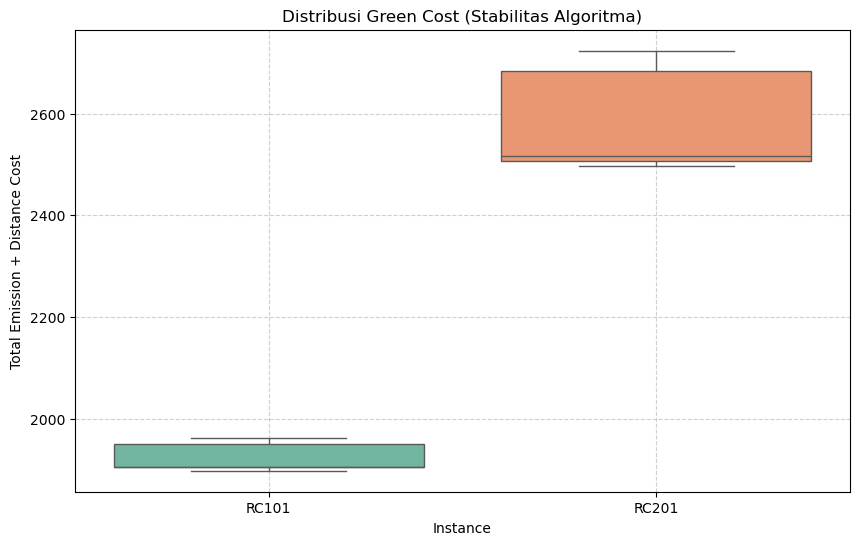

C:\Users\FATISDA UNS\AppData\Local\Temp\ipykernel_35896\3888059710.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Instance", y="Best_K", data=final_df, palette="coolwarm")


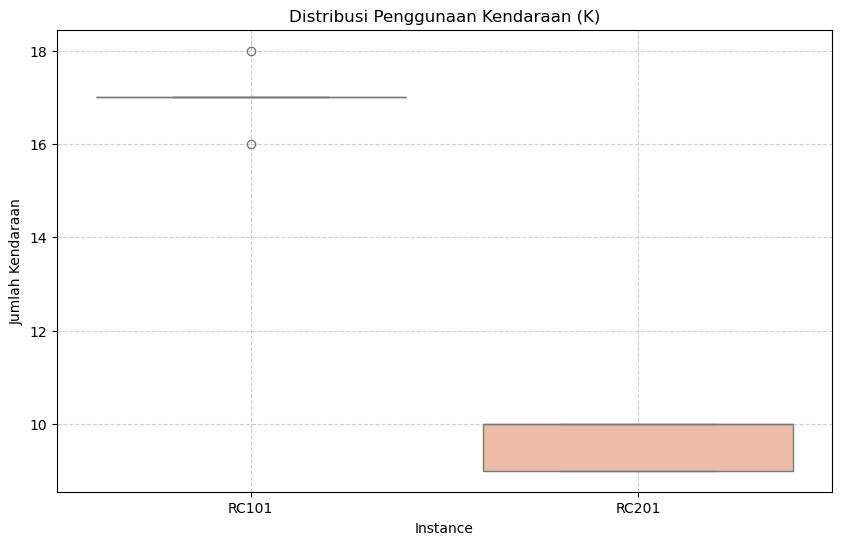

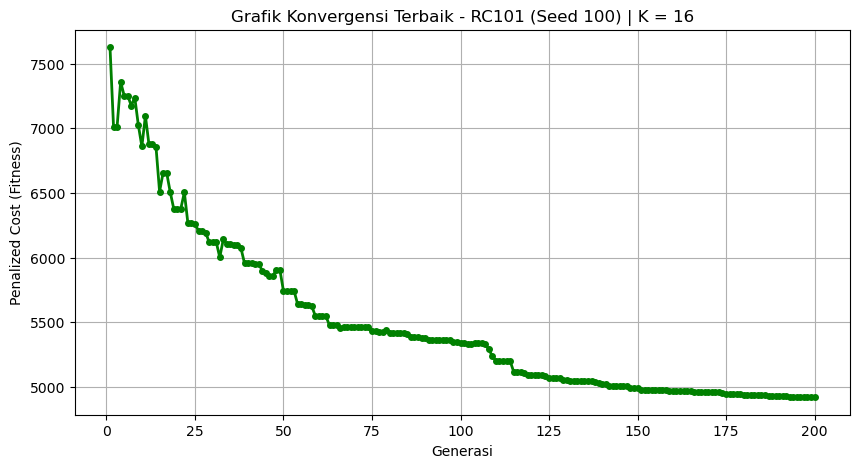

Grafik konvergensi RC101 (Run #1, Seed 100) dengan K=16 berhasil ditampilkan.


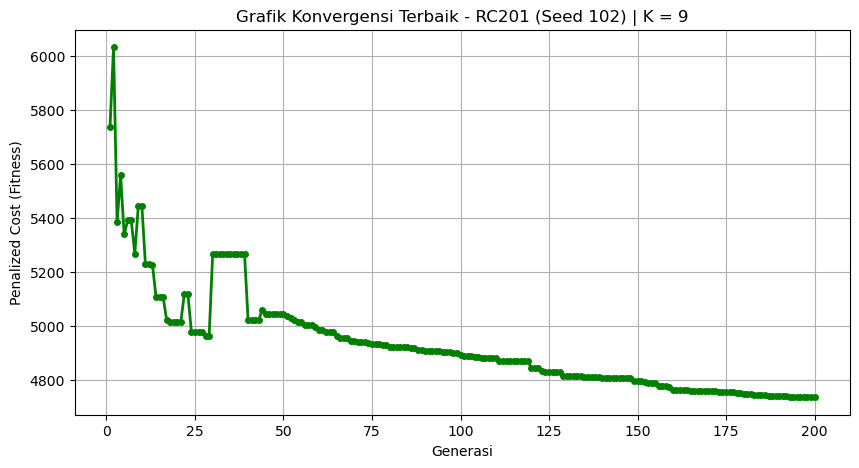

Grafik konvergensi RC201 (Run #3, Seed 102) dengan K=9 berhasil ditampilkan.


In [ ]:
# ==============================================================================
# CELL 25: VISUALISASI HASIL & EXPORT DATA
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==============================================================================
# FUNGSI HAKIM TUNGGAL: PENCARI RUN TERBAIK (LEKSIKOGRAFIS GREEN-VRPTW)
# ==============================================================================
def get_best_run_lexicographic(runs):
    """
    Mencari run terbaik berdasarkan aturan leksikografis VRP STANDAR:
    Prioritas 1: Harus Layak (Feasible)
    Prioritas 2: Jumlah Kendaraan (K)
    Prioritas 3: TOTAL EMISI Paling Rendah (Green Cost)
    """
    best_idx = 0
    # Set kondisi awal: (Infeasible, K tak hingga, Emisi tak hingga)
    best_criteria = (True, float('inf'), float('inf')) 
    
    for i, r in enumerate(runs):
        ind = r["best_ind"]
        sc = ind.solution_cost

        # Seleksi final: feasible-first, lalu minimisasi jumlah rute, lalu penalized cost
        current_criteria = (not ind.is_feasible, ind.n_routes, ind.penalized_cost)
        
        if current_criteria < best_criteria:
            best_criteria = current_criteria
            best_idx = i
            
    return best_idx, runs[best_idx]

# ================================================================
# 11. Visualisasi Hasil Eksperimen
# ================================================================

print("="*70)
print("📊 GENERATING PLOTS & FINAL REPORT")
print("="*70)

# Pastikan ada hasil untuk diproses
if 'exp_results' not in globals() or not exp_results:
    print("❌ Tidak ada data eksperimen. Jalankan Cell 24 terlebih dahulu!")
else:
    # 1. AGGREGATE DATA KE SATU DATAFRAME BESAR
    all_runs_data = []
    for inst_name, res in exp_results.items():
        df_summary = res["summary_df"]
        all_runs_data.append(df_summary)

    final_df = pd.concat(all_runs_data, ignore_index=True)

    # Simpan ke CSV Utama
    csv_filename = "GreenVRP_Thesis_Final_Results.csv"
    final_df.to_csv(csv_filename, index=False)
    print(f"✅ Data lengkap tersimpan di: {csv_filename} (Silakan Download)")

    # Tampilkan Tabel Rekap
    print("\n--- REKAPITULASI AKHIR ---")
    display(final_df[["Instance", "Run", "Best_K", "Best_Cost_Green", "Is_Feasible", "Time_Sec"]])

    # ------------------------------------------------------------
    # GRAFIK 1: BOXPLOT KUALITAS SOLUSI (Cost Stability)
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Instance", y="Best_Cost_Green", data=final_df, palette="Set2")
    plt.title("Distribusi Green Cost (Stabilitas Algoritma)")
    plt.ylabel("Total Emission + Distance Cost")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # ------------------------------------------------------------
    # GRAFIK 2: BOXPLOT JUMLAH KENDARAAN (Vehicle Usage)
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Instance", y="Best_K", data=final_df, palette="coolwarm")
    plt.title("Distribusi Penggunaan Kendaraan (K)")
    plt.ylabel("Jumlah Kendaraan")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # ------------------------------------------------------------
    # GRAFIK 3: KONVERGENSI (SEJARAH EVOLUSI)
    # ------------------------------------------------------------
    # Kita ambil Run terbaik secara LEKSIKOGRAFIS dari setiap Instance untuk diplot
    for inst_name, res in exp_results.items():
        runs = res["runs"]
        
        # --- MEMANGGIL FUNGSI HAKIM DI SINI ---
        best_run_idx, best_run = get_best_run_lexicographic(runs)

        hist = best_run["history"]
        if not hist: continue

        gens = [h["gen"] for h in hist]
        costs = [h["best_penalized_cost"] for h in hist] 

        plt.figure(figsize=(10, 5))
        plt.plot(gens, costs, marker='o', markersize=4, linestyle='-', linewidth=2, color='green')
        plt.title(f"Grafik Konvergensi Terbaik - {inst_name} (Seed {best_run['seed']}) | K = {best_run['best_ind'].n_routes}")
        plt.xlabel("Generasi")
        plt.ylabel("Penalized Cost (Fitness)")
        plt.grid(True)
        plt.show()

        print(f"Grafik konvergensi {inst_name} (Run #{best_run_idx+1}, Seed {best_run['seed']}) dengan K={best_run['best_ind'].n_routes} berhasil ditampilkan.")

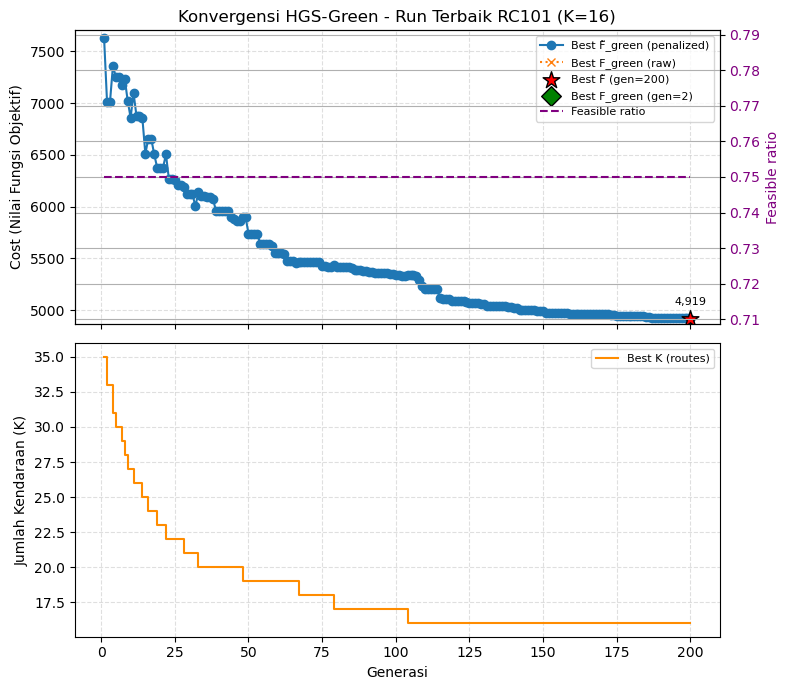

>> Ringkasan Run Terbaik (Leksikografis) untuk RC101:
   - Run Ke       : 1
   - Seed         : 100
   - K (routes)   : 16
   - F̃_green      : 4,919.25 (Penalized)
   - F_green      : 1,961.05 (Raw)
   - Feasible     : True
   - Waktu (detik): 16063.6
   - Gen Best F̃   : 200 (K = 16)
   - Improvement  : 2,708.10 (35.51% lebih baik dari generasi awal)


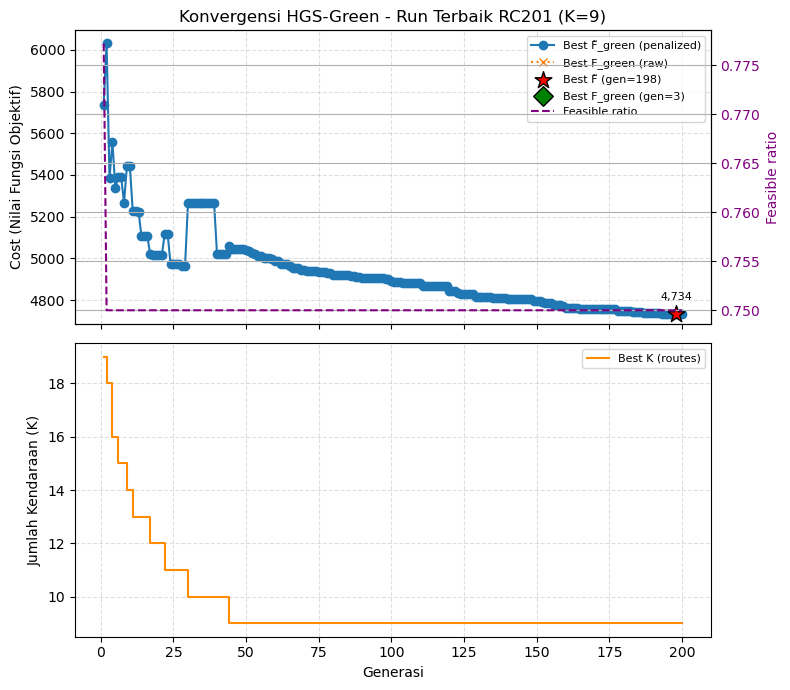

>> Ringkasan Run Terbaik (Leksikografis) untuk RC201:
   - Run Ke       : 3
   - Seed         : 102
   - K (routes)   : 9
   - F̃_green      : 4,734.48 (Penalized)
   - F_green      : 2,684.48 (Raw)
   - Feasible     : True
   - Waktu (detik): 14632.8
   - Gen Best F̃   : 198 (K = 9)
   - Improvement  : 1,002.78 (17.48% lebih baik dari generasi awal)


In [ ]:
# ==============================================================================
# Kurva Konvergensi F̃_green per Generasi 
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_convergence_for_best_run(instance_name: str):
    res = exp_results.get(instance_name, None)
    if res is None:
        print(f"[WARN] Tidak ditemukan hasil eksperimen untuk {instance_name}.")
        return

    df_summary = res["summary_df"]
    runs = res["runs"]

    if df_summary.empty:
        print(f"[WARN] summary_df kosong untuk {instance_name}.")
        return

    # --- MEMANGGIL FUNGSI HAKIM LEKSIKOGRAFIS ---
    best_run_idx, best_run = get_best_run_lexicographic(runs)
            
    best_row = df_summary.iloc[best_run_idx]
    hist = best_run["history"]

    if len(hist) == 0:
        print(f"[WARN] History kosong untuk run terbaik instance {instance_name}.")
        return

    gens         = [h["gen"] for h in hist]
    best_costs   = [h["best_penalized_cost"] for h in hist]
    best_green_cost = [h["best_green_cost"] for h in hist]
    feas_ratios  = [h["feasible_ratio"] for h in hist]
    best_nroutes = [h["best_n_routes"] for h in hist]

    idx_star_pen = int(np.argmin(best_costs))
    gen_star_pen = gens[idx_star_pen]
    cost_star_pen = best_costs[idx_star_pen]
    k_star_pen = best_nroutes[idx_star_pen]

    idx_star_green = int(np.argmin(best_green_cost))
    gen_star_green = gens[idx_star_green]
    cost_star_green = best_green_cost[idx_star_green]

    initial_cost = float(best_costs[0])
    improv_abs = initial_cost - cost_star_pen
    improv_rel = (improv_abs / initial_cost * 100.0) if initial_cost > 1e-9 else 0.0

    ymin = min(best_costs) * 0.99
    ymax = max(best_costs) * 1.01

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    line_pen, = ax1.plot(gens, best_costs, marker="o", label="Best F̃_green (penalized)")
    line_green, = ax1.plot(gens, best_green_cost, linestyle=":", marker="x", label="Best F_green (raw)")

    ax1.scatter(gen_star_pen, cost_star_pen, marker="*", s=160, color="red", edgecolors="black", zorder=5, label=f"Best F̃ (gen={gen_star_pen})")

    if (idx_star_green != idx_star_pen) or (abs(cost_star_green - cost_star_pen) > 1e-6):
        ax1.scatter(gen_star_green, cost_star_green, marker="D", s=100, color="green", edgecolors="black", zorder=5, label=f"Best F_green (gen={gen_star_green})")

    ax1.annotate(f"{cost_star_pen:,.0f}", xy=(gen_star_pen, cost_star_pen), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8)

    ax1.set_ylabel("Cost (Nilai Fungsi Objektif)")
    ax1.set_title(f"Konvergensi HGS-Green - Run Terbaik {instance_name} (K={best_row['Best_K']})")
    ax1.set_ylim(ymin, ymax)
    ax1.grid(True, linestyle="--", alpha=0.4)

    ax1b = ax1.twinx()
    line_feas, = ax1b.plot(gens, feas_ratios, linestyle="--", color='purple', label="Feasible ratio")
    ax1b.set_ylabel("Feasible ratio", color='purple')
    ax1b.tick_params(axis='y', labelcolor='purple')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", fontsize=8)

    ax2.step(gens, best_nroutes, where="post", color='darkorange', label="Best K (routes)")
    ax2.set_xlabel("Generasi")
    ax2.set_ylabel("Jumlah Kendaraan (K)")
    ax2.grid(True, linestyle="--", alpha=0.4)
    ax2.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f">> Ringkasan Run Terbaik (Leksikografis) untuk {instance_name}:")
    print(f"   - Run Ke       : {int(best_row['Run'])}")
    print(f"   - Seed         : {int(best_row['Seed'])}")
    print(f"   - K (routes)   : {int(best_row['Best_K'])}")
    print(f"   - F̃_green      : {cost_star_pen:,.2f} (Penalized)")
    print(f"   - F_green      : {best_row['Best_Cost_Green']:,.2f} (Raw)")
    print(f"   - Feasible     : {bool(best_row['Is_Feasible'])}")
    print(f"   - Waktu (detik): {best_row['Time_Sec']:.1f}")
    print(f"   - Gen Best F̃   : {gen_star_pen} (K = {k_star_pen})")
    print(f"   - Improvement  : {improv_abs:,.2f} ({improv_rel:.2f}% lebih baik dari generasi awal)")

# Plot konvergensi untuk RC101 dan RC201
for inst_name in ["RC101", "RC201"]:
    print("=" * 70)
    plot_convergence_for_best_run(inst_name)

In [ ]:
# ==============================================================================
# VISUALISASI FINAL RC101 (SINKRONISASI DENGAN INSPEKSI)
# ==============================================================================

import folium
from folium import plugins
import requests
import polyline
import time
import numpy as np

print("="*70)
print("🎬 MEMBUAT PETA INTERAKTIF RC101 (MATCHING INSPECTION)...")
print("="*70)

# ============================================================
# 1. LOAD KOORDINAT VALID DARI NPZ (RC101)
# ============================================================
try:
    # Pastikan variabel CORERC101NPZ sudah didefinisikan sebelumnya
    with np.load(CORERC101NPZ) as data:
        real_latlon = data['latlon']       # [N, 2]
        real_demand = data['demandunits']  # [N,]
        is_depot = data['isdepot']         # [N,] Boolean

    depot_idx = np.where(is_depot)[0][0]
    depot_loc_valid = real_latlon[depot_idx]
    print("✅ Berhasil memuat koordinat valid RC101.")

except NameError:
    print("❌ ERROR: Variabel 'CORERC101NPZ' tidak ditemukan.")
    print("   Harap definisikan ulang path file .npz Anda.")
    raise

# ============================================================
# 2. FUNGSI OSRM
# ============================================================
def get_osrm_route(start_lat, start_lon, end_lat, end_lon):
    # Euclidean ablation: straight-line route geometry.
    return [(start_lat, start_lon), (end_lat, end_lon)]

# ============================================================
# 3. PILIH SOLUSI (SINKRONISASI OTOMATIS LEKSIKOGRAFIS)
# ============================================================

if 'exp_results' in globals() and 'RC101' in exp_results:
    runs = exp_results['RC101']['runs']
    
    try:
        # Panggil fungsi Hakim Tunggal yang sudah kita buat di cell atas
        best_run_idx, target_run = get_best_run_lexicographic(runs)
        
        target_best_ind = target_run["best_ind"]
        seed = target_run["seed"]
        
        # Validasi Konsistensi Data
        routes = target_best_ind.routes_repr
        
        print(f"✅ MEMVISUALISASIKAN RUN #{best_run_idx + 1} (Seed {seed})")
        print(f"   Status Feasible : {target_best_ind.is_feasible}")
        print(f"   Total Cost      : {target_best_ind.green_cost:.2f}")
        print(f"   Total Emisi     : {target_best_ind.solution_cost.total_moving_emission + target_best_ind.solution_cost.total_idle_emission:.2f} gCO2")
        print(f"   Jumlah Rute (K) : {len(routes)} Rute")
        print("-" * 50)
        
    except Exception as e:
        raise ValueError(f"❌ Terjadi kesalahan saat memproses solusi: {e}")
else:
    raise ValueError("❌ Harap jalankan eksperimen RC101 terlebih dahulu.")

# ============================================================
# 4. GAMBAR PETA
# ============================================================
m = folium.Map(location=depot_loc_valid, zoom_start=13, tiles='CartoDB positron')

colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6',
    '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3'
]

# Sort agar urutan (Motor -> Van -> Truk) rapi di legenda layer
sorted_routes_with_orig_idx = sorted(enumerate(routes), key=lambda x: x[1][0])

print(f"🚀 Mulai menggambar {len(routes)} rute pada peta...")

for i, (orig_idx, (vtype_idx, route_custs)) in enumerate(sorted_routes_with_orig_idx):
    
    v_name = "KENDARAAN"
    if vtype_idx == 0: v_name = "MOTOR"
    elif vtype_idx == 1: v_name = "VAN"
    elif vtype_idx == 2: v_name = "TRUCK"

    layer_name = f"#{i+1} {v_name} (Stops: {len(route_custs)})"
    fg = folium.FeatureGroup(name=layer_name, show=True)
    color = colors[i % len(colors)]

    # --- TITIK AWAL (DEPOT) ---
    prev_node = 0
    prev_lat, prev_lon = real_latlon[prev_node]

    # Marker Depot (Sekali saja)
    if i == 0:
        folium.Marker(
            [prev_lat, prev_lon],
            popup="<b>DEPOT SENTRAL</b>",
            icon=folium.Icon(color='black', icon='home', prefix='fa')
        ).add_to(m)

    path_coords = []
    full_sequence = route_custs + [0]
    total_load = 0

    # --- GEOMETRI RUTE ---
    for next_node in full_sequence:
        curr_lat, curr_lon = real_latlon[next_node]

        if next_node != 0:
            dem = real_demand[next_node]
            total_load += dem

            # Marker Customer
            folium.CircleMarker(
                location=[curr_lat, curr_lon],
                radius=6 if vtype_idx == 2 else 4, 
                color=color,
                fill=True, fill_color='white', fill_opacity=1,
                tooltip=f"Cust {next_node}",
                popup=f"<b>Cust {next_node}</b><br>Load: {dem}<br>Via: {v_name}"
            ).add_to(fg)

        # Tarik Garis OSRM
        segment = get_osrm_route(prev_lat, prev_lon, curr_lat, curr_lon)
        path_coords.extend(segment)
        
        # Update posisi
        prev_lat, prev_lon = curr_lat, curr_lon
        
        # Delay kecil untuk API
        if len(full_sequence) > 20: time.sleep(0.005)

    # --- ANIMASI ANT-PATH ---
    plugins.AntPath(
        locations=path_coords,
        color=color,
        weight=5 if vtype_idx == 2 else 3, 
        opacity=0.8,
        delay=1200 if vtype_idx == 2 else 800, 
        dash_array=[10, 20],
        pulse_color='white',
        hardware_acceleration=True,
        tooltip=f"<b>{v_name} Rute {i+1}</b>",
        popup=f"Tipe: {v_name}<br>Total Load: {total_load}"
    ).add_to(fg)

    fg.add_to(m)

# 5. SAVE
folium.LayerControl(collapsed=False).add_to(m)
# Ganti TARGET_RUN_INDEX menjadi best_run_idx
filename = f"Peta_RC101_Run{best_run_idx+1}_Seed{seed}.html" 
m.save(filename)

print("="*70)
print(f"✅ PETA SELESAI! Disimpan sebagai: {filename}")
print(f"Silakan buka file ini dan bandingkan dengan hasil inspeksi.")
print("="*70)
m

🎬 MEMBUAT PETA INTERAKTIF RC101 (MATCHING INSPECTION)...
✅ Berhasil memuat koordinat valid RC101.
✅ MEMVISUALISASIKAN RUN #1 (Seed 100)
   Status Feasible : True
   Total Cost      : 1961.05
   Total Emisi     : 168.69 gCO2
   Jumlah Rute (K) : 16 Rute
--------------------------------------------------
🚀 Mulai menggambar 16 rute pada peta...
✅ PETA SELESAI! Disimpan sebagai: Peta_RC101_Run1_Seed100.html
Silakan buka file ini dan bandingkan dengan hasil inspeksi.


In [ ]:
# ==============================================================================
# VISUALISASI FINAL RC201 (SINKSORISASI DENGAN INSPEKSI)
# ==============================================================================

import folium
from folium import plugins
import requests
import polyline
import time
import numpy as np

print("="*70)
print("🎬 MEMBUAT PETA INTERAKTIF RC201 (MATCHING INSPECTION)...")
print("="*70)

# ============================================================
# 1. LOAD KOORDINAT VALID DARI NPZ (RC201)
# ============================================================
try:
    # Pastikan path file benar. Jika variabel ini hilang karena restart kernel, definisikan ulang string path-nya
    # contoh: CORERC201NPZ = "path/to/your/RC201.npz" 
    with np.load(CORERC201NPZ) as data:
        real_latlon = data['latlon']       # [N, 2]
        real_demand = data['demandunits']  # [N,]
        is_depot = data['isdepot']         # [N,] Boolean

    depot_idx = np.where(is_depot)[0][0]
    depot_loc_valid = real_latlon[depot_idx]
    print("✅ Berhasil memuat koordinat valid RC201.")

except NameError:
    print("❌ ERROR: Variabel 'CORERC201NPZ' tidak ditemukan.") 
    print("   Harap definisikan ulang path file .npz Anda sebelum menjalankan cell ini.")
    raise

# ============================================================
# 2. FUNGSI OSRM (SAMA SEPERTI SEBELUMNYA)
# ============================================================
def get_osrm_route(start_lat, start_lon, end_lat, end_lon):
    # Euclidean ablation: straight-line route geometry.
    return [(start_lat, start_lon), (end_lat, end_lon)]

# ============================================================
# 3. PILIH SOLUSI (SINKRONISASI OTOMATIS LEKSIKOGRAFIS)
# ============================================================

if 'exp_results' in globals() and 'RC201' in exp_results:
    runs = exp_results['RC201']['runs']
    
    try:
        # Panggil fungsi Hakim Tunggal yang sudah kita buat di cell atas
        best_run_idx, target_run = get_best_run_lexicographic(runs)
        
        target_best_ind = target_run["best_ind"]
        seed = target_run["seed"]
        
        # Validasi Konsistensi Data
        routes = target_best_ind.routes_repr
        
        print(f"✅ MEMVISUALISASIKAN RUN #{best_run_idx + 1} (Seed {seed})")
        print(f"   Status Feasible : {target_best_ind.is_feasible}")
        print(f"   Total Cost      : {target_best_ind.green_cost:.2f}")
        print(f"   Total Emisi     : {target_best_ind.solution_cost.total_moving_emission + target_best_ind.solution_cost.total_idle_emission:.2f} gCO2")
        print(f"   Jumlah Rute (K) : {len(routes)} Rute")
        print("-" * 50)
        
    except Exception as e:
        raise ValueError(f"❌ Terjadi kesalahan saat memproses solusi: {e}")
else:
    raise ValueError("❌ Harap jalankan eksperimen RC201 terlebih dahulu.")

# ============================================================
# 4. GAMBAR PETA
# ============================================================
m = folium.Map(location=depot_loc_valid, zoom_start=13, tiles='CartoDB positron')

# Warna Warni
colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6',
    '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3'
]

# Agar urutan warnanya sama dengan urutan di print inspeksi, kita sort juga
# (Opsional: Kalau mau persis urutan kendaraan kecil -> besar)
sorted_routes_with_orig_idx = sorted(enumerate(routes), key=lambda x: x[1][0])

print(f"🚀 Mulai menggambar {len(routes)} rute pada peta...")

# Kita loop berdasarkan rute yang sudah di-sort (agar Motor duluan, lalu Van, lalu Truk)
for i, (orig_idx, (vtype_idx, route_custs)) in enumerate(sorted_routes_with_orig_idx):
    
    v_name = "KENDARAAN"
    if vtype_idx == 0: v_name = "MOTOR"
    elif vtype_idx == 1: v_name = "VAN"
    elif vtype_idx == 2: v_name = "TRUCK"

    layer_name = f"#{i+1} {v_name} (Cost:{len(route_custs)} stops)"
    fg = folium.FeatureGroup(name=layer_name, show=True)
    color = colors[i % len(colors)]

    # --- TITIK AWAL (DEPOT) ---
    prev_node = 0
    prev_lat, prev_lon = real_latlon[prev_node]

    # Marker Depot cuma digambar sekali di awal
    if i == 0:
        folium.Marker(
            [prev_lat, prev_lon],
            popup="<b>DEPOT SENTRAL</b>",
            icon=folium.Icon(color='black', icon='home', prefix='fa')
        ).add_to(m)

    path_coords = []
    full_sequence = route_custs + [0] # Balik ke depot
    total_load = 0

    # --- GEOMETRI RUTE ---
    for next_node in full_sequence:
        curr_lat, curr_lon = real_latlon[next_node]

        if next_node != 0:
            dem = real_demand[next_node]
            total_load += dem

            # Marker Customer
            folium.CircleMarker(
                location=[curr_lat, curr_lon],
                radius=6 if vtype_idx == 2 else 4, 
                color=color,
                fill=True, fill_color='white', fill_opacity=1,
                tooltip=f"Cust {next_node}",
                popup=f"<b>Cust {next_node}</b><br>Load: {dem}<br>Via: {v_name}"
            ).add_to(fg)

        # Tarik garis OSRM
        segment = get_osrm_route(prev_lat, prev_lon, curr_lat, curr_lon)
        path_coords.extend(segment)
        prev_lat, prev_lon = curr_lat, curr_lon
        
        # Sedikit delay agar tidak dianggap spam oleh server OSRM
        if len(full_sequence) > 20: time.sleep(0.005) 

    # --- ANIMASI ANT-PATH ---
    plugins.AntPath(
        locations=path_coords,
        color=color,
        weight=5 if vtype_idx == 2 else 3, 
        opacity=0.8,
        delay=1200 if vtype_idx == 2 else 800, 
        dash_array=[10, 20],
        pulse_color='white',
        hardware_acceleration=True,
        tooltip=f"<b>{v_name} Rute {i+1}</b>",
        popup=f"Tipe: {v_name}<br>Total Load: {total_load}"
    ).add_to(fg)

    fg.add_to(m)

# 5. SAVE
folium.LayerControl(collapsed=False).add_to(m)
filename = f"Peta_RC201_Run{best_run_idx+1}_Seed{seed}.html"
m.save(filename)

print("="*70)
print(f"✅ PETA SELESAI! Disimpan sebagai: {filename}")
print("="*70)

m

🎬 MEMBUAT PETA INTERAKTIF RC201 (MATCHING INSPECTION)...
✅ Berhasil memuat koordinat valid RC201.
✅ MEMVISUALISASIKAN RUN #3 (Seed 102)
   Status Feasible : True
   Total Cost      : 2684.48
   Total Emisi     : 279.51 gCO2
   Jumlah Rute (K) : 9 Rute
--------------------------------------------------
🚀 Mulai menggambar 9 rute pada peta...
✅ PETA SELESAI! Disimpan sebagai: Peta_RC201_Run3_Seed102.html


In [ ]:
# ==============================================================================
# FUNGSI INSPEKSI DETAIL SOLUSI
# ==============================================================================
import numpy as np

def inspect_solution_final(exp_results, instance_name, run_index=0):
    """
    Menampilkan detail rute, muatan, dan jenis kendaraan.
    Fixed: Menghitung waktu tunggu (idle), service time, dan emisi yang akurat.
    """
    # 1. Validasi Input
    if instance_name not in exp_results:
        print(f"❌ Error: Hasil '{instance_name}' tidak ditemukan di exp_results.")
        return

    # 2. Ambil Data
    try:
        run_data = exp_results[instance_name]["runs"][run_index]
        ind = run_data["best_ind"]
        seed = run_data["seed"]

        # Ambil Object Problem & Rute
        prob = ind.problem
        raw_routes = ind.routes_repr

    except Exception as e:
        print(f"❌ Error mengambil data: {e}")
        return

    # 3. Header Laporan
    print("="*80)
    print(f"📊 DETAIL SOLUSI: {instance_name} | Run #{run_index+1} (Seed {seed})")
    print("="*80)

    sc = ind.solution_cost

    # Hitung feasible langsung dari violation (tidak bergantung cached property)
    is_feas = (
        sc.total_capacity_violation < 1e-4 and
        sc.total_tw_violation       < 1e-4 and
        sc.total_duration_violation < 1e-4
    )
    status = "✅ LAYAK" if is_feas else "❌ TIDAK LAYAK"

    print(f"Status         : {status}")
    print(f"Penalized Cost : {ind.penalized_cost:.2f}")
    print(f"Green Cost     : {ind.green_cost:.2f}")
    print(f"Total Emisi    : {sc.total_moving_emission + sc.total_idle_emission:.2f} kgCO2")
    print("-" * 80)

    # 4. Analisis Detail Per Rute
    total_dist_check = 0
    total_load_check = 0

    # Urutkan berdasarkan index kendaraan (0=Motor, 1=Van, 2=Truk)
    sorted_routes = sorted(raw_routes, key=lambda x: x[0])

    for i, (v_idx, route_nodes_np) in enumerate(sorted_routes):
        route_nodes = [int(x) for x in route_nodes_np]
        vt = prob.fleet_config.vehicle_types[v_idx]

        cap = getattr(vt, 'capacity_units', getattr(vt, 'capacity', 0))
        v_name = getattr(vt, 'name', 'Unknown').upper()
        em_move_rate = getattr(vt, 'ef_km', 0.0) 
        em_idle_rate = getattr(vt, 'ef_idle', 0.0)
        speed_factor = getattr(vt, 'speed_factor', 1.0)

        dist = 0.0
        load = 0.0
        
        # --- 1. SIMULASI WAKTU (pakai travel_time_matrix & tw yang sudah dikoreksi) ---
        ai_drive_time = 0.0   
        ai_idle_time  = 0.0   
        ai_service_time = 0.0 
        departure_time = compute_latest_departure_time(prob, route_nodes, vt)
        current_time  = departure_time
        dist = 0.0
        load = 0.0


        full_path = [0] + route_nodes + [0]


        for k in range(len(full_path) - 1):
            u = full_path[k]
            v = full_path[k+1]


            # Jarak & waktu tempuh
            d_uv = float(prob.dist_matrix[u][v])
            t_uv = float(prob.travel_time_matrix[u][v]) / speed_factor
            dist         += d_uv
            ai_drive_time += t_uv
            current_time  += t_uv


            if v != 0:  # bukan depot akhir
                load += float(prob.demand_units[v])


                tw_s = float(prob.tw_start[v])
                tw_e = float(prob.tw_end[v])


                # Waktu tunggu jika tiba terlalu awal
                if current_time < tw_s:
                    wait = tw_s - current_time
                    ai_idle_time += wait
                    current_time  = tw_s


                # Waktu layanan
                svc = float(prob.service_time[v])
                ai_service_time += svc
                current_time    += svc


        total_duration = current_time - departure_time  # = drive + idle + service

        # --- 2. EMISI ---
        emisi_gerak = dist * em_move_rate
        # idle emission dari idle + service (sesuai include_service_in_idle)
        idle_for_emission = ai_idle_time + ai_service_time  # asumsi include_service_in_idle=True
        emisi_diam  = idle_for_emission * em_idle_rate
        emission_est = emisi_gerak + emisi_diam


        # --- 3. TAMPILKAN LAPORAN ---
        route_str = "->".join(map(str, route_nodes))
        if len(route_str) > 85: route_str = route_str[:85] + "..."


        if cap > 0:
            load_pct = (load / cap) * 100
            bars     = min(10, int(load_pct / 10))
            load_bar = "█" * bars + "░" * (10 - bars)
        else:
            load_pct = 0
            load_bar = "ERROR (Cap=0)"


        print(f"🚚 RUTE #{i+1} | Tipe: {v_name} (Cap: {cap:.0f})")
        print(f"   ├─ Berangkat : menit {departure_time:.0f}")
        print(f"   ├─ Kembali   : menit {departure_time + total_duration:.0f}")
        print(f"   ├─ Muatan    : {load:.0f} unit ({load_pct:.1f}%) {load_bar}")
        print(f"   ├─ Statistik : Jarak {dist:.1f} km | Durasi {total_duration:.0f} menit")
        print(f"   ├─ Rincian   : {ai_drive_time:.0f}m nyetir + {ai_service_time:.0f}m servis + {ai_idle_time:.0f}m nunggu")
        print(f"   ├─ Emisi     : ~{emission_est:.2f} kgCO2")
        print(f"   └─ Jalur     : Depot(t={departure_time:.0f})->{route_str}->Depot(t={departure_time + total_duration:.0f})")
        print("-" * 40)

        total_dist_check += dist
        total_load_check += load

    print("="*80)
    print(f"🔍 Validasi Total:")
    print(f"   Total Jarak  : {total_dist_check:.1f} km")
    print(f"   Total Muatan : {total_load_check:.0f} unit")
    print("="*80)

# ==============================================================================
# JALANKAN CHECKER (MENGGUNAKAN LEKSIKOGRAFIS TERBAIK)
# ==============================================================================

print("\n>>> MENCARI SOLUSI TERBAIK RC101 <<<")
if "RC101" in exp_results:
    best_idx_101, _ = get_best_run_lexicographic(exp_results["RC101"]["runs"])
    print(f"[*] Terpilih Run #{best_idx_101 + 1} berdasarkan kriteria Leksikografis (K & Emisi).")
    inspect_solution_final(exp_results, "RC101", run_index=best_idx_101)

print("\n\n>>> MENCARI SOLUSI TERBAIK RC201 <<<")
if "RC201" in exp_results:
    best_idx_201, _ = get_best_run_lexicographic(exp_results["RC201"]["runs"])
    print(f"[*] Terpilih Run #{best_idx_201 + 1} berdasarkan kriteria Leksikografis (K & Emisi).")
    inspect_solution_final(exp_results, "RC201", run_index=best_idx_201)


>>> MENCARI SOLUSI TERBAIK RC101 <<<
[*] Terpilih Run #1 berdasarkan kriteria Leksikografis (K & Emisi).
📊 DETAIL SOLUSI: RC101 | Run #1 (Seed 100)
Status         : ✅ LAYAK
Penalized Cost : 4919.25
Green Cost     : 1961.05
Total Emisi    : 168.69 kgCO2
--------------------------------------------------------------------------------
🚚 RUTE #1 | Tipe: MOTORCYCLE (Cap: 60)
   ├─ Berangkat : menit 109
   ├─ Kembali   : menit 186
   ├─ Muatan    : 51 unit (85.0%) ████████░░
   ├─ Statistik : Jarak 24.3 km | Durasi 78 menit
   ├─ Rincian   : 38m nyetir + 40m servis + 0m nunggu
   ├─ Emisi     : ~2.83 kgCO2
   └─ Jalur     : Depot(t=109)->8->46->13->68->Depot(t=186)
----------------------------------------
🚚 RUTE #2 | Tipe: MOTORCYCLE (Cap: 60)
   ├─ Berangkat : menit 53
   ├─ Kembali   : menit 176
   ├─ Muatan    : 56 unit (93.3%) █████████░
   ├─ Statistik : Jarak 38.4 km | Durasi 124 menit
   ├─ Rincian   : 56m nyetir + 60m servis + 7m nunggu
   ├─ Emisi     : ~4.51 kgCO2
   └─ Jalur     

In [ ]:
"""
Enhanced Green-VRPTW Interactive Dashboard Builder
Versi baru dengan banyak fitur tambahan.
"""

import json
import html as _html
import requests
import numpy as np
import polyline
from pathlib import Path

# ── Palette & styling ─────────────────────────────────────────────────────────
ROUTE_PALETTE = [
    "#E63946","#457B9D","#2A9D8F","#E9C46A","#F4A261",
    "#264653","#A8DADC","#8338EC","#FB5607","#3A86FF",
    "#06D6A0","#FFB703","#CB4335","#1B4F72","#7D3C98",
    "#2ECC71","#E74C3C","#3498DB","#F39C12","#16A085",
]

VEHICLE_STYLE = {
    "motorcycle": {"color": "#3A86FF", "icon": "fa-motorcycle", "label": "Motorcycle"},
    "van":        {"color": "#FB5607", "icon": "fa-van-shuttle", "label": "Van"},
    "truck":      {"color": "#8338EC", "icon": "fa-truck",       "label": "Truck"},
}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _escape(s): return _html.escape(str(s), quote=True)
def _sf(x, d=0.0):
    try: return float(x)
    except: return float(d)
def _vkey(name):
    n = str(name).lower()
    if "motor" in n: return "motorcycle"
    if "van"   in n: return "van"
    if "truck" in n: return "truck"
    return n
def _norm_ll(pair):
    lat, lon = float(pair[0]), float(pair[1])
    if abs(lat) > 90 and abs(lon) <= 90: lat, lon = lon, lat
    return [lat, lon]

def _build_path(points):
    # Euclidean ablation: draw direct straight-line segments between successive points.
    if len(points) < 2:
        return points
    full = [points[0]]
    for p in points[1:]:
        if full[-1] != p:
            full.append(p)
    return full

def _get_npz(instance_name, rc101_npz, rc201_npz):
    if instance_name == "RC101": return rc101_npz
    if instance_name == "RC201": return rc201_npz
    raise ValueError(f"Unknown instance: {instance_name}")


# ── Main builder ──────────────────────────────────────────────────────────────
def build_interactive_dashboard(
    instance_name, exp_results,
    rc101_npz, rc201_npz,
    get_best_run_fn,
    output_html=None,
    output_dir=None,
    enable_heatmap=True,
):
    if instance_name not in exp_results:
        raise ValueError(f"'{instance_name}' not in exp_results")

    npz_path = _get_npz(instance_name, rc101_npz, rc201_npz)

    with np.load(npz_path) as data:
        real_latlon = np.array([_norm_ll(p) for p in data["latlon"]], dtype=float)
        is_depot    = data["isdepot"]

    depot_idx = int(np.where(is_depot)[0][0])
    depot_lat, depot_lon = real_latlon[depot_idx]

    runs = exp_results[instance_name]["runs"]
    best_run_idx, target_run = get_best_run_fn(runs)
    ind  = target_run["best_ind"]
    prob = ind.problem
    sc   = ind.solution_cost

    routes      = list(getattr(ind, "routes_repr", []))
    route_costs = list(getattr(sc,  "route_costs", []))
    n = min(len(routes), len(route_costs))
    routes, route_costs = routes[:n], route_costs[:n]

    # ── Build route payloads ──────────────────────────────────────────────────
    customer_route_meta = {}
    route_payloads      = []
    heat_points         = []

    for ridx, ((v_idx, rn_np), rc) in enumerate(zip(routes, route_costs), 1):
        rn  = [int(x) for x in rn_np]
        vt  = prob.fleet_config.vehicle_types[v_idx]
        vk  = _vkey(vt.name)
        vs  = VEHICLE_STYLE.get(vk, {"color":"#888","icon":"fa-car","label":vt.name.title()})
        col = ROUTE_PALETTE[(ridx-1) % len(ROUTE_PALETTE)]

        pts  = [real_latlon[prob.depot_index].tolist()] + [real_latlon[c].tolist() for c in rn] + [real_latlon[prob.depot_index].tolist()]
        geom = _build_path(pts)

        dep   = _sf(getattr(rc,"departure_time",0))
        ret   = _sf(getattr(rc,"return_time",dep + _sf(getattr(rc,"route_duration",0))))
        wait  = _sf(getattr(rc, "pure_waiting", 0.0))
        svc   = _sf(getattr(rc,"service_time_total", sum(_sf(prob.service_time[c]) for c in rn)))
        drive = _sf(getattr(rc,"moving_time",0))
        dist  = _sf(getattr(rc,"distance",0))
        dur   = _sf(getattr(rc,"route_duration",0))
        load  = _sf(getattr(rc,"total_demand",0))
        me    = _sf(getattr(rc,"moving_emission",0))
        ie    = _sf(getattr(rc,"idle_emission",0))
        gc    = _sf(getattr(rc,"green_cost",0))
        pc    = _sf(getattr(rc,"penalized_cost",0))

        for c in rn:
            customer_route_meta[int(c)] = {
                "route_id":ridx,"route_label":f"R{ridx}",
                "vehicle_type":vt.name,"vehicle_label":vs["label"],
                "dep":dep,"ret":ret,
            }

        if enable_heatmap and wait > 0:
            w_each = wait / max(len(rn),1)
            for c in rn:
                lat,lon = real_latlon[c]
                heat_points.append([float(lat),float(lon),float(w_each)])

        # Build TW span for timeline
        tw_span = max((_sf(prob.tw_end[c]) for c in rn), default=dep+dur) if rn else dep+dur

        route_payloads.append({
            "route_id":ridx, "label":f"R{ridx}",
            "vehicle_type":vt.name, "vehicle_label":vs["label"],
            "vehicle_icon":vs["icon"], "vehicle_cap":_sf(vt.capacity_units),
            "color":col, "type_color":vs["color"],
            "n_customers":len(rn), "customer_ids":rn,
            "load":load, "dist":dist, "dur":dur,
            "dep":dep, "ret":ret, "drive":drive, "svc":svc, "wait":wait,
            "me":me, "ie":ie, "emission":me+ie,
            "green_cost":gc, "penalized_cost":pc,
            "geometry":geom,
            "seq":"Depot → " + " → ".join(f"C{c}" for c in rn) + " → Depot",
        })

    # ── Customer list ─────────────────────────────────────────────────────────
    customers = []
    for idx in prob.customer_indices:
        idx = int(idx)
        lat,lon = real_latlon[idx]
        meta    = customer_route_meta.get(idx,{})
        customers.append({
            "id":idx, "lat":float(lat), "lon":float(lon),
            "demand":_sf(prob.demand_units[idx]),
            "tw_start":_sf(prob.tw_start[idx]), "tw_end":_sf(prob.tw_end[idx]),
            "service":_sf(prob.service_time[idx]),
            "route_id":meta.get("route_id"), "route_label":meta.get("route_label","–"),
            "vehicle_type":meta.get("vehicle_type",""), "vehicle_label":meta.get("vehicle_label","–"),
            "dep":meta.get("dep",0), "ret":meta.get("ret",0),
        })
    customers.sort(key=lambda x: x["id"])

    # ── Vehicle summary ───────────────────────────────────────────────────────
    vsumm = {}
    for r in route_payloads:
        vt = r["vehicle_type"]
        if vt not in vsumm:
            vsumm[vt] = {"routes":0,"customers":0,"dist":0.0,"wait":0.0,"emission":0.0,"load":0.0,"cap":r["vehicle_cap"]}
        vsumm[vt]["routes"]    += 1
        vsumm[vt]["customers"] += r["n_customers"]
        vsumm[vt]["dist"]      += r["dist"]
        vsumm[vt]["wait"]      += r["wait"]
        vsumm[vt]["emission"]  += r["emission"]
        vsumm[vt]["load"]      += r["load"]

    # ── Summary metrics ───────────────────────────────────────────────────────
    tot_dist     = sum(r["dist"]     for r in route_payloads)
    tot_wait     = sum(r["wait"]     for r in route_payloads)
    tot_emission = sum(r["emission"] for r in route_payloads)
    avg_wait     = tot_wait / len(route_payloads) if route_payloads else 0
    on_time      = _sf(getattr(sc,"on_time_ratio",0))
    if on_time == 0 and len(customers) > 0:
        late = _sf(getattr(sc,"total_late_customers",0))
        serv = _sf(getattr(sc,"total_customers",len(customers)))
        if serv > 0: on_time = max(0.0, 1-(late/serv))

    lats = [depot_lat]+[c["lat"] for c in customers]
    lons = [depot_lon]+[c["lon"] for c in customers]
    ctr_lat = (min(lats)+max(lats))/2
    ctr_lon = (min(lons)+max(lons))/2

    horizon = max(r["ret"] for r in route_payloads) if route_payloads else 480

    payload = {
        "instance": instance_name,
        "run_idx": int(best_run_idx+1),
        "seed": int(target_run["seed"]),
        "feasible": ind.is_feasible,
        "green_cost": _sf(getattr(ind,"green_cost",0)),
        "penalized_cost": _sf(getattr(ind,"penalized_cost",0)),
        "K": len(route_payloads),
        "tot_dist": tot_dist, "tot_wait": tot_wait,
        "tot_emission": tot_emission, "avg_wait": avg_wait,
        "on_time": on_time,
        "horizon": horizon,
        "depot": {"lat":depot_lat,"lon":depot_lon},
        "center": {"lat":ctr_lat,"lon":ctr_lon},
        "routes": route_payloads,
        "customers": customers,
        "vsumm": vsumm,
        "heat": heat_points,
    }

    html = _render_html(payload)

    if output_html is None:
        od = Path(output_dir) if output_dir else Path(".")
        od.mkdir(parents=True, exist_ok=True)
        output_html = od / f"{instance_name}_dashboard_euclidean.html"
    Path(output_html).write_text(html, encoding="utf-8")
    print(f"✅ Dashboard saved → {output_html}")
    return str(output_html)


def build_comparison_page(left_html, right_html, output_html=None, output_dir=None):
    lname = Path(left_html).name
    rname = Path(right_html).name
    if output_html is None:
        od = Path(output_dir) if output_dir else Path(".")
        output_html = od / "comparison_dashboard.html"
    Path(output_html).write_text(f"""<!DOCTYPE html>
<html lang="id"><head>
<meta charset="utf-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1"/>
<title>RC101 vs RC201 — Green-VRPTW</title>
<link rel="preconnect" href="https://fonts.googleapis.com"/>
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@700;800&family=DM+Sans:wght@400;500;600&display=swap" rel="stylesheet"/>
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{background:#0a0e1a;font-family:'DM Sans',sans-serif;height:100vh;display:flex;flex-direction:column;overflow:hidden}}
.topbar{{
  background:linear-gradient(90deg,#0a0e1a 0%,#111827 100%);
  border-bottom:1px solid rgba(255,255,255,.07);
  padding:14px 24px;display:flex;align-items:center;justify-content:space-between;gap:16px;
}}
.topbar-title{{font-family:'Syne',sans-serif;font-size:20px;font-weight:800;color:#fff;letter-spacing:-.3px}}
.topbar-subtitle{{color:#64748b;font-size:13px;margin-top:2px}}
.badge{{
  display:inline-block;padding:5px 14px;border-radius:999px;font-size:12px;font-weight:600;
  background:rgba(99,102,241,.18);color:#818cf8;border:1px solid rgba(99,102,241,.3);
}}
.frames{{display:flex;flex:1;gap:10px;padding:10px;overflow:hidden}}
.frame-wrap{{flex:1;display:flex;flex-direction:column;gap:6px;min-width:0}}
.frame-label{{
  color:#94a3b8;font-size:12px;font-weight:600;text-transform:uppercase;letter-spacing:.8px;
  padding:0 4px;
}}
iframe{{
  flex:1;border:1px solid rgba(255,255,255,.08);border-radius:16px;background:#111827;
  box-shadow:0 20px 60px rgba(0,0,0,.4);
}}
.divider{{
  width:4px;background:rgba(255,255,255,.05);border-radius:4px;cursor:col-resize;
  display:flex;align-items:center;justify-content:center;flex-shrink:0;
}}
.divider::after{{content:'⋮';color:rgba(255,255,255,.2);font-size:18px}}
</style>
</head>
<body>
<div class="topbar">
  <div>
    <div class="topbar-title">Green-VRPTW — Perbandingan Instance</div>
    <div class="topbar-subtitle">RC101 (TW Sempit) vs RC201 (TW Lebar) — Kota Surakarta</div>
  </div>
  <div class="badge">Hybrid Genetic Search + Bellman-Ford Split</div>
</div>
<div class="frames">
  <div class="frame-wrap">
    <div class="frame-label">RC101 — Time Window Sempit</div>
    <iframe src="{lname}"></iframe>
  </div>
  <div class="divider"></div>
  <div class="frame-wrap">
    <div class="frame-label">RC201 — Time Window Lebar</div>
    <iframe src="{rname}"></iframe>
  </div>
</div>
</body></html>""", encoding="utf-8")
    print(f"✅ Comparison page saved → {output_html}")
    return str(output_html)


# ── HTML renderer ─────────────────────────────────────────────────────────────
def _render_html(d):
    data_json = json.dumps(d, ensure_ascii=False)

    # Pre-render timeline bars (Python side for simplicity)
    horizon = max(d["horizon"], 1)

    timeline_rows = []
    for r in d["routes"]:
        dep = r["dep"]; drive = r["drive"]; svc = r["svc"]; wait = r["wait"]; ret = r["ret"]
        total = ret - dep if ret > dep else drive + svc + wait

        def pct(v): return max(0, min(100, v / horizon * 100))

        dep_pct   = pct(dep)
        drive_pct = pct(drive)
        svc_pct   = pct(svc)
        wait_pct  = pct(wait)

        timeline_rows.append(f"""
        <div class="tl-row">
          <div class="tl-label" title="{_escape(r['label'])} - {_escape(r['vehicle_label'])}">
            <span class="tl-dot" style="background:{_escape(r['color'])}"></span>
            {_escape(r['label'])}
          </div>
          <div class="tl-bar-wrap">
            <div class="tl-spacer" style="width:{dep_pct:.2f}%"></div>
            <div class="tl-seg drive"  style="width:{drive_pct:.2f}%" title="Nyetir {drive:.0f}m"></div>
            <div class="tl-seg svc"    style="width:{svc_pct:.2f}%"   title="Servis {svc:.0f}m"></div>
            <div class="tl-seg wait"   style="width:{wait_pct:.2f}%"  title="Tunggu {wait:.0f}m"></div>
          </div>
          <div class="tl-info">{dep:.0f}→{ret:.0f}</div>
        </div>""")
    timeline_html = "\n".join(timeline_rows)

    # Route cards
    route_cards = []
    for r in d["routes"]:
        vk   = _vkey(r["vehicle_type"])
        vs   = VEHICLE_STYLE.get(vk, {"color":"#888","icon":"fa-car"})
        util = r["load"] / max(r["vehicle_cap"],1) * 100
        ubar = min(100, util)
        uclr = "#22c55e" if util < 75 else "#f59e0b" if util < 95 else "#ef4444"
        emit = r["emission"]
        route_cards.append(f"""
        <div class="rcard" data-route-id="{r['route_id']}" data-vtype="{_escape(r['vehicle_type'])}"
             onclick="focusRoute({r['route_id']})">
          <div class="rcard-head">
            <div style="display:flex;align-items:center;gap:8px">
              <div class="rbadge" style="background:{_escape(r['color'])}">{_escape(r['label'])}</div>
              <div>
                <div class="rcard-title">{_escape(r['vehicle_label'])}</div>
                <div class="rcard-sub">{r['n_customers']} customer · {r['dist']:.1f} km</div>
              </div>
            </div>
            <div class="rcard-emit" title="Emisi kgCO2">{emit:.1f}</div>
          </div>
          <div class="cap-bar-wrap" title="Utilisasi kapasitas {util:.0f}%">
            <div class="cap-bar" style="width:{ubar:.1f}%;background:{uclr}"></div>
          </div>
          <div class="rcard-stats">
            <div><span>Dep</span><b>{r['dep']:.0f}m</b></div>
            <div><span>Ret</span><b>{r['ret']:.0f}m</b></div>
            <div><span>Drive</span><b>{r['drive']:.0f}m</b></div>
            <div><span>Wait</span><b>{r['wait']:.0f}m</b></div>
            <div><span>Load</span><b>{r['load']:.0f}/{r['vehicle_cap']:.0f}</b></div>
          </div>
        </div>""")
    route_cards_html = "\n".join(route_cards)

    # Customer table rows
    cust_rows = []
    for c in d["customers"]:
        rid = c["route_id"] or "–"
        rl  = c["route_label"] or "–"
        cust_rows.append(f"""
        <tr class="crow" data-cid="{c['id']}" onclick="focusCustomer({c['id']})">
          <td><span class="ctag">C{c['id']}</span></td>
          <td>{c['demand']:.0f}</td>
          <td>{c['tw_start']:.0f}–{c['tw_end']:.0f}</td>
          <td>{c['service']:.0f}</td>
          <td>{rl}</td>
          <td>{_escape(c['vehicle_label'])}</td>
        </tr>""")
    cust_rows_html = "\n".join(cust_rows)

    # Vehicle summary cards
    vsumm_cards = []
    for vt, info in d["vsumm"].items():
        vk  = _vkey(vt)
        vs  = VEHICLE_STYLE.get(vk, {"color":"#888","icon":"fa-car","label":vt.title()})
        avg_util = info["load"] / max(info["cap"] * info["routes"], 1) * 100
        vsumm_cards.append(f"""
        <div class="vcard" style="border-top:3px solid {_escape(vs['color'])}">
          <div class="vcard-head">
            <div class="vcard-icon" style="background:{_escape(vs['color'])}20;color:{_escape(vs['color'])}">
              <i class="fa-solid {_escape(vs['icon'])}"></i>
            </div>
            <div>
              <div class="vcard-title">{_escape(vs['label'])}</div>
              <div class="vcard-sub">{info['routes']} rute · {info['customers']} pelanggan</div>
            </div>
          </div>
          <div class="vcard-grid">
            <div><span>Total Jarak</span><b>{info['dist']:.1f} km</b></div>
            <div><span>Total Emisi</span><b>{info['emission']:.1f} kgCO2</b></div>
            <div><span>Total Waiting</span><b>{info['wait']:.0f} mnt</b></div>
            <div><span>Avg Utilisasi</span><b>{avg_util:.0f}%</b></div>
          </div>
          <button class="btn-filter" onclick="filterVehicle('{_escape(vt)}')">
            <i class="fa-solid fa-filter"></i> Filter rute ini
          </button>
        </div>""")
    vsumm_html = "\n".join(vsumm_cards)

    status_color = "#22c55e" if d["feasible"] else "#ef4444"
    status_text  = "LAYAK ✓" if d["feasible"] else "TIDAK LAYAK ✗"

    # sebelum return f"""..."""
    sim_speed_html = """
    <select id="sim-speed" style="background:var(--bg4);border:1px solid var(--border);
    color:var(--text);border-radius:10px;padding:5px 8px;font-size:11px;cursor:pointer">
      <option value="2">2×</option>
      <option value="4" selected>4×</option>
      <option value="8">8×</option>
      <option value="16">16×</option>
      <option value="32">32×</option>
    </select>
    """

    single_route_options = "".join(
        f'<option value="{r["route_id"]}">{_escape(r["label"])} — {_escape(r["vehicle_label"])} ({r["dep"]:.0f}→{r["ret"]:.0f} mnt)</option>'
        for r in d["routes"]
    )

    single_route_panel_html = f"""
    <div style="background:var(--bg4);border:1px solid var(--border);border-radius:14px;padding:12px;margin-bottom:10px">
      <div style="font-size:11px;font-weight:700;color:var(--muted);text-transform:uppercase;letter-spacing:.6px;margin-bottom:9px">
        ▶ Animasi Per Rute
      </div>
      <div style="display:flex;gap:8px;align-items:center">
        <select id="single-route-sel" style="flex:1;background:var(--bg3);border:1px solid var(--border);
          color:var(--text);border-radius:10px;padding:6px 9px;font-size:11px">
          {single_route_options}
        </select>
        <button onclick="startRouteSim(document.getElementById('single-route-sel').value)"
          style="background:rgba(99,102,241,.2);border:1px solid rgba(99,102,241,.4);color:#a5b4fc;
          border-radius:10px;padding:6px 12px;font-size:11px;font-weight:700;cursor:pointer">▶ Jalankan</button>
      </div>
      <div id="single-sim-status" style="font-size:10px;color:var(--muted);margin-top:6px">Pilih rute dan tekan ▶</div>
    </div>
    """
    
    
    return f"""<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="utf-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1"/>
<title>{_escape(d['instance'])} — Green-VRPTW Dashboard</title>

<link rel="preconnect" href="https://fonts.googleapis.com"/>
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@700;800&family=DM+Sans:ital,wght@0,400;0,500;0,600;1,400&display=swap" rel="stylesheet"/>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.0/css/all.min.css"/>
<link rel="stylesheet" href="https://unpkg.com/leaflet.markercluster/dist/MarkerCluster.css"/>
<link rel="stylesheet" href="https://unpkg.com/leaflet.markercluster/dist/MarkerCluster.Default.css"/>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://unpkg.com/leaflet.markercluster/dist/leaflet.markercluster.js"></script>
<script src="https://unpkg.com/leaflet-polylinedecorator@1.7.0/dist/leaflet.polylineDecorator.min.js"></script>
<script src="https://unpkg.com/leaflet-ant-path/dist/leaflet-ant-path.min.js"></script>
<script src="https://unpkg.com/leaflet.heat/dist/leaflet-heat.js"></script>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.3/dist/chart.umd.min.js"></script>

<style>
/* ── Reset & Base ───────────────────────────────────────────────────────────── */
*{{box-sizing:border-box;margin:0;padding:0}}
:root{{
  --bg:#0a0e1a; --bg2:#111827; --bg3:#1e293b; --bg4:rgba(255,255,255,.04);
  --border:rgba(255,255,255,.08); --border2:rgba(255,255,255,.12);
  --text:#e2e8f0; --muted:#64748b; --accent:#6366f1;
  --green:#22c55e; --amber:#f59e0b; --red:#ef4444;
  --sidebar:360px;
}}
html,body{{height:100%;overflow:hidden;background:var(--bg);color:var(--text);font-family:'DM Sans',sans-serif}}

/* ── Layout ─────────────────────────────────────────────────────────────────── */
.app{{display:flex;width:100vw;height:100vh;overflow:hidden}}
.sidebar{{
  width:var(--sidebar);min-width:var(--sidebar);max-width:var(--sidebar);
  background:var(--bg2);display:flex;flex-direction:column;
  border-right:1px solid var(--border);z-index:900;overflow:hidden;
}}
#map{{flex:1;height:100%;position:relative}}

/* ── Header ─────────────────────────────────────────────────────────────────── */
.header{{
  padding:16px;border-bottom:1px solid var(--border);flex-shrink:0;
  background:linear-gradient(135deg,var(--bg2) 0%,rgba(99,102,241,.08) 100%);
}}
.header-top{{display:flex;align-items:center;justify-content:space-between;gap:8px;margin-bottom:12px}}
.instance-badge{{
  font-family:'Syne',sans-serif;font-size:22px;font-weight:800;letter-spacing:-0.5px;
  background:linear-gradient(135deg,#818cf8,#c084fc);-webkit-background-clip:text;
  -webkit-text-fill-color:transparent;background-clip:text;
}}
.status-pill{{
  font-size:11px;font-weight:700;padding:4px 10px;border-radius:999px;letter-spacing:.5px;
  background:{status_color}22;color:{status_color};border:1px solid {status_color}44;
}}
.run-info{{color:var(--muted);font-size:12px;margin-bottom:12px}}

/* KPI grid */
.kpi-grid{{display:grid;grid-template-columns:repeat(2,1fr);gap:8px}}
.kpi{{
  background:var(--bg4);border:1px solid var(--border);border-radius:14px;
  padding:10px 12px;transition:transform .15s;
}}
.kpi:hover{{transform:translateY(-1px);border-color:var(--border2)}}
.kpi-label{{font-size:10px;text-transform:uppercase;letter-spacing:.7px;color:var(--muted);margin-bottom:4px}}
.kpi-val{{font-family:'Syne',sans-serif;font-size:22px;font-weight:800;line-height:1}}
.kpi-sub{{font-size:10px;color:var(--muted);margin-top:3px}}

/* ── Toolbar ─────────────────────────────────────────────────────────────────── */
.toolbar{{
  padding:10px 12px;border-bottom:1px solid var(--border);flex-shrink:0;
  display:flex;flex-wrap:wrap;gap:5px;
}}
.tbtn{{
  display:inline-flex;align-items:center;gap:5px;
  background:var(--bg4);border:1px solid var(--border);color:var(--text);
  border-radius:10px;padding:6px 11px;font-size:11px;font-weight:600;cursor:pointer;
  transition:background .15s,border-color .15s;white-space:nowrap;
}}
.tbtn:hover,.tbtn.active{{background:rgba(99,102,241,.2);border-color:rgba(99,102,241,.5);color:#a5b4fc}}
.tbtn i{{font-size:10px}}

/* ── Tabs ────────────────────────────────────────────────────────────────────── */
.tabs{{display:flex;border-bottom:1px solid var(--border);flex-shrink:0}}
.tab{{
  flex:1;padding:11px 6px;font-size:12px;font-weight:600;text-align:center;
  color:var(--muted);cursor:pointer;border-bottom:2px solid transparent;
  transition:color .15s,border-color .15s;
}}
.tab.active{{color:#fff;border-bottom-color:#6366f1}}
.tab-panels{{flex:1;overflow:hidden;position:relative}}
.tab-panel{{
  position:absolute;inset:0;overflow-y:auto;padding:12px;
  opacity:0;pointer-events:none;transition:opacity .2s;
}}
.tab-panel.active{{opacity:1;pointer-events:auto}}

/* ── Route cards ─────────────────────────────────────────────────────────────── */
.rcard{{
  background:var(--bg4);border:1px solid var(--border);border-radius:16px;
  padding:12px;margin-bottom:8px;cursor:pointer;
  transition:transform .15s,border-color .15s,background .15s;
}}
.rcard:hover{{transform:translateY(-1px);border-color:var(--border2);background:rgba(255,255,255,.06)}}
.rcard.active{{border-color:#6366f1;background:rgba(99,102,241,.1)}}
.rcard-head{{display:flex;justify-content:space-between;align-items:flex-start;margin-bottom:8px}}
.rbadge{{
  padding:3px 9px;border-radius:999px;font-size:11px;font-weight:800;color:#fff;margin-right:2px;
}}
.rcard-title{{font-size:13px;font-weight:700;line-height:1.2}}
.rcard-sub{{font-size:11px;color:var(--muted);margin-top:2px}}
.rcard-emit{{font-size:13px;font-weight:700;color:#a78bfa}}
.cap-bar-wrap{{height:4px;background:rgba(255,255,255,.1);border-radius:999px;margin-bottom:8px;overflow:hidden}}
.cap-bar{{height:100%;border-radius:999px;transition:width .4s}}
.rcard-stats{{display:grid;grid-template-columns:repeat(5,1fr);gap:4px;font-size:10px}}
.rcard-stats div{{background:rgba(255,255,255,.04);border-radius:8px;padding:5px;text-align:center}}
.rcard-stats span{{display:block;color:var(--muted);margin-bottom:2px}}
.rcard-stats b{{font-weight:700;font-size:11px}}

/* ── Customer table ──────────────────────────────────────────────────────────── */
.search-box{{
  width:100%;background:var(--bg4);border:1px solid var(--border);border-radius:12px;
  color:var(--text);padding:9px 12px;font-size:12px;outline:none;margin-bottom:10px;
  font-family:'DM Sans',sans-serif;
}}
.search-box::placeholder{{color:var(--muted)}}
.search-box:focus{{border-color:var(--border2)}}
.ctable-wrap{{border:1px solid var(--border);border-radius:14px;overflow:auto;max-height:calc(100vh - 340px)}}
.ctable{{width:100%;border-collapse:collapse;font-size:11px}}
.ctable thead th{{
  position:sticky;top:0;background:var(--bg3);color:var(--muted);
  font-size:10px;text-transform:uppercase;letter-spacing:.6px;
  padding:9px 8px;border-bottom:1px solid var(--border);font-weight:600;text-align:left;
}}
.ctable tbody td{{padding:7px 8px;border-bottom:1px solid var(--border)}}
.crow{{cursor:pointer;transition:background .1s}}
.crow:hover{{background:rgba(99,102,241,.1)}}
.ctag{{
  background:rgba(99,102,241,.15);color:#a5b4fc;border-radius:6px;
  padding:2px 7px;font-weight:700;font-size:10px;
}}

/* ── Vehicle cards ───────────────────────────────────────────────────────────── */
.vcard{{
  background:var(--bg4);border:1px solid var(--border);border-radius:16px;
  padding:14px;margin-bottom:10px;
}}
.vcard-head{{display:flex;align-items:center;gap:10px;margin-bottom:12px}}
.vcard-icon{{width:36px;height:36px;border-radius:12px;display:flex;align-items:center;justify-content:center;font-size:15px}}
.vcard-title{{font-size:14px;font-weight:700}}
.vcard-sub{{font-size:11px;color:var(--muted);margin-top:2px}}
.vcard-grid{{display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-bottom:10px}}
.vcard-grid div{{background:rgba(255,255,255,.04);border-radius:10px;padding:8px}}
.vcard-grid span{{display:block;color:var(--muted);font-size:10px;text-transform:uppercase;letter-spacing:.5px;margin-bottom:3px}}
.vcard-grid b{{font-size:14px;font-weight:700}}
.btn-filter{{
  width:100%;background:rgba(99,102,241,.12);border:1px solid rgba(99,102,241,.3);
  color:#a5b4fc;border-radius:10px;padding:7px;font-size:12px;font-weight:600;cursor:pointer;
  display:flex;align-items:center;justify-content:center;gap:6px;
  transition:background .15s;
}}
.btn-filter:hover{{background:rgba(99,102,241,.25)}}

/* ── Timeline (Gantt) ────────────────────────────────────────────────────────── */
.timeline-wrap{{background:var(--bg4);border:1px solid var(--border);border-radius:14px;padding:12px;margin-bottom:10px}}
.tl-title{{font-size:12px;font-weight:700;margin-bottom:10px;color:var(--muted);text-transform:uppercase;letter-spacing:.6px}}
.tl-row{{display:flex;align-items:center;gap:8px;margin-bottom:5px}}
.tl-label{{font-size:10px;font-weight:700;width:32px;flex-shrink:0;display:flex;align-items:center;gap:4px}}
.tl-dot{{width:8px;height:8px;border-radius:999px;flex-shrink:0}}
.tl-bar-wrap{{flex:1;height:12px;background:rgba(255,255,255,.06);border-radius:999px;overflow:hidden;display:flex}}
.tl-spacer{{height:100%;background:transparent}}
.tl-seg{{height:100%}}
.tl-seg.drive{{background:#3b82f6;opacity:.85}}
.tl-seg.svc{{background:#22c55e;opacity:.85}}
.tl-seg.wait{{background:#f59e0b;opacity:.85}}
.tl-info{{font-size:9px;color:var(--muted);width:55px;text-align:right;flex-shrink:0}}
.tl-legend{{display:flex;gap:12px;margin-top:8px}}
.tl-legend-item{{display:flex;align-items:center;gap:5px;font-size:10px;color:var(--muted)}}
.tl-legend-dot{{width:10px;height:10px;border-radius:3px}}

/* ── Charts area ─────────────────────────────────────────────────────────────── */
.chart-wrap{{background:var(--bg4);border:1px solid var(--border);border-radius:14px;padding:12px;margin-bottom:10px}}
.chart-title{{font-size:11px;font-weight:700;color:var(--muted);text-transform:uppercase;letter-spacing:.6px;margin-bottom:10px}}
.chart-canvas-wrap{{position:relative;height:160px}}

/* ── Detail panel (floating) ─────────────────────────────────────────────────── */
.detail-panel{{
  position:absolute;bottom:16px;left:16px;z-index:1100;
  background:rgba(17,24,39,.95);backdrop-filter:blur(12px);
  border:1px solid var(--border2);border-radius:18px;
  padding:14px;width:290px;box-shadow:0 20px 60px rgba(0,0,0,.5);
  display:none;
}}
.detail-panel.visible{{display:block}}
.detail-panel-head{{display:flex;justify-content:space-between;align-items:start;margin-bottom:10px}}
.detail-panel-title{{font-size:14px;font-weight:800}}
.detail-close{{background:none;border:none;color:var(--muted);cursor:pointer;font-size:16px;padding:0}}
.detail-grid{{display:grid;grid-template-columns:1fr 1fr;gap:6px;margin-bottom:10px}}
.detail-cell{{background:rgba(255,255,255,.05);border-radius:10px;padding:7px 8px}}
.detail-cell span{{display:block;font-size:9px;text-transform:uppercase;color:var(--muted);letter-spacing:.5px;margin-bottom:2px}}
.detail-cell b{{font-size:13px;font-weight:700}}
.detail-seq{{font-size:10px;color:#93c5fd;line-height:1.5;background:rgba(59,130,246,.08);border-radius:10px;padding:8px;word-break:break-word}}

/* ── Map overlay controls ─────────────────────────────────────────────────────── */
.map-controls{{
  position:absolute;top:12px;right:12px;z-index:1000;
  display:flex;flex-direction:column;gap:6px;
}}
.map-btn{{
  background:rgba(17,24,39,.9);backdrop-filter:blur(8px);
  border:1px solid var(--border2);color:var(--text);
  border-radius:10px;padding:8px 12px;font-size:11px;font-weight:600;cursor:pointer;
  display:flex;align-items:center;gap:6px;white-space:nowrap;
  transition:background .15s,border-color .15s;
}}
.map-btn:hover,.map-btn.active{{background:rgba(99,102,241,.3);border-color:rgba(99,102,241,.6)}}

/* ── Legend ──────────────────────────────────────────────────────────────────── */
.legend{{
  position:absolute;bottom:16px;right:16px;z-index:1000;
  background:rgba(17,24,39,.9);backdrop-filter:blur(8px);
  border:1px solid var(--border);border-radius:14px;padding:12px;
  min-width:160px;
}}
.legend-title{{font-size:11px;font-weight:700;text-transform:uppercase;letter-spacing:.6px;color:var(--muted);margin-bottom:8px}}
.legend-item{{display:flex;align-items:center;gap:8px;font-size:11px;margin-bottom:5px}}
.legend-swatch{{width:14px;height:14px;border-radius:4px;flex-shrink:0}}

/* ── Toast ───────────────────────────────────────────────────────────────────── */
.toast{{
  position:fixed;bottom:24px;left:50%;transform:translateX(-50%) translateY(20px);
  background:rgba(17,24,39,.96);border:1px solid var(--border2);
  border-radius:12px;padding:10px 18px;font-size:12px;font-weight:600;
  color:var(--text);z-index:9999;opacity:0;transition:opacity .3s,transform .3s;pointer-events:none;
}}
.toast.show{{opacity:1;transform:translateX(-50%) translateY(0)}}

/* ── Scrollbar ───────────────────────────────────────────────────────────────── */
::-webkit-scrollbar{{width:5px;height:5px}}
::-webkit-scrollbar-track{{background:transparent}}
::-webkit-scrollbar-thumb{{background:rgba(255,255,255,.15);border-radius:999px}}
</style>
</head>
<body>

<div class="app">
<!-- ═══════════════════════════════ SIDEBAR ═══════════════════════════════════ -->
<aside class="sidebar">

  <!-- Header -->
  <div class="header">
    <div class="header-top">
      <div class="instance-badge">{_escape(d['instance'])}</div>
      <div class="status-pill">{status_text}</div>
    </div>
    <div class="run-info">Run #{d['run_idx']} · Seed {d['seed']} · Hybrid Genetic Search</div>
    <div class="kpi-grid">
      <div class="kpi">
        <div class="kpi-label">Kendaraan (K)</div>
        <div class="kpi-val" id="kpi-k">–</div>
        <div class="kpi-sub">rute optimal</div>
      </div>
      <div class="kpi">
        <div class="kpi-label">Total Emisi</div>
        <div class="kpi-val" id="kpi-emit">–</div>
        <div class="kpi-sub">kgCO₂</div>
      </div>
      <div class="kpi">
        <div class="kpi-label">Avg Waiting</div>
        <div class="kpi-val" id="kpi-wait">–</div>
        <div class="kpi-sub">menit/rute</div>
      </div>
      <div class="kpi">
        <div class="kpi-label">On-Time</div>
        <div class="kpi-val" id="kpi-ot">–</div>
        <div class="kpi-sub">pelayanan tepat waktu</div>
      </div>
    </div>
  </div>

  <!-- Toolbar -->
  <div class="toolbar">
    <button class="tbtn active" id="btn-all" onclick="filterVehicle('all')">
      <i class="fa-solid fa-layer-group"></i> Semua
    </button>
    <button class="tbtn" id="btn-motorcycle" onclick="filterVehicle('motorcycle')">
      <i class="fa-solid fa-motorcycle"></i> Motor
    </button>
    <button class="tbtn" id="btn-van" onclick="filterVehicle('van')">
      <i class="fa-solid fa-van-shuttle"></i> Van
    </button>
    <button class="tbtn" id="btn-truck" onclick="filterVehicle('truck')">
      <i class="fa-solid fa-truck"></i> Truck
    </button>
    <button class="tbtn" id="btn-heat" onclick="toggleHeat()">
      <i class="fa-solid fa-fire"></i> Heatmap
    </button>
    <button class="tbtn" id="btn-cluster" onclick="toggleCluster()">
      <i class="fa-solid fa-circle-dot"></i> Cluster
    </button>
    <button class="tbtn" onclick="exportCSV()">
      <i class="fa-solid fa-download"></i> Export CSV
    </button>
    <button class="tbtn" onclick="resetView()">
      <i class="fa-solid fa-rotate"></i> Reset
    </button>
    <button class="tbtn" onclick="toggleAntPath()">
      <i class="fa-solid fa-wind"></i> AntPath
    </button>
    <button class="tbtn" id="btn-sim" onclick="toggleSimulation()">
      <i class="fa-solid fa-play"></i> Simulasi
    </button>
    {sim_speed_html}
  </div>

  <!-- Tabs -->
  <div class="tabs">
    <div class="tab active" onclick="switchTab('routes')">Rute</div>
    <div class="tab" onclick="switchTab('customers')">Customer</div>
    <div class="tab" onclick="switchTab('vehicles')">Armada</div>
    <div class="tab" onclick="switchTab('analytics')">Analitik</div>
  </div>

  <!-- Tab Panels -->
  <div class="tab-panels">

    <!-- Routes -->
    <div class="tab-panel active" id="panel-routes">
      <!-- Timeline -->
      <div class="timeline-wrap">
        <div class="tl-title"><i class="fa-solid fa-timeline"></i> Gantt Timeline Operasional</div>
        {timeline_html}
        <div class="tl-legend">
          <div class="tl-legend-item"><div class="tl-legend-dot" style="background:#3b82f6"></div>Nyetir</div>
          <div class="tl-legend-item"><div class="tl-legend-dot" style="background:#22c55e"></div>Servis</div>
          <div class="tl-legend-item"><div class="tl-legend-dot" style="background:#f59e0b"></div>Tunggu</div>
        </div>
      </div>
      {route_cards_html}
    </div>

    <!-- Customers -->
    <div class="tab-panel" id="panel-customers">
      <input class="search-box" id="csearch" placeholder="🔍  Cari: C12 · demand 30 · route R3 ..." oninput="searchCustomers()"/>
      <div class="ctable-wrap">
        <table class="ctable">
          <thead>
            <tr>
              <th>ID</th><th>Demand</th><th>TW</th><th>Svc</th><th>Rute</th><th>Kend.</th>
            </tr>
          </thead>
          <tbody id="ctbody">
            {cust_rows_html}
          </tbody>
        </table>
      </div>
    </div>

    <!-- Vehicles -->
    <div class="tab-panel" id="panel-vehicles">
      {vsumm_html}
    </div>
    
    <!-- Analytics -->
    <div class="tab-panel" id="panel-analytics">
      {single_route_panel_html}
      <div class="chart-wrap">
        <div class="chart-title"><i class="fa-solid fa-chart-bar"></i> Emisi per Rute (kgCO₂)</div>
        <div class="chart-canvas-wrap"><canvas id="chartEmisi"></canvas></div>
      </div>
      <div class="chart-wrap">
        <div class="chart-title"><i class="fa-solid fa-chart-pie"></i> Komposisi Armada</div>
        <div class="chart-canvas-wrap"><canvas id="chartArmada"></canvas></div>
      </div>
      <div class="chart-wrap">
        <div class="chart-title"><i class="fa-solid fa-clock"></i> Waiting Time per Rute (menit)</div>
        <div class="chart-canvas-wrap"><canvas id="chartWait"></canvas></div>
      </div>
    </div>

  </div>
</aside>

<!-- ═══════════════════════════════ MAP ══════════════════════════════════════ -->
<main id="map"></main>

<!-- Map overlay controls -->
<div class="map-controls">
  <button class="map-btn" onclick="setTile('light')" id="tile-light">
    <i class="fa-solid fa-map"></i> Light
  </button>
  <button class="map-btn active" onclick="setTile('dark')" id="tile-dark">
    <i class="fa-solid fa-moon"></i> Dark
  </button>
  <button class="map-btn" onclick="setTile('sat')" id="tile-sat">
    <i class="fa-solid fa-satellite"></i> Satellite
  </button>
</div>

<!-- Floating detail panel -->
<div class="detail-panel" id="detailPanel">
  <div class="detail-panel-head">
    <div class="detail-panel-title" id="dpTitle">–</div>
    <button class="detail-close" onclick="closeDetail()"><i class="fa-solid fa-xmark"></i></button>
  </div>
  <div class="detail-grid" id="dpGrid"></div>
  <div class="detail-seq" id="dpSeq"></div>
</div>

<!-- Legend -->
<div class="legend">
  <div class="legend-title">Legenda</div>
  <div class="legend-item"><div class="legend-swatch" style="background:#1e293b;border:2px solid #fff"></div>Depot</div>
  <div class="legend-item"><div class="legend-swatch" style="background:#3A86FF"></div>Motorcycle</div>
  <div class="legend-item"><div class="legend-swatch" style="background:#FB5607"></div>Van</div>
  <div class="legend-item"><div class="legend-swatch" style="background:#8338EC"></div>Truck</div>
  <div class="legend-item"><div class="legend-swatch" style="background:linear-gradient(90deg,#3b82f6,#f59e0b,#ef4444)"></div>Waiting Heat</div>
</div>

<!-- Toast -->
<div class="toast" id="toast"></div>

<!-- ═══════════════════════════════ SCRIPTS ═══════════════════════════════════ -->
<script>
const D = {data_json};

// ── Tile layers ───────────────────────────────────────────────────────────────
const TILES = {{
  dark:  'https://{{s}}.basemaps.cartocdn.com/dark_all/{{z}}/{{x}}/{{y}}.png',
  light: 'https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}.png',
  sat:   'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}',
}};

const map = L.map('map', {{zoomControl:true,preferCanvas:true}});
let tileLayer = L.tileLayer(TILES.dark,{{maxZoom:20,attribution:'&copy; CARTO'}}).addTo(map);

function setTile(name){{
  map.removeLayer(tileLayer);
  tileLayer = L.tileLayer(TILES[name],{{maxZoom:20,attribution:'&copy; OpenStreetMap'}}).addTo(map);
  document.querySelectorAll('.map-btn').forEach(b=>b.classList.remove('active'));
  document.getElementById('tile-'+name).classList.add('active');
}}

// ── State ─────────────────────────────────────────────────────────────────────
const routeLayers   = {{}};  // route_id → {{group,poly,vehicle_type,data}}
const custMarkers   = {{}};  // customer_id → marker
let clusterGroup    = null;
let heatLayer       = null;
let activeRoute     = null;
let heatVisible     = false;
let clusterVisible  = false;

// ── Toast ─────────────────────────────────────────────────────────────────────
let toastTimer;
function toast(msg){{
  const el = document.getElementById('toast');
  el.textContent = msg; el.classList.add('show');
  clearTimeout(toastTimer);
  toastTimer = setTimeout(()=>el.classList.remove('show'), 2200);
}}

// ── Counter animation ─────────────────────────────────────────────────────────
function animateCounter(el, target, suffix='', decimals=0, duration=800){{
  const start = performance.now();
  (function frame(t){{
    const progress = Math.min((t-start)/duration, 1);
    const ease = 1-Math.pow(1-progress,3);
    el.textContent = (target*ease).toFixed(decimals)+suffix;
    if(progress<1) requestAnimationFrame(frame);
    else el.textContent = target.toFixed(decimals)+suffix;
  }})(performance.now());
}}

// ── Init KPI ──────────────────────────────────────────────────────────────────
window.addEventListener('DOMContentLoaded', ()=>{{
  setTimeout(()=>{{
    animateCounter(document.getElementById('kpi-k'),    D.K,          '',  0, 600);
    animateCounter(document.getElementById('kpi-emit'), D.tot_emission,'', 1, 900);
    animateCounter(document.getElementById('kpi-wait'), D.avg_wait,   '', 1, 900);
    animateCounter(document.getElementById('kpi-ot'),   D.on_time*100,'%',1, 700);
  }},300);
  initMap();
  initCharts();
}});

// ── Map init ──────────────────────────────────────────────────────────────────
function initMap(){{
  addDepot();
  D.routes.forEach(r=>addRoute(r));
  initHeat();
  initCluster();
  fitAll();
}}

function addDepot(){{
  const icon = L.divIcon({{
    className:'',
    html:`<div style="width:34px;height:34px;background:#1e293b;border:2px solid #fff;border-radius:10px;display:flex;align-items:center;justify-content:center;box-shadow:0 4px 18px rgba(0,0,0,.5);font-size:15px;">🏬</div>`,
    iconSize:[34,34],iconAnchor:[17,17]
  }});
  L.marker([D.depot.lat,D.depot.lon],{{icon}}).addTo(map)
   .bindPopup('<b>DEPOT</b><br>Titik awal &amp; akhir semua rute.');
}}

function addRoute(r){{
  const group = L.layerGroup();
  const col   = r.color;

  // AntPath
  let ant = null;
  try{{
    ant = L.polyline.antPath(r.geometry,{{
      color:col, weight:4, delay:600,
      dashArray:[10,18], pulseColor:'rgba(255,255,255,.7)',
      paused:false, hardwareAccelerated:true
    }});
    group.addLayer(ant);
  }}catch(e){{
    L.polyline(r.geometry,{{color:col,weight:4,opacity:.85}}).addTo(group);
  }}

  // Arrowhead decorator
  const poly = L.polyline(r.geometry,{{color:col,weight:4,opacity:.0}}).addTo(group);
  try{{
    L.polylineDecorator(poly,{{patterns:[{{
      offset:'20%',repeat:'25%',
      symbol:L.Symbol.arrowHead({{pixelSize:8,polygon:false,pathOptions:{{stroke:true,color:col,weight:2,opacity:.9}}}})
    }}]}}).addTo(group);
  }}catch(e){{}}

  // Click overlay
  const clickPoly = L.polyline(r.geometry,{{color:'transparent',weight:14,opacity:.01}});
  clickPoly.on('click',()=>{{focusRoute(r.route_id);clickPoly.openPopup();}});
  clickPoly.bindPopup(makePopup(r));
  group.addLayer(clickPoly);

  // Customer markers
  r.customer_ids.forEach(cid=>{{
    const c = D.customers.find(x=>x.id===cid);
    if(!c) return;
    const icon = L.divIcon({{
      className:'',
      html:`<div style="width:26px;height:26px;background:${{col}};border:2px solid rgba(255,255,255,.8);border-radius:999px;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:800;color:#fff;box-shadow:0 3px 12px rgba(0,0,0,.35)">${{cid}}</div>`,
      iconSize:[26,26],iconAnchor:[13,13]
    }});
    const mk = L.marker([c.lat,c.lon],{{icon}});
    mk.bindPopup(makeCustomerPopup(c,r));
    mk.on('click',()=>focusRoute(r.route_id));
    group.addLayer(mk);
    custMarkers[cid] = mk;
  }});

  group.addTo(map);
  routeLayers[r.route_id] = {{group,poly:clickPoly,ant:ant,vehicle_type:r.vehicle_type,data:r}};
}}

function makePopup(r){{
  return `<div style="font-weight:800;font-size:13px;margin-bottom:6px">${{r.label}} — ${{r.vehicle_label}}</div>
<table style="font-size:11px;border-collapse:collapse;width:240px">
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Berangkat</td><td><b>menit ${{Math.round(r.dep)}}</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Kembali</td><td><b>menit ${{Math.round(r.ret)}}</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Jarak</td><td><b>${{r.dist.toFixed(1)}} km</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Durasi</td><td><b>${{r.dur.toFixed(0)}} mnt</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Waiting</td><td><b>${{r.wait.toFixed(0)}} mnt</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Muatan</td><td><b>${{r.load.toFixed(0)}}/${{r.vehicle_cap.toFixed(0)}}</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Emisi</td><td><b>${{r.emission.toFixed(2)}} kgCO₂</b></td></tr>
</table>`;
}}

function makeCustomerPopup(c,r){{
  return `<div style="font-weight:800;font-size:13px;margin-bottom:6px">C${{c.id}} → ${{r.label}}</div>
<table style="font-size:11px;border-collapse:collapse">
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Demand</td><td><b>${{c.demand.toFixed(0)}} unit</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">TW</td><td><b>${{c.tw_start.toFixed(0)}} – ${{c.tw_end.toFixed(0)}} mnt</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Servis</td><td><b>${{c.service.toFixed(0)}} mnt</b></td></tr>
<tr><td style="color:#64748b;padding:2px 4px 2px 0">Kendaraan</td><td><b>${{r.vehicle_label}}</b></td></tr>
</table>`;
}}

function initHeat(){{
  if(!D.heat||!D.heat.length) return;
  heatLayer = L.heatLayer(D.heat,{{radius:22,blur:16,minOpacity:.2,gradient:{{0.2:'#3b82f6',0.5:'#f59e0b',0.8:'#ef4444',1:'#7f1d1d'}}}});
}}

function initCluster(){{
  clusterGroup = L.markerClusterGroup({{maxClusterRadius:50,showCoverageOnHover:false}});
  D.customers.forEach(c=>{{
    const mk = L.marker([c.lat,c.lon]).bindPopup(`C${{c.id}} | Demand: ${{c.demand}} | TW: ${{c.tw_start.toFixed(0)}}–${{c.tw_end.toFixed(0)}}`);
    clusterGroup.addLayer(mk);
  }});
}}

function fitAll(){{
  const pts = D.routes.flatMap(r=>r.geometry);
  if(pts.length) map.fitBounds(L.latLngBounds(pts).pad(0.06));
  else map.setView([D.center.lat,D.center.lon],13);
}}

// ── Focus & highlight ─────────────────────────────────────────────────────────
function focusRoute(id) {{
  Object.entries(routeLayers).forEach(([rid, obj]) => {{
    if (Number(rid) === Number(id)) {{
      if (!map.hasLayer(obj.group)) map.addLayer(obj.group);
    }} else {{
      if (map.hasLayer(obj.group)) map.removeLayer(obj.group);
    }}
  }});

  document.querySelectorAll('.rcard').forEach(c => c.classList.remove('active'));

  const obj = routeLayers[id];
  if (!obj) return;

  activeRoute = id;
  const r = obj.data;

  const card = document.querySelector(`.rcard[data-route-id="${{id}}"]`);
  if (card) {{
    card.classList.add('active');
    card.scrollIntoView({{ behavior: 'smooth', block: 'nearest' }});
  }}

  showDetail(r);
  toast(`R${{id}} — ${{r.vehicle_label}} (${{r.n_customers}} customer)`);
}}

function focusCustomer(id){{
  const mk = custMarkers[id];
  if(mk){{map.setView(mk.getLatLng(),17);mk.openPopup();}}
  const c = D.customers.find(x=>x.id===id);
  if(c&&c.route_id) focusRoute(c.route_id);
}}

function showDetail(r){{
  document.getElementById('dpTitle').textContent = `${{r.label}} — ${{r.vehicle_label}}`;
  document.getElementById('dpGrid').innerHTML = `
    <div class="detail-cell"><span>Berangkat</span><b>menit ${{Math.round(r.dep)}}</b></div>
    <div class="detail-cell"><span>Kembali</span><b>menit ${{Math.round(r.ret)}}</b></div>
    <div class="detail-cell"><span>Jarak</span><b>${{r.dist.toFixed(1)}} km</b></div>
    <div class="detail-cell"><span>Durasi</span><b>${{r.dur.toFixed(0)}} mnt</b></div>
    <div class="detail-cell"><span>Nyetir</span><b>${{r.drive.toFixed(0)}} mnt</b></div>
    <div class="detail-cell"><span>Servis</span><b>${{r.svc.toFixed(0)}} mnt</b></div>
    <div class="detail-cell"><span>Waiting</span><b>${{r.wait.toFixed(0)}} mnt</b></div>
    <div class="detail-cell"><span>Emisi</span><b>${{r.emission.toFixed(2)}} kgCO₂</b></div>
    <div class="detail-cell"><span>Muatan</span><b>${{r.load.toFixed(0)}}/${{r.vehicle_cap}}</b></div>
    <div class="detail-cell"><span>F_green</span><b>${{r.green_cost.toFixed(1)}}</b></div>
  `;
  document.getElementById('dpSeq').textContent = r.seq;
  document.getElementById('detailPanel').classList.add('visible');
}}

function closeDetail(){{document.getElementById('detailPanel').classList.remove('visible');}}

// ── Filter ────────────────────────────────────────────────────────────────────
function filterVehicle(type){{
  document.querySelectorAll('.tbtn').forEach(b=>b.classList.remove('active'));
  if(type==='all'){{
    document.getElementById('btn-all').classList.add('active');
    Object.values(routeLayers).forEach(obj=>{{if(!map.hasLayer(obj.group))map.addLayer(obj.group);}});
    document.querySelectorAll('.rcard').forEach(c=>c.style.display='');
  }}else{{
    document.getElementById('btn-'+type)?.classList.add('active');
    Object.values(routeLayers).forEach(obj=>{{
      const show = _vkey(obj.vehicle_type)===type;
      show?map.addLayer(obj.group):map.removeLayer(obj.group);
    }});
    document.querySelectorAll('.rcard').forEach(c=>{{
      c.style.display = _vkey(c.dataset.vtype)===type?'':'none';
    }});
  }}
}}

function _vkey(n){{
  n=(n||'').toLowerCase();
  if(n.includes('motor'))return 'motorcycle';
  if(n.includes('van'))return 'van';
  if(n.includes('truck'))return 'truck';
  return n;
}}

// ── Toggles ───────────────────────────────────────────────────────────────────
function toggleHeat(){{
  if(!heatLayer)return;
  heatVisible?map.removeLayer(heatLayer):heatLayer.addTo(map);
  heatVisible=!heatVisible;
  document.getElementById('btn-heat').classList.toggle('active',heatVisible);
  toast(heatVisible?'Heatmap waiting aktif':'Heatmap nonaktif');
}}

function toggleCluster(){{
  if(!clusterGroup)return;
  clusterVisible?map.removeLayer(clusterGroup):clusterGroup.addTo(map);
  clusterVisible=!clusterVisible;
  document.getElementById('btn-cluster').classList.toggle('active',clusterVisible);
  toast(clusterVisible?'Cluster marker aktif':'Cluster nonaktif');
}}

let simulationRunning = false;
let simMarkers = [];
let simIntervals = [];

// ── ANTPATH TOGGLE ────────────────────────────────────────────────────────────
let antVisible = true;
function toggleAntPath() {{
  antVisible = !antVisible;
  Object.values(routeLayers).forEach(obj => {{
    if (!obj.ant) return;
    antVisible ? obj.group.addLayer(obj.ant) : obj.group.removeLayer(obj.ant);
  }});
  document.querySelector('[onclick="toggleAntPath()"]')
    .classList.toggle('active', antVisible);
  toast(antVisible ? 'AntPath aktif' : 'AntPath nonaktif');
}}

// ── VEHICLE ICON ──────────────────────────────────────────────────────────────
function createVehicleIcon(color, faIcon) {{
  return L.divIcon({{
    className: '',
    html: `<div style="width:28px;height:28px;border-radius:50%;background:${{color}};
      border:2px solid #fff;display:flex;align-items:center;justify-content:center;
      color:#fff;font-size:11px;box-shadow:0 3px 10px rgba(0,0,0,.5)">
      <i class="fa-solid ${{faIcon}}"></i></div>`,
    iconSize: [28, 28], iconAnchor: [14, 14]
  }});
}}

// ── INTERPOLATE POSITION along geometry ───────────────────────────────────────
function getPosPct(geom, pct) {{
  if (!geom || geom.length < 2) return geom ? geom[0] : [0, 0];
  pct = Math.max(0, Math.min(1, pct));
  const total = geom.length - 1;
  const rawIdx = pct * total;
  const idx = Math.min(Math.floor(rawIdx), total - 1);
  const frac = rawIdx - idx;
  const a = geom[idx], b = geom[Math.min(idx + 1, total)];
  return [a[0] + (b[0] - a[0]) * frac, a[1] + (b[1] - a[1]) * frac];
}}

// ── SIMULATION STATE ──────────────────────────────────────────────────────────
let simRunning   = false;
let simRAF       = null;
let simVTime     = 0;      // jam virtual (menit)
let simRealStart = null;   // performance.now() saat mulai
let simVStart    = 0;      // simVTime saat mulai
const simVehicles = {{}};  // route_id → L.marker

// Percepatan: 1 detik real = N menit virtual
function simSpeed() {{
  return parseFloat(document.getElementById('sim-speed')?.value || '4');
}}

function simMaxTime() {{
  return Math.max(...D.routes.map(r => r.ret), 1);
}}

// ── GANTT: cursor waktu yang sinkron dengan bar aktual ────────────────────────
let tlCursorEl = null;
function updateTlCursor(vTime) {{
  const wrap = document.querySelector('.timeline-wrap');
  if (!wrap) return;

  // Ukur posisi bar dari DOM — lebih akurat dari CSS calc
  const firstRow = wrap.querySelector('.tl-row');
  if (!firstRow) return;
  const barWrap = firstRow.querySelector('.tl-bar-wrap');
  if (!barWrap) return;

  const wrapRect  = wrap.getBoundingClientRect();
  const barRect   = barWrap.getBoundingClientRect();
  const barLeft   = barRect.left  - wrapRect.left;   // px dari kiri wrap
  const barWidth  = barRect.width;                    // lebar bar aktual

  if (!tlCursorEl) {{
    tlCursorEl = document.createElement('div');
    tlCursorEl.id = 'tl-cursor';
    tlCursorEl.style.cssText = [
      'position:absolute', 'top:28px', 'bottom:32px', 'width:2px',
      'background:rgba(251,191,36,.9)', 'pointer-events:none', 'z-index:10',
      'box-shadow:0 0 8px rgba(251,191,36,.7)', 'border-radius:1px'
    ].join(';');
    wrap.style.position = 'relative';
    wrap.appendChild(tlCursorEl);
  }}

  const maxT = simMaxTime();
  const pct  = Math.min(Math.max(vTime / maxT, 0), 1);
  // Posisi cursor = awal bar + fraksi × lebar bar
  tlCursorEl.style.left = (barLeft + pct * barWidth) + 'px';

  // Label
  let lbl = document.getElementById('sim-time-lbl');
  if (!lbl) {{
    lbl = document.createElement('div');
    lbl.id = 'sim-time-lbl';
    lbl.style.cssText = 'font-size:10px;color:#fbbf24;margin-top:6px;font-weight:700;padding:0 2px';
    wrap.appendChild(lbl);
  }}
  const activeNow = D.routes.filter(r => vTime >= r.dep && vTime <= r.ret).length;
  lbl.textContent = `⏱ t=${{vTime.toFixed(0)}} mnt — ${{activeNow}} kendaraan aktif`;
}}

// ── MAIN SIMULATION LOOP ──────────────────────────────────────────────────────
function simTick(now) {{
  if (!simRunning) return;

  // Hitung waktu virtual
  const realElapsed = (now - simRealStart) / 1000; // detik
  simVTime = simVStart + realElapsed * simSpeed();

  const maxT = simMaxTime();
  if (simVTime >= maxT + 5) {{
    // Selesai — restart dari awal
    simVTime = 0;
    simRealStart = now;
    simVStart = 0;
  }}

  D.routes.forEach(r => {{
    const mk = simVehicles[r.route_id];
    if (!mk) return;

    const active = simVTime >= r.dep && simVTime <= r.ret;
    if (!active) {{
      mk.setOpacity(0);
      return;
    }}

    mk.setOpacity(1);
    const progress = (simVTime - r.dep) / Math.max(r.ret - r.dep, 1);
    const pos = getPosPct(r.geometry, progress);
    mk.setLatLng(pos);
  }});

  updateTlCursor(simVTime);

  simRAF = requestAnimationFrame(simTick);
}}

function startSim() {{
  if (simRunning) return;
  simRunning = true;
  simRealStart = performance.now();
  simVStart = simVTime;

  // Buat markers jika belum ada
  D.routes.forEach(r => {{
    if (simVehicles[r.route_id]) return;
    const faIcon = r.vehicle_icon || 'fa-truck';
    const mk = L.marker([D.depot.lat, D.depot.lon], {{
      icon: createVehicleIcon(r.color, faIcon),
      zIndexOffset: 1000
    }}).addTo(map);
    mk.setOpacity(0);
    simVehicles[r.route_id] = mk;
  }});

  document.getElementById('btn-sim').classList.add('active');
  document.getElementById('btn-sim').innerHTML = '<i class="fa-solid fa-pause"></i> Pause';
  simRAF = requestAnimationFrame(simTick);
  toast('Simulasi dimulai');
}}

function pauseSim() {{
  simRunning = false;
  if (simRAF) cancelAnimationFrame(simRAF);
  simVStart = simVTime; // simpan posisi
  document.getElementById('btn-sim').classList.remove('active');
  document.getElementById('btn-sim').innerHTML = '<i class="fa-solid fa-play"></i> Lanjut';
  toast('Simulasi dijeda');
}}

function stopSim() {{
  simRunning = false;
  if (simRAF) cancelAnimationFrame(simRAF);
  simVTime = 0;
  simRealStart = null;
  simVStart = 0;

  Object.values(simVehicles).forEach(mk => {{
    try {{ map.removeLayer(mk); }} catch(e) {{}}
  }});
  Object.keys(simVehicles).forEach(k => delete simVehicles[k]);

  if (tlCursorEl) {{ tlCursorEl.remove(); tlCursorEl = null; }}
  const lbl = document.getElementById('sim-time-lbl');
  if (lbl) lbl.remove();

  document.getElementById('btn-sim').classList.remove('active');
  document.getElementById('btn-sim').innerHTML = '<i class="fa-solid fa-play"></i> Simulasi';
  toast('Simulasi dihentikan');
}}

function toggleSimulation() {{
  if (!simRunning && simVTime === 0) {{ startSim(); return; }}
  if (simRunning) {{ pauseSim(); return; }}
  startSim(); // resume
}}

// ── PER-RUTE SIMULATION ───────────────────────────────────────────────────────
let singleSimRAF = null;
let singleSimRunning = false;

function startRouteSim(routeId) {{
  if (singleSimRunning) {{
    singleSimRunning = false;
    if (singleSimRAF) cancelAnimationFrame(singleSimRAF);
    Object.values(simVehicles).forEach(mk => {{ try {{ map.removeLayer(mk); }} catch(e) {{}} }});
  }}

  const r = D.routes.find(x => x.route_id === Number(routeId));
  if (!r) return;

  // Solo mode: sembunyikan rute lain
  Object.entries(routeLayers).forEach(([rid, obj]) => {{
    Number(rid) === r.route_id ? map.addLayer(obj.group) : map.removeLayer(obj.group);
  }});
  if (r.poly) map.fitBounds(L.latLngBounds(r.geometry).pad(0.1));

  const mk = L.marker([D.depot.lat, D.depot.lon], {{
    icon: createVehicleIcon(r.color, r.vehicle_icon || 'fa-truck'),
    zIndexOffset: 1000
  }}).addTo(map);

  const dur = Math.max(r.ret - r.dep, 1);
  const t0  = performance.now();
  singleSimRunning = true;

  function tick(now) {{
    if (!singleSimRunning) return;
    const elapsed  = (now - t0) / 1000 * simSpeed();
    const progress = Math.min(elapsed / dur, 1);
    mk.setLatLng(getPosPct(r.geometry, progress));

    const el = document.getElementById('single-sim-status');
    if (el) el.textContent = `${{r.label}}: ${{(progress*100).toFixed(0)}}% (t=${{(r.dep + elapsed).toFixed(0)}} mnt)`;

    if (progress < 1) {{
      singleSimRAF = requestAnimationFrame(tick);
    }} else {{
      singleSimRunning = false;
      if (el) el.textContent = `${{r.label}}: Selesai ✓`;
      setTimeout(() => {{
        try {{ map.removeLayer(mk); }} catch(e) {{}}
        // Restore semua rute
        Object.values(routeLayers).forEach(obj => map.addLayer(obj.group));
      }}, 1500);
    }}
  }}
  singleSimRAF = requestAnimationFrame(tick);
  toast(`Animasi ${{r.label}} dimulai`);
}}

function resetView() {{ fitAll(); toast('View direset'); }}

// ── Tabs ──────────────────────────────────────────────────────────────────────
function switchTab(name){{
  document.querySelectorAll('.tab').forEach((t,i)=>{{
    const names=['routes','customers','vehicles','analytics'];
    t.classList.toggle('active',names[i]===name);
  }});
  document.querySelectorAll('.tab-panel').forEach(p=>p.classList.remove('active'));
  document.getElementById('panel-'+name).classList.add('active');
}}

// ── Customer search ───────────────────────────────────────────────────────────
function searchCustomers(){{
  const q=document.getElementById('csearch').value.toLowerCase();
  document.querySelectorAll('#ctbody tr').forEach(row=>{{
    row.style.display=row.textContent.toLowerCase().includes(q)?'':'none';
  }});
}}

// ── Export CSV ────────────────────────────────────────────────────────────────
function exportCSV(){{
  const rows=[['Route','Vehicle','Customers','Load','Capacity','Dist_km','Departure','Return','Drive_min','Service_min','Wait_min','Emission_kgCO2','Green_Cost']];
  D.routes.forEach(r=>rows.push([r.label,r.vehicle_label,r.n_customers,r.load.toFixed(0),r.vehicle_cap,r.dist.toFixed(2),r.dep.toFixed(0),r.ret.toFixed(0),r.drive.toFixed(0),r.svc.toFixed(0),r.wait.toFixed(0),r.emission.toFixed(3),r.green_cost.toFixed(2)]));
  const csv=rows.map(r=>r.join(',')).join('\\n');
  const a=document.createElement('a');
  a.href='data:text/csv;charset=utf-8,'+encodeURIComponent(csv);
  a.download=`${{D.instance}}_routes.csv`;
  a.click();
  toast('CSV berhasil diunduh');
}}

// ── Charts ────────────────────────────────────────────────────────────────────
function initCharts(){{
  const labels = D.routes.map(r=>r.label);
  const colors = D.routes.map(r=>r.color);
  const chartOpts = {{
    responsive:true,maintainAspectRatio:false,
    plugins:{{legend:{{display:false}},tooltip:{{callbacks:{{label:ctx=>ctx.parsed.y.toFixed(1)}}}}}},
    scales:{{
      x:{{ticks:{{color:'#64748b',font:{{size:9}}}},grid:{{color:'rgba(255,255,255,.05)'}}}},
      y:{{ticks:{{color:'#64748b',font:{{size:9}}}},grid:{{color:'rgba(255,255,255,.05)'}}}}
    }}
  }};

  new Chart(document.getElementById('chartEmisi'),{{
    type:'bar',
    data:{{labels,datasets:[{{data:D.routes.map(r=>r.emission),backgroundColor:colors,borderRadius:6,borderSkipped:false}}]}},
    options:{{...chartOpts,plugins:{{...chartOpts.plugins,tooltip:{{callbacks:{{label:ctx=>ctx.parsed.y.toFixed(2)+' kgCO₂'}}}}}}}}
  }});

  // Donut armada
  const vmap={{}};
  D.routes.forEach(r=>{{vmap[r.vehicle_type]=(vmap[r.vehicle_type]||0)+1;}});
  const vkeys=Object.keys(vmap);
  const vcols={{'motorcycle':'#3A86FF','van':'#FB5607','truck':'#8338EC'}};
  new Chart(document.getElementById('chartArmada'),{{
    type:'doughnut',
    data:{{
      labels:vkeys.map(k=>k.charAt(0).toUpperCase()+k.slice(1)),
      datasets:[{{data:vkeys.map(k=>vmap[k]),backgroundColor:vkeys.map(k=>vcols[_vkey(k)]||'#888'),borderWidth:0,hoverOffset:6}}]
    }},
    options:{{
      responsive:true,maintainAspectRatio:false,cutout:'65%',
      plugins:{{legend:{{position:'right',labels:{{color:'#94a3b8',font:{{size:11}},padding:12}}}},tooltip:{{callbacks:{{label:ctx=>ctx.label+': '+ctx.parsed+' rute'}}}}}}
    }}
  }});

  new Chart(document.getElementById('chartWait'),{{
    type:'bar',
    data:{{labels,datasets:[{{data:D.routes.map(r=>r.wait),backgroundColor:D.routes.map(r=>r.wait>30?'#ef4444':r.wait>10?'#f59e0b':'#22c55e'),borderRadius:6,borderSkipped:false}}]}},
    options:{{...chartOpts,plugins:{{...chartOpts.plugins,tooltip:{{callbacks:{{label:ctx=>ctx.parsed.y.toFixed(1)+' menit'}}}}}}}}
  }});
}}
</script>
</body>
</html>"""

In [ ]:
[k for k in globals().keys() if "result" in k.lower() or "exp" in k.lower()]

['EXP_N_RUNS',
 'EXP_POPSIZE',
 'EXP_OFFSPRING',
 'EXP_MAXGEN',
 'EXP_NOIMPROVE',
 'EXP_INTENSIFY',
 'exp_results']

In [ ]:
# ==============================================================================
# CELL PEMANGGIL — GENERATE DASHBOARD RC101, RC201, DAN COMPARISON
# ==============================================================================

out_dir = OUTPUT_DIR if "OUTPUT_DIR" in globals() and OUTPUT_DIR else None

rc101_html = build_interactive_dashboard(
    instance_name="RC101",
    exp_results=exp_results,
    rc101_npz=CORERC101NPZ,
    rc201_npz=CORERC201NPZ,
    get_best_run_fn=get_best_run_lexicographic,
    output_dir=out_dir,
    enable_heatmap=True,
)

rc201_html = build_interactive_dashboard(
    instance_name="RC201",
    exp_results=exp_results,
    rc101_npz=CORERC101NPZ,
    rc201_npz=CORERC201NPZ,
    get_best_run_fn=get_best_run_lexicographic,
    output_dir=out_dir,
    enable_heatmap=True,
)

comparison_html = build_comparison_page(
    left_html=rc101_html,
    right_html=rc201_html,
    output_dir=out_dir,
)

print("RC101 dashboard :", rc101_html)
print("RC201 dashboard :", rc201_html)
print("Comparison page  :", comparison_html)

✅ Dashboard saved → C:\Users\FATISDA UNS\Documents\alov\processed\RC101_dashboard_200.html
✅ Dashboard saved → C:\Users\FATISDA UNS\Documents\alov\processed\RC201_dashboard_200.html
✅ Comparison page saved → C:\Users\FATISDA UNS\Documents\alov\processed\comparison_dashboard.html
RC101 dashboard : C:\Users\FATISDA UNS\Documents\alov\processed\RC101_dashboard_200.html
RC201 dashboard : C:\Users\FATISDA UNS\Documents\alov\processed\RC201_dashboard_200.html
Comparison page  : C:\Users\FATISDA UNS\Documents\alov\processed\comparison_dashboard.html


In [ ]:
# Cek pelanggan yang dilayani terlambat
for inst in ["RC101", "RC201"]:
    runs = exp_results[inst]["runs"]
    best_idx, best_run = get_best_run_lexicographic(runs)
    ind  = best_run["best_ind"]
    sc   = ind.solution_cost
    prob = ind.problem

    print(f"\n=== {inst} ===")
    print(f"on_time_ratio    : {sc.on_time_ratio:.4f}")
    print(f"total_late_custs : {sc.total_late_customers}")
    print(f"tw_violation     : {sc.total_tw_violation:.4f}")

    # Detail per rute
    for i, ((vidx, custs), rc) in enumerate(zip(ind.routes_repr, sc.route_costs)):
        if rc.tw_violation > 0 or rc.n_late_customers > 0:
            vt = prob.fleet_config.vehicle_types[vidx]
            print(f"  Rute {i+1} [{vt.name}]: tw_viol={rc.tw_violation:.3f}, late={rc.n_late_customers}")


=== RC101 ===
on_time_ratio    : 0.9600
total_late_custs : 4
tw_violation     : 0.0000
  Rute 2 [motorcycle]: tw_viol=0.000, late=1
  Rute 7 [motorcycle]: tw_viol=0.000, late=1
  Rute 14 [van]: tw_viol=0.000, late=1
  Rute 15 [van]: tw_viol=0.000, late=1

=== RC201 ===
on_time_ratio    : 0.9600
total_late_custs : 4
tw_violation     : 0.0000
  Rute 3 [truck]: tw_viol=0.000, late=1
  Rute 5 [truck]: tw_viol=0.000, late=1
  Rute 6 [truck]: tw_viol=0.000, late=1
  Rute 7 [van]: tw_viol=0.000, late=1
